In [1]:
import pandas as pd
import datetime as dt
import numpy as np
from pymc_marketing.clv import ParetoNBDModel
from pymc_marketing.clv.utils import rfm_summary
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set(style="darkgrid")

c:\Users\klyko\.conda\envs\community_management\lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
print(os.getcwd())

c:\Users\klyko\Desktop\MY_ML_PATH\PROJECTS\COMMUNITY-MANAGEMENT\notebooks


In [3]:
#Здесь реализован код для всего датасета
full_datas = {}
folder_path = r'..\data\raw_data'
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
for file_path in csv_files:
    # Получаем имя файла без расширения
    filename = os.path.splitext(os.path.basename(file_path))[0]
    
    # Читаем CSV
    full_datas[filename] = pd.read_csv(file_path)

full_datas.keys()

dict_keys(['acer', 'ageofempires', 'blenderartists', 'brave', 'elastic', 'envato', 'eveonline', 'fatsharkgames', 'figma', 'forums.developer.nvidia.com', 'freecodecamp', 'funcom', 'google', 'infiniteflight', 'ionicframework', 'jitsi', 'manjaro', 'mcneel', 'n8n', 'obsidian', 'openai', 'openhab', 'opensuse', 'openwrt', 'plex', 'python', 'roblox', 'sheknows', 'shopify', 'spiceworks', 'straightdope', 'unity', 'unrealengine', 'warthunder', 'wd', 'wyze'])

In [4]:
for name, data in full_datas.items():
    print(f'Очищаем данные для датасета {name}...')
    data.drop(data[data['author_id'] < 0].index, inplace=True)
    print(f'Строчки с пользователями system и discobot убраны для датасета {name}\nПереводим столбец created_at в формат datetime')
    data['created_at'] = pd.to_datetime(data['created_at'], format='mixed', errors='coerce')

Очищаем данные для датасета acer...
Строчки с пользователями system и discobot убраны для датасета acer
Переводим столбец created_at в формат datetime
Очищаем данные для датасета ageofempires...
Строчки с пользователями system и discobot убраны для датасета ageofempires
Переводим столбец created_at в формат datetime
Очищаем данные для датасета blenderartists...
Строчки с пользователями system и discobot убраны для датасета blenderartists
Переводим столбец created_at в формат datetime
Очищаем данные для датасета brave...
Строчки с пользователями system и discobot убраны для датасета brave
Переводим столбец created_at в формат datetime
Очищаем данные для датасета elastic...
Строчки с пользователями system и discobot убраны для датасета elastic
Переводим столбец created_at в формат datetime
Очищаем данные для датасета envato...
Строчки с пользователями system и discobot убраны для датасета envato
Переводим столбец created_at в формат datetime
Очищаем данные для датасета eveonline...
Строч

In [5]:
#Загружаем данные.
elastic = pd.read_csv(r'..\data\raw_data\elastic.csv')
freecodecamp = pd.read_csv(r'..\data\raw_data\freecodecamp.csv')
pythoncom = pd.read_csv(r'..\data\raw_data\python.csv')
datas = {
    'elastic': elastic,
    'freecodecamp': freecodecamp,
    'python': pythoncom
}

#Убираем системного пользователя
for name, data in datas.items():
    print(f'Очищаем данные для датасета {name}...')
    data.drop(data[data['author_id'] < 0].index, inplace=True)
    print(f'Строчки с пользователями system и discobot убраны для датасета {name}\nПереводим столбец created_at в формат datetime')
    data['created_at'] = pd.to_datetime(data['created_at'], format='mixed', errors='coerce')

Очищаем данные для датасета elastic...
Строчки с пользователями system и discobot убраны для датасета elastic
Переводим столбец created_at в формат datetime
Очищаем данные для датасета freecodecamp...
Строчки с пользователями system и discobot убраны для датасета freecodecamp
Переводим столбец created_at в формат datetime
Очищаем данные для датасета python...
Строчки с пользователями system и discobot убраны для датасета python
Переводим столбец created_at в формат datetime


In [6]:
os.makedirs("..\models", exist_ok=True)
os.makedirs("..\image", exist_ok=True)
os.makedirs("..\models_all", exist_ok=True)

In [27]:
# Расчет коэффициента Leave_to_start. 
def LTS_ratio_by_last_message(data, name):
    data = data.copy() #делаем копию данных

    # Получаем первую и последнюю активность каждого пользователя
    first_actions = data.sort_values(by=['created_at'], ascending = True).groupby('author_id').first().reset_index()
    last_actions = data.sort_values(by=['created_at'], ascending= True).groupby('author_id').last().reset_index()

    
    #Создаем месячные периоды
    first_actions['created_at_first'] = first_actions['created_at'].dt.to_period('M')
    last_actions['created_at_last'] = last_actions['created_at'].dt.to_period('M')


    starts_count = first_actions.groupby('created_at_first').size().reset_index(name='starts')
    leaves_count = last_actions.groupby('created_at_last').size().reset_index(name='leaves')

    data_metrics = pd.merge(
        starts_count.rename(columns={'created_at_first': 'month'}),
        leaves_count.rename(columns={'created_at_last': 'month'}),
        on='month',
        how='outer'
    )   

    data_metrics['starts'] = data_metrics['starts'].fillna(0)
    data_metrics['leaves'] = data_metrics['leaves'].fillna(0)
    
    data_metrics['LTS_ratio_by_last_message'] = (data_metrics['leaves'] / data_metrics['starts']).replace([np.inf, -np.inf], 0).fillna(0)
    data_metrics['Profit_by_last_message'] = data_metrics['starts'] - data_metrics['leaves']  

    data_metrics.to_csv(f"..\models\{name}_metrics_by_last_action.csv", index=False) 

    return(data_metrics)

In [8]:
def LTS_ratio_by_CLV(data, name, horizon = 0, b=0.5):
    data = data.copy()

    data = data[['author_id', 'created_at']]

    rfm = rfm_summary(
        data,
        'author_id',
        'created_at'
    )

    model = ParetoNBDModel(data=rfm)
    model.build_model()
    model.fit(fit_method='map')

    p_alive = model.expected_probability_alive(future_t = horizon)
    p_alive_clean = p_alive.squeeze()
    p_alive_values = p_alive_clean.values.ravel()

    rfm = rfm.rename(columns={'customer_id': 'author_id'})

    rfm['p_alive'] = p_alive_values
    rfm['is_churn'] = rfm['p_alive'] < b

    first_actions = data.sort_values(by=['created_at'], ascending = True).groupby('author_id').first().reset_index()
    last_actions = data.sort_values(by=['created_at'], ascending= True).groupby('author_id').last().reset_index()

    #Создаем месячные периоды
    first_actions['created_at_first'] = first_actions['created_at'].dt.to_period('M')
    last_actions['created_at_last'] = last_actions['created_at'].dt.to_period('M')

    rfm = rfm.merge(
        first_actions[['author_id', 'created_at_first']],
        on='author_id', 
        how='left'
        )
    rfm = rfm.merge(
        last_actions[['author_id', 'created_at_last']],
        on='author_id',
        how='left'
        )
    
    rfm.to_csv(f"..\models\{name}_user_lifetime_on_{horizon}_day.csv", index=False) 


    starts_count = rfm.groupby('created_at_first').size().reset_index(name='starts')
    leaves_count = rfm[rfm['is_churn']].groupby('created_at_last').size().reset_index(name='leaves')

    data_metrics = pd.merge(
        starts_count,
        leaves_count,
        left_on='created_at_first',
        right_on='created_at_last',
        how='outer'
    )
    
    data_metrics['month'] = data_metrics['created_at_first'].combine_first(
    data_metrics['created_at_last']
)

    data_metrics = data_metrics[['month', 'starts', 'leaves']]

    data_metrics['starts'] = data_metrics['starts'].fillna(0)
    data_metrics['leaves'] = data_metrics['leaves'].fillna(0)

    data_metrics['LTS_ratio_by_CLV'] = (data_metrics['leaves'] / data_metrics['starts']).replace([np.inf, -np.inf], 0).fillna(0)
    data_metrics['Profit_by_CLV'] = data_metrics['starts'] - data_metrics['leaves']

    data_metrics = data_metrics.sort_values('month').reset_index(drop=True)

    data_metrics.to_csv(f"..\models\{name}_metrics_by_CLV_on_{horizon}_day.csv", index=False) 

    return data_metrics

In [9]:
calculation_metrics= {}
for name, data in datas.items():
    data_metrics_by_last_action = LTS_ratio_by_last_message(data, name=name)
    data_metrics_by_CLV = LTS_ratio_by_CLV(data, name=name)
    data_metrics_by_CLV_30= LTS_ratio_by_CLV(data, name=name, horizon=30)
    data_metrics_by_CLV_365= LTS_ratio_by_CLV(data, name=name, horizon=365)


Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [28]:
for name, data in full_datas.items():
    data_metrics_by_last_action = LTS_ratio_by_last_message(data, name=name)
    data_metrics_by_CLV = LTS_ratio_by_CLV(data, name=name)
    data_metrics_by_CLV_365= LTS_ratio_by_CLV(data, name=name, horizon=365)


Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

## График 1 - Изменение приходов и уходов пользователя (метрика ухода пользователя по последнему действию в БД)

In [11]:
data_lifetime = pd.read_csv(r'..\models\elastic_metrics_by_last_action.csv').copy()
data_lifetime.sample(30
                   )

,month,starts,leaves,LTS_ratio_by_last_message,Profit_by_last_message
21,2012-10,5,5.0,1.000000,0.0
44,2014-09,9,7.0,0.777778,2.0
150,2023-10,363,444.0,1.223140,-81.0
63,2016-04,143,105.0,0.734266,38.0
103,2019-11,2,1.0,0.500000,1.0
90,2018-09,3,3.0,1.000000,0.0
67,2016-08,103,80.0,0.776699,23.0
139,2022-11,521,556.0,1.067179,-35.0
66,2016-07,104,81.0,0.778846,23.0
94,2019-02,2,1.0,0.500000,1.0


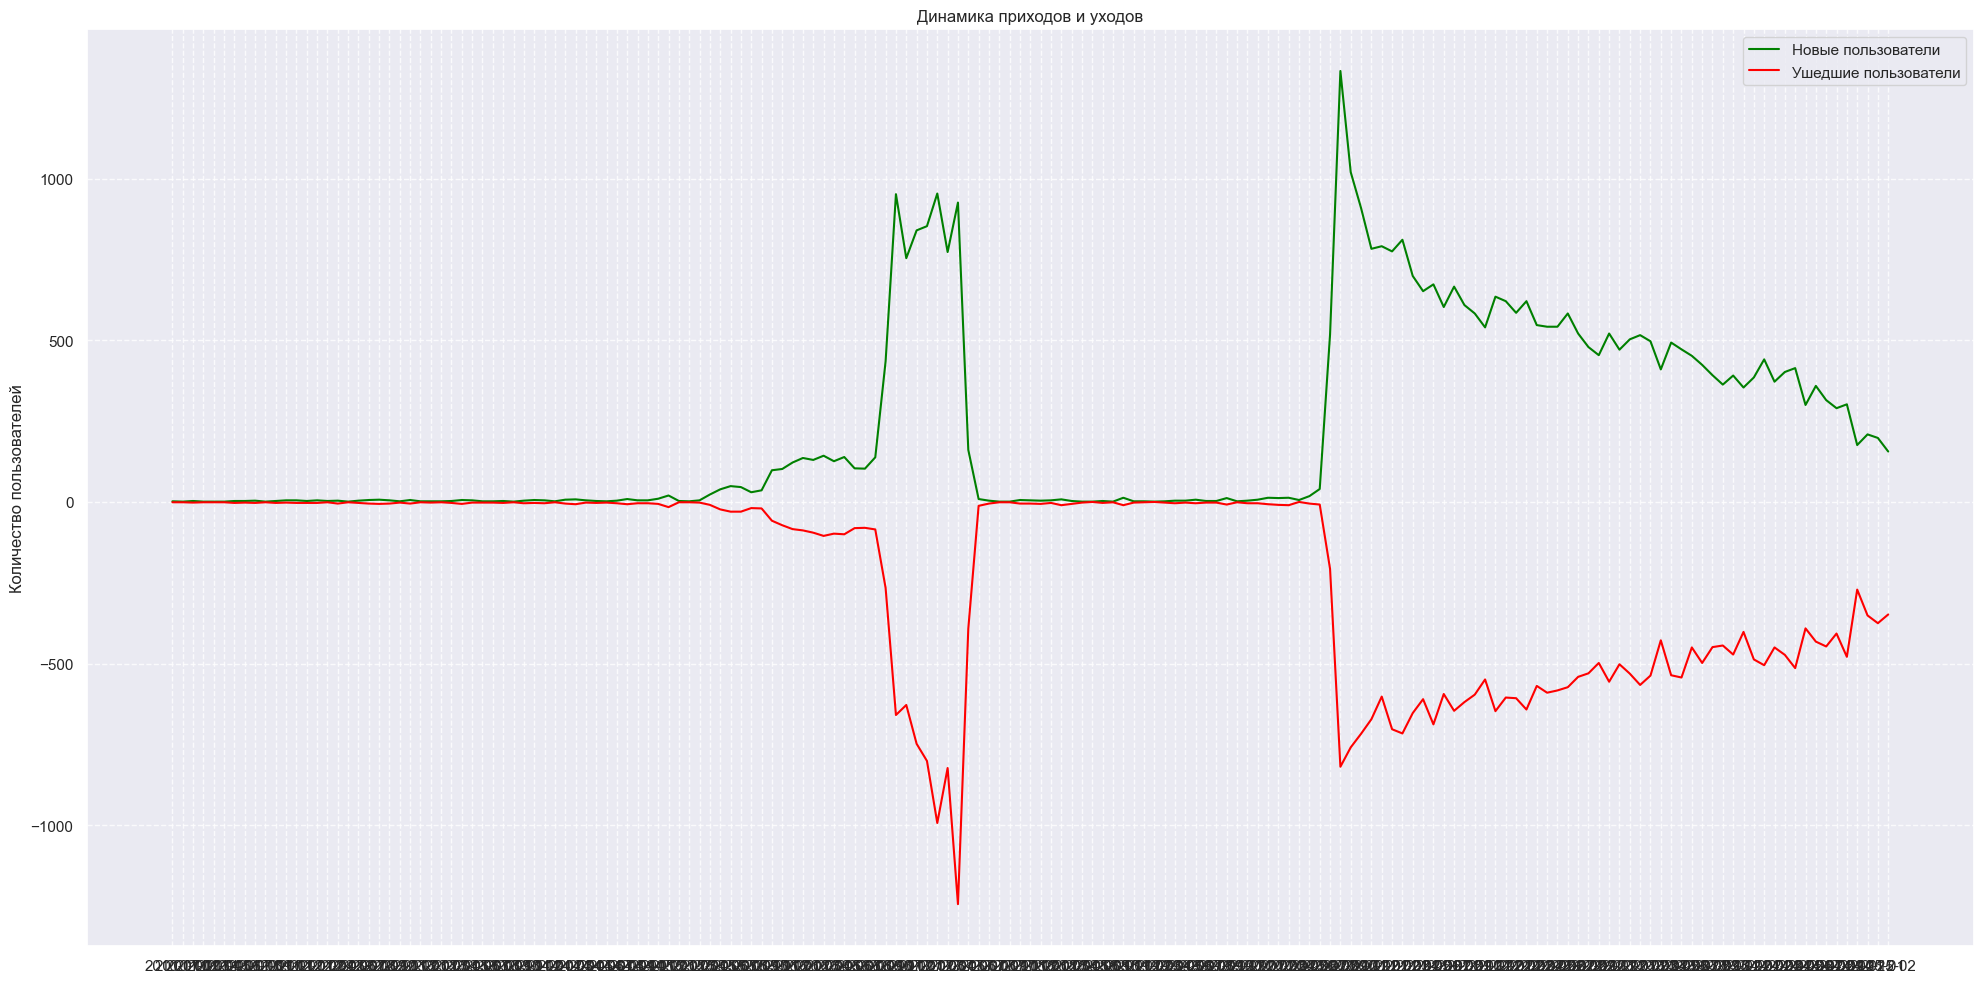

In [12]:
data_lifetime = pd.read_csv(r'..\models\elastic_metrics_by_last_action.csv').copy()

fig, ax = plt.subplots(figsize=(20, 10), sharex = True)

month =  data_lifetime['month']

ax.plot(
    month,
    data_lifetime['starts'],
    label = 'Новые пользователи',
    color = 'green'
)

ax.plot(
    month,
    -data_lifetime['leaves'],
    label = 'Ушедшие пользователи',
    color = 'red'
)

ax.set_ylabel('Количество пользователей')
ax.set_title('Динамика приходов и уходов')
ax.grid(True, linestyle='--', alpha=0.8)
ax.legend()

plt.tight_layout()
#plt.savefig(f'../image/Рисунок_1_Изменение_юзеров_для_{name}_способ_1.png')
plt.show() 

## График 2 - Нетто-изменение приходов и уходов пользователя (метрика ухода пользователя по последнему действию в БД)

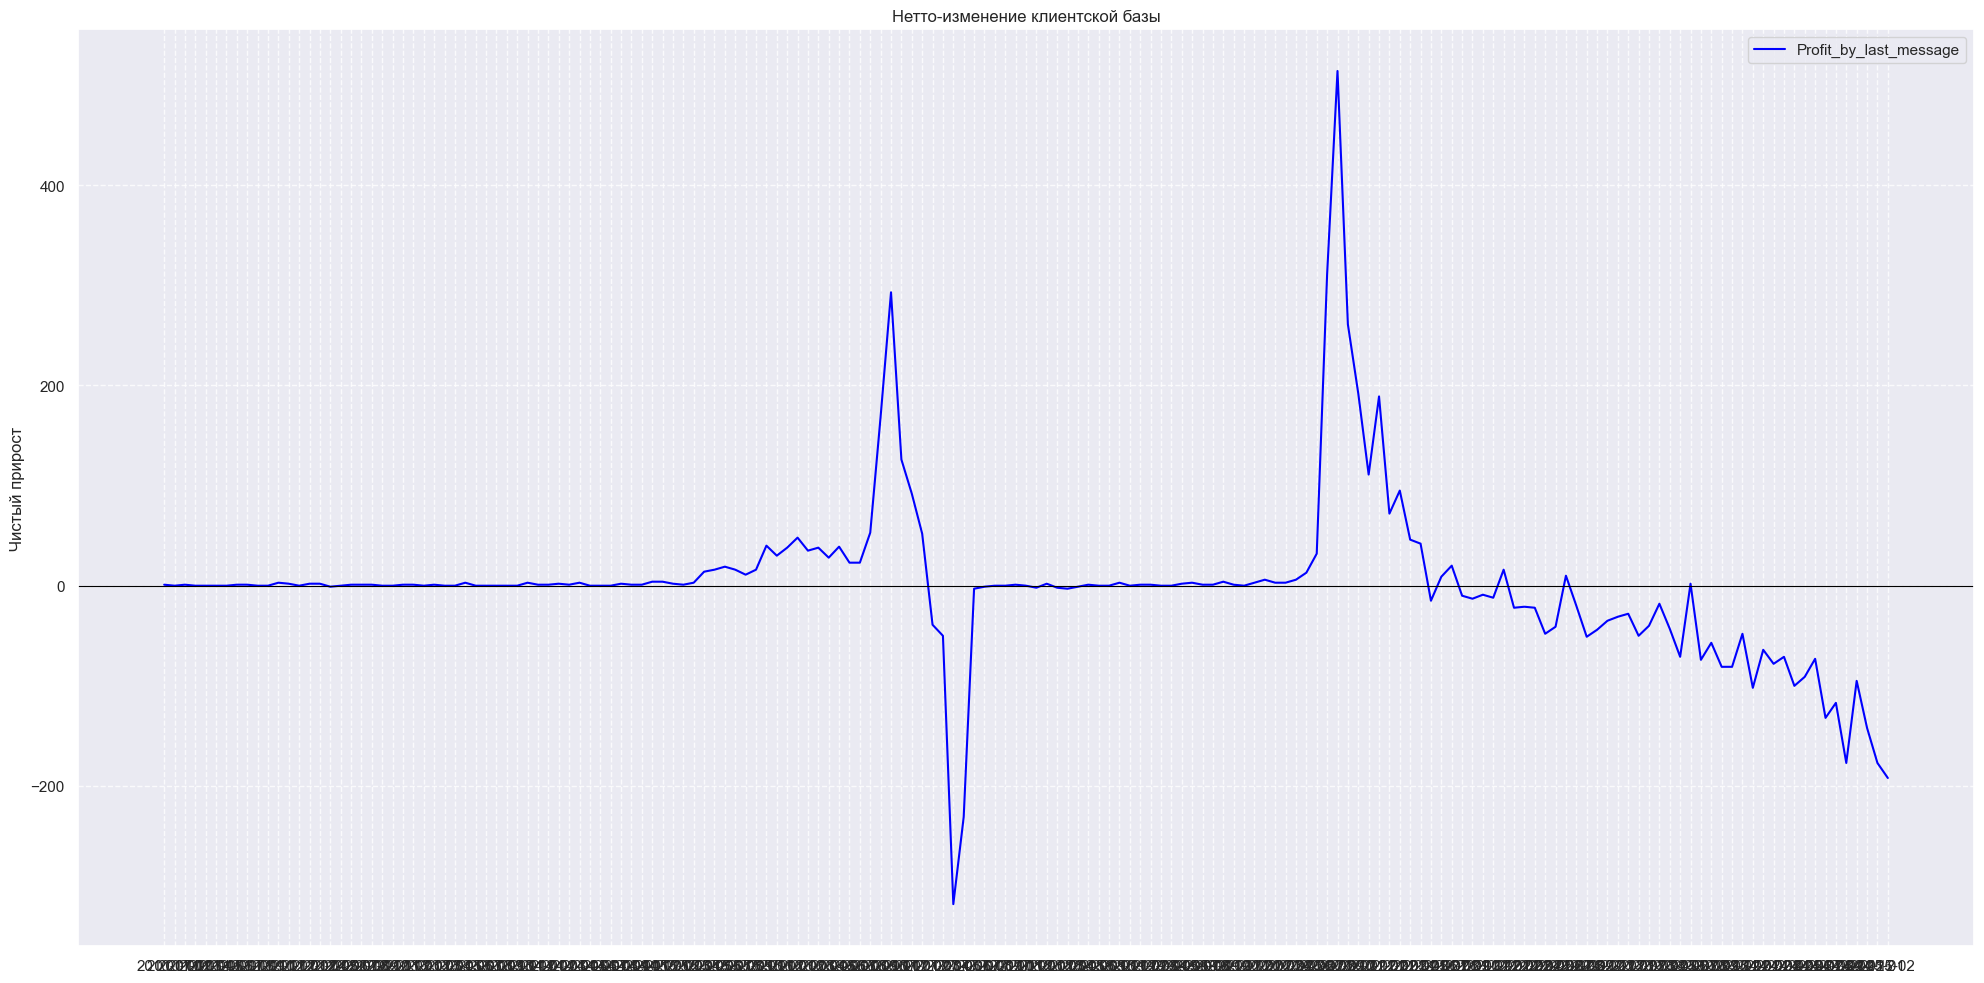

In [13]:
data_lifetime = pd.read_csv(r'..\models\elastic_metrics_by_last_action.csv').copy()

fig, ax = plt.subplots(figsize=(20, 10), sharex = True)

month =  data_lifetime['month']

ax.plot(
    month,
    data_lifetime['Profit_by_last_message'],
    label = 'Profit_by_last_message',
    color = 'blue'
)

ax.axhline(y=0, color='black', linewidth=0.8)

ax.set_ylabel('Чистый прирост')
ax.set_title('Нетто-изменение клиентской базы')
ax.grid(True, linestyle='--', alpha=0.8)
ax.legend()

plt.tight_layout()
#plt.savefig(f'../image/Рисунок_1_Изменение_юзеров_для_{name}_способ_1.png')
plt.show() 

## График 3 - Изменение приходов и уходов пользователя (метрика ухода пользователя по модели CLV)

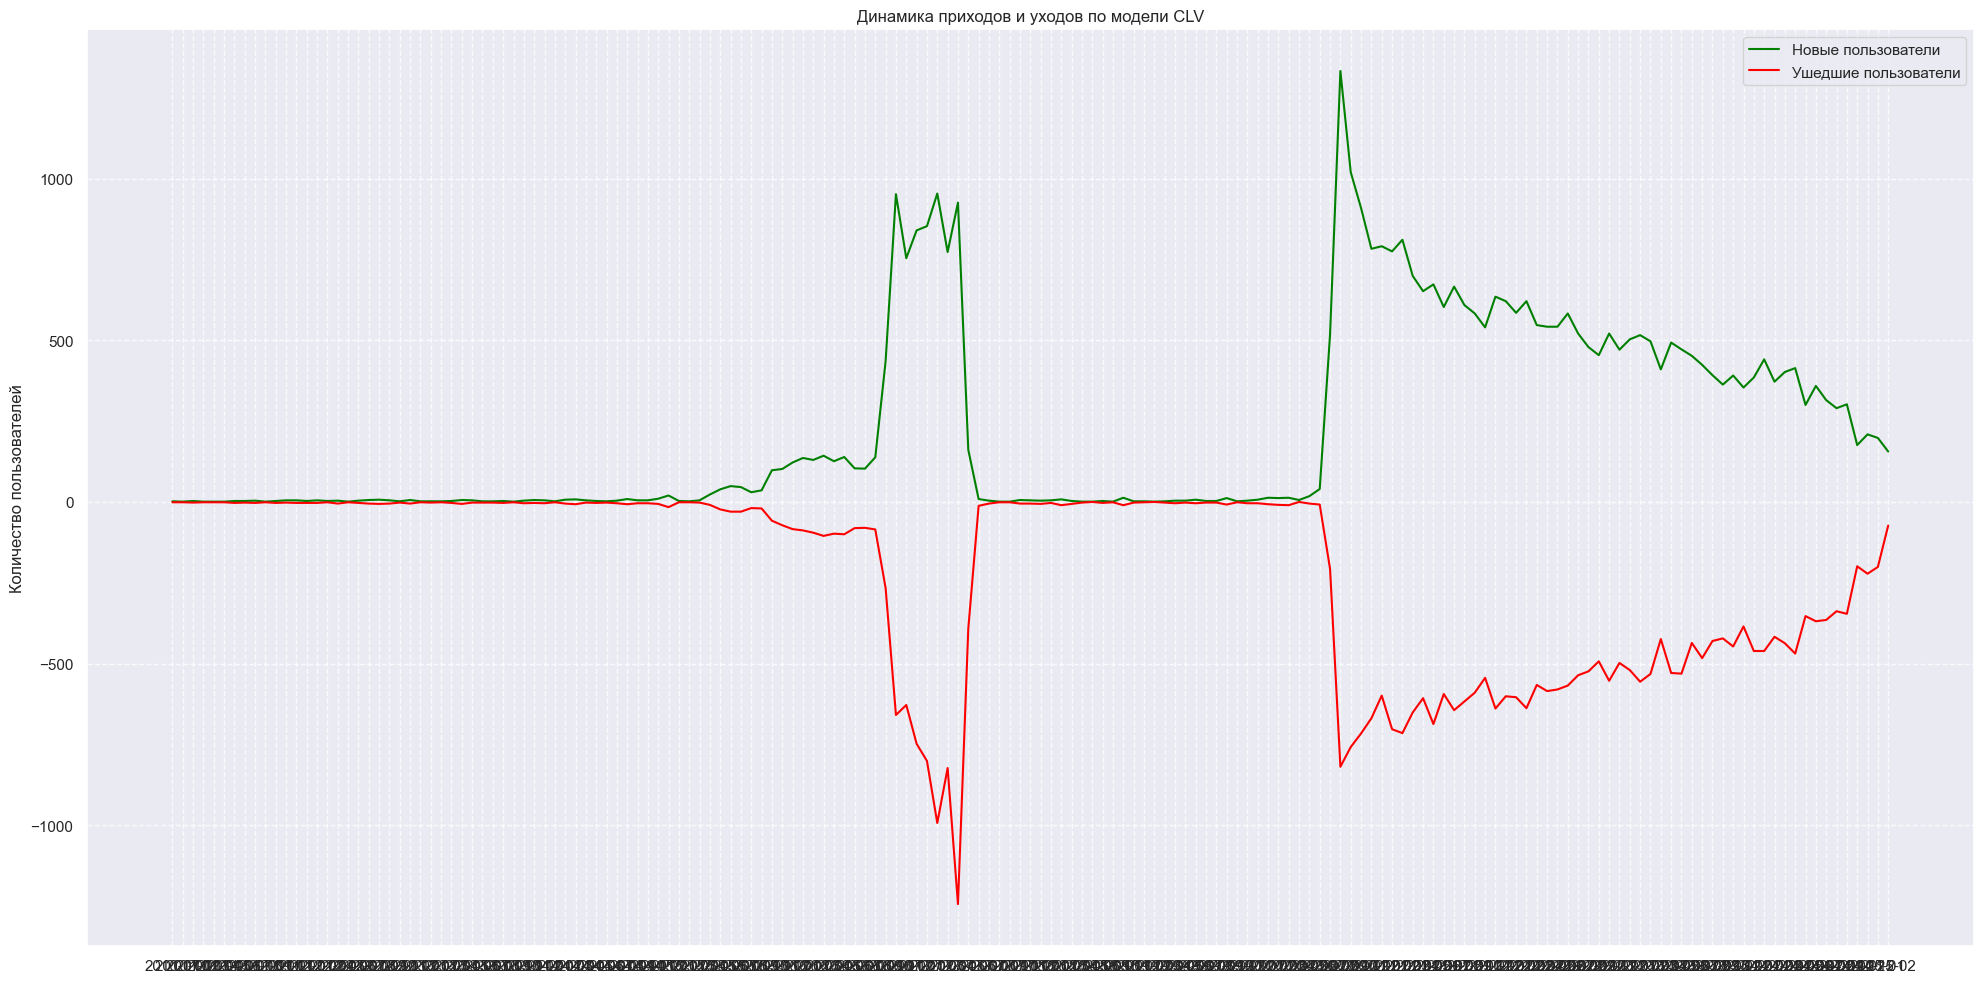

In [14]:
data_lifetime = pd.read_csv(r'..\models\elastic_metrics_by_CLV_on_0_day.csv').copy()

fig, ax = plt.subplots(figsize=(20, 10), sharex = True)

month =  data_lifetime['month']

ax.plot(
    month,
    data_lifetime['starts'],
    label = 'Новые пользователи',
    color = 'green'
)

ax.plot(
    month,
    -data_lifetime['leaves'],
    label = 'Ушедшие пользователи',
    color = 'red'
)

ax.set_ylabel('Количество пользователей')
ax.set_title('Динамика приходов и уходов по модели CLV')
ax.grid(True, linestyle='--', alpha=0.8)
ax.legend()

plt.tight_layout()
#plt.savefig(f'../image/Рисунок_1_Изменение_юзеров_для_{name}_способ_1.png')
plt.show() 

## График 4 - Нетто-изменение приходов и уходов пользователя (метрика ухода пользователя по модели CLV)

In [15]:
pd.read_csv(r'..\models\elastic_metrics_by_CLV_on_0_day.csv').sample(30
                                                                   )

,month,starts,leaves,LTS_ratio_by_CLV,Profit_by_CLV
6,2011-06,3,3.0,1.000000,0.0
81,2017-10,1,1.0,1.000000,0.0
18,2012-07,4,3.0,0.750000,1.0
12,2011-12,5,3.0,0.600000,2.0
110,2020-06,18,5.0,0.277778,13.0
85,2018-02,5,3.0,0.600000,2.0
94,2019-02,2,1.0,0.500000,1.0
123,2021-07,603,594.0,0.985075,9.0
111,2020-07,40,8.0,0.200000,32.0
145,2023-05,493,529.0,1.073022,-36.0


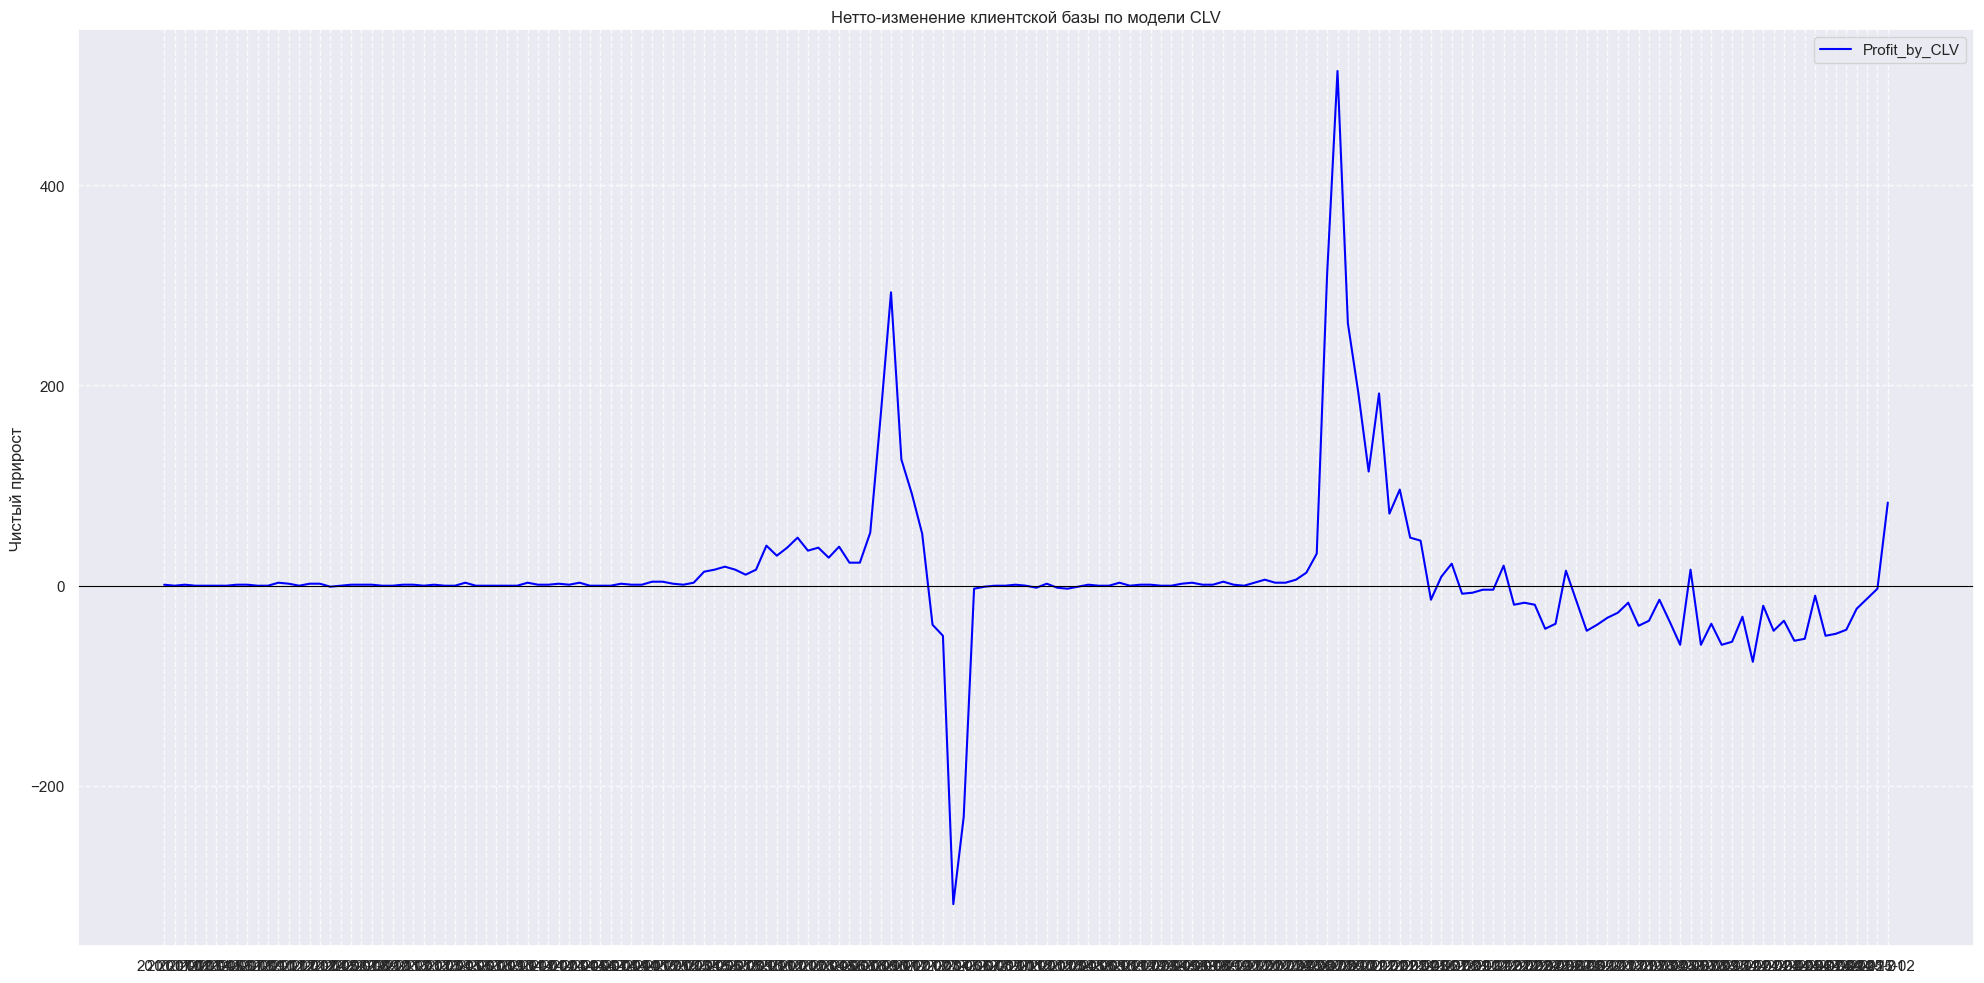

In [16]:
data_lifetime = pd.read_csv(r'..\models\elastic_metrics_by_CLV_on_0_day.csv').copy()

fig, ax = plt.subplots(figsize=(20, 10), sharex = True)

month =  data_lifetime['month']

ax.plot(
    month,
    data_lifetime['Profit_by_CLV'],
    label = 'Profit_by_CLV',
    color = 'blue'
)
ax.axhline(y=0, color='black', linewidth=0.8)

ax.set_ylabel('Чистый прирост')
ax.set_title('Нетто-изменение клиентской базы по модели CLV')
ax.grid(True, linestyle='--', alpha=0.8)
ax.legend()

plt.tight_layout()
#plt.savefig(f'../image/Рисунок_1_Изменение_юзеров_для_{name}_способ_1.png')
plt.show() 

## График 5 - Сравнение двух методов определения ушедшего пользователя через изменение пользователей

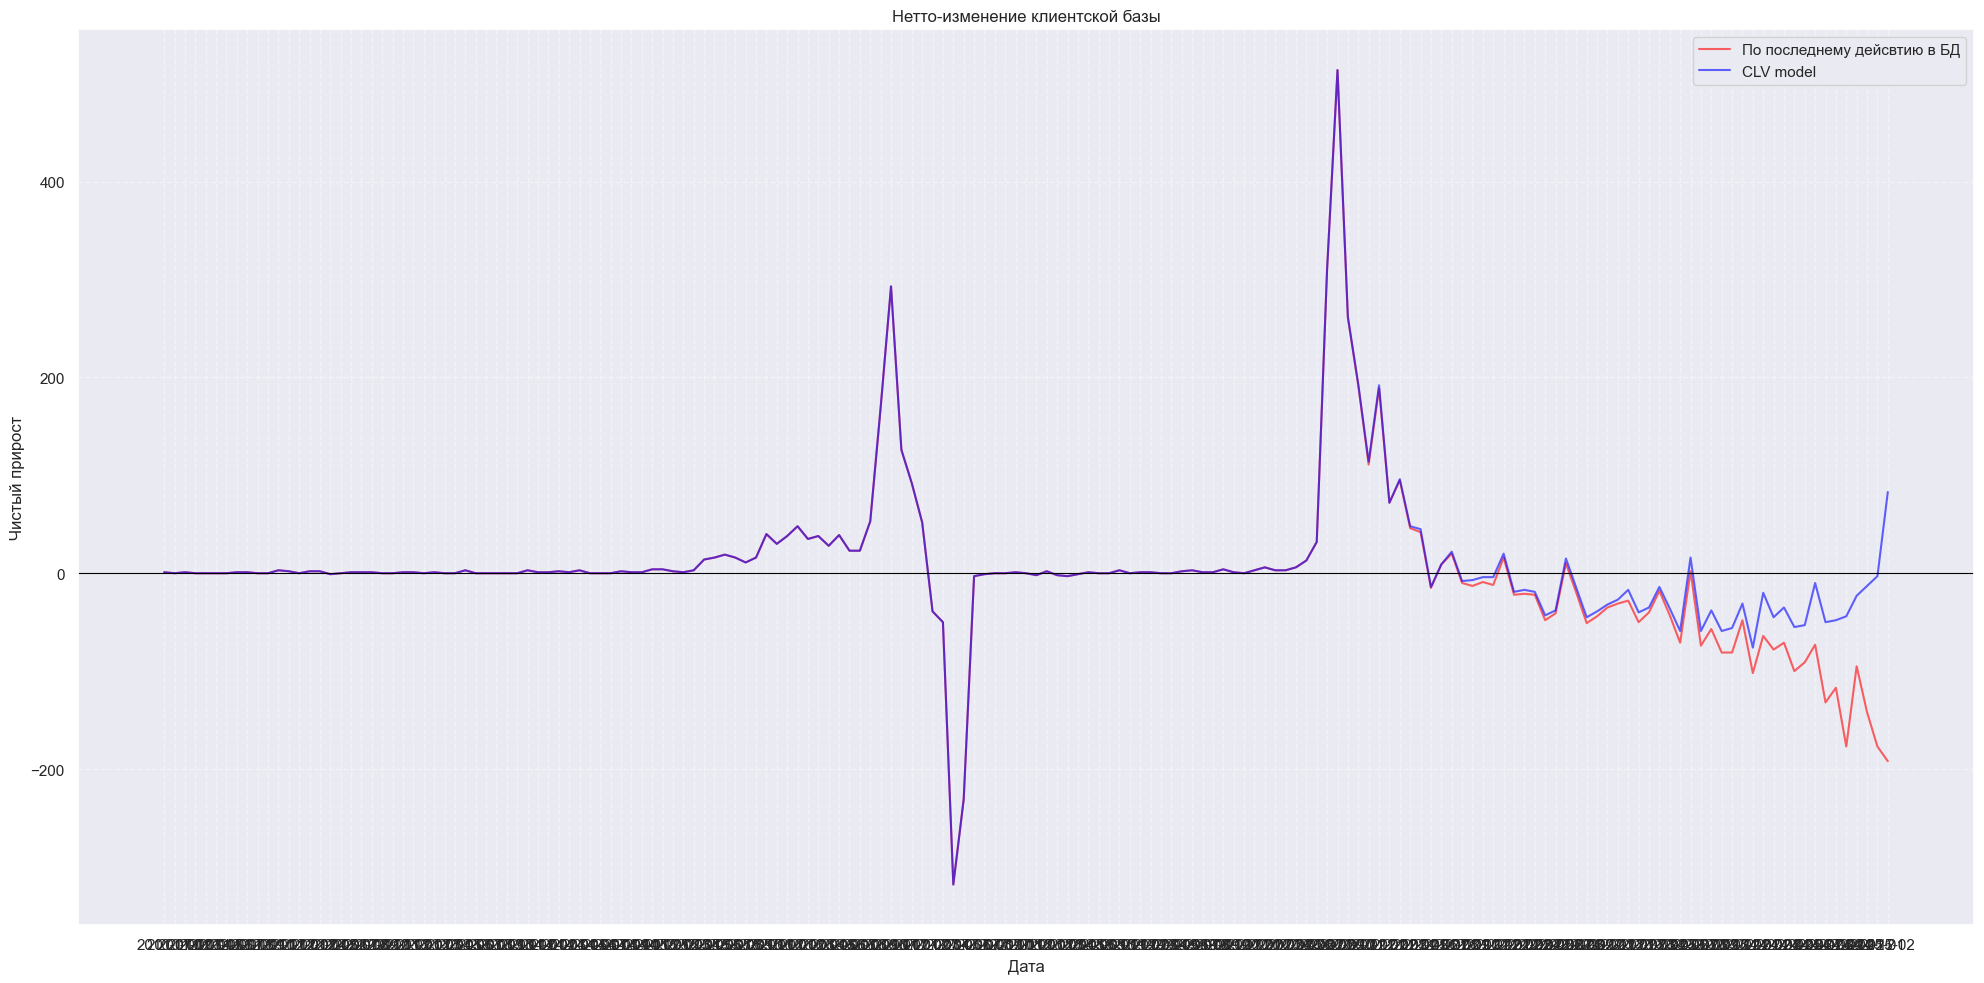

In [17]:
data_lifetime_last = pd.read_csv(r'..\models\elastic_metrics_by_last_action.csv').copy()
data_lifetime_clv = pd.read_csv(r'..\models\elastic_metrics_by_CLV_on_0_day.csv').copy()

month =  data_lifetime['month']

fig, ax = plt.subplots(figsize=(20, 10), sharex = True)

ax.plot(
    month,
    data_lifetime_last['Profit_by_last_message'],
    label = 'По последнему дейсвтию в БД',
    color = 'red',
    alpha=0.6
)

ax.plot(
    month,
    data_lifetime_clv['Profit_by_CLV'],
    label = 'CLV model',
    color = 'blue',
    alpha=0.6
)

ax.axhline(y=0, color='black', linewidth=0.8)

ax.set_ylabel('Чистый прирост')
ax.set_title('Нетто-изменение клиентской базы')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()

ax.set_xlabel('Дата')

plt.tight_layout()
#plt.savefig(f'../image/Рисунок_5_Сравнение_двух_методов_для_{name}.png')
plt.show()

## График 6 - Распределение времени до прогнозируемого ухода пользователей (горизонт 1 год)

In [18]:
pd.read_csv(r'..\models\elastic_user_lifetime_on_365_day.csv').tail()

,author_id,frequency,recency,T,p_alive,is_churn,created_at_first,created_at_last
37312,163610,0.0,0.0,0.0,0.100881,True,2025-02,2025-02
37313,163612,0.0,0.0,0.0,0.100881,True,2025-02,2025-02
37314,163616,0.0,0.0,0.0,0.100881,True,2025-02,2025-02
37315,163621,0.0,0.0,0.0,0.100881,True,2025-02,2025-02
37316,163625,0.0,0.0,0.0,0.100881,True,2025-02,2025-02


In [19]:
data = pd.read_csv(r'..\models\elastic_user_lifetime_on_365_day.csv').copy()
alive_users_365 = data['is_churn'].sum()
print(int(alive_users_365))

36216


Результат:
Разные значения числа пользователей, ушедших через год (35849 против 36216), возникают из-за того, что в двух реализациях используется разная логика определения оттока. В функции predict_churn_date применяется динамический подход: вероятность того, что пользователь «жив» (p_alive), пересчитывается на каждом шаге с увеличением времени наблюдения T, и churn фиксируется в первый момент, когда эта вероятность падает ниже порога b. Таким образом учитывается постепенное «старение» пользователя. В функции LTS_ratio_by_CLV, напротив, используется статическая оценка: вероятность быть «живым» считается сразу на горизонте 365 дней (future_t=365) без промежуточных шагов и без обновления T, и churn определяется только по итоговому значению. Из-за этой разницы (динамика против статического прогноза, разное определение момента оттока и отсутствие обновления T во втором случае) результаты естественно расходятся, хотя и остаются близкими по величине.

In [35]:
pd.read_csv(fr'..\models\acer_metrics_by_last_action.csv').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      211 non-null    object 
 1   starts                     211 non-null    float64
 2   leaves                     211 non-null    float64
 3   LTS_ratio_by_last_message  211 non-null    float64
 4   Profit_by_last_message     211 non-null    float64
dtypes: float64(4), object(1)
memory usage: 8.4+ KB


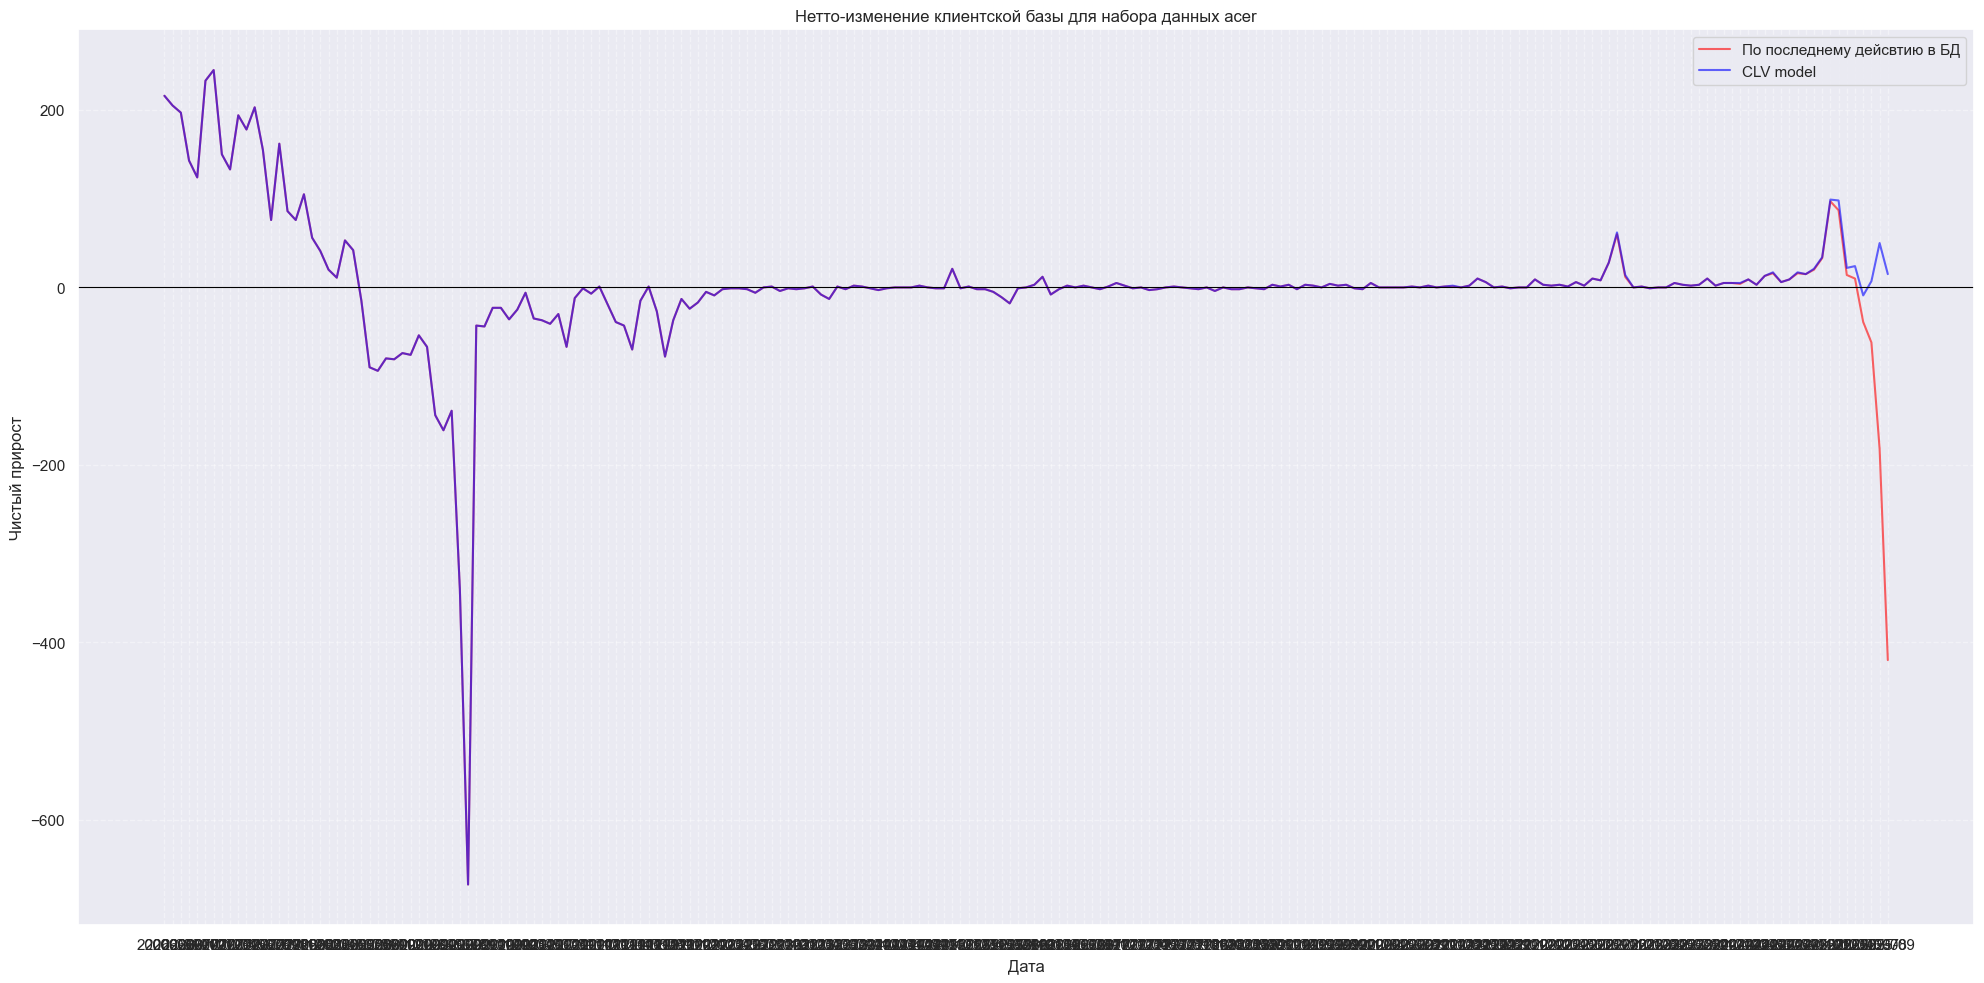

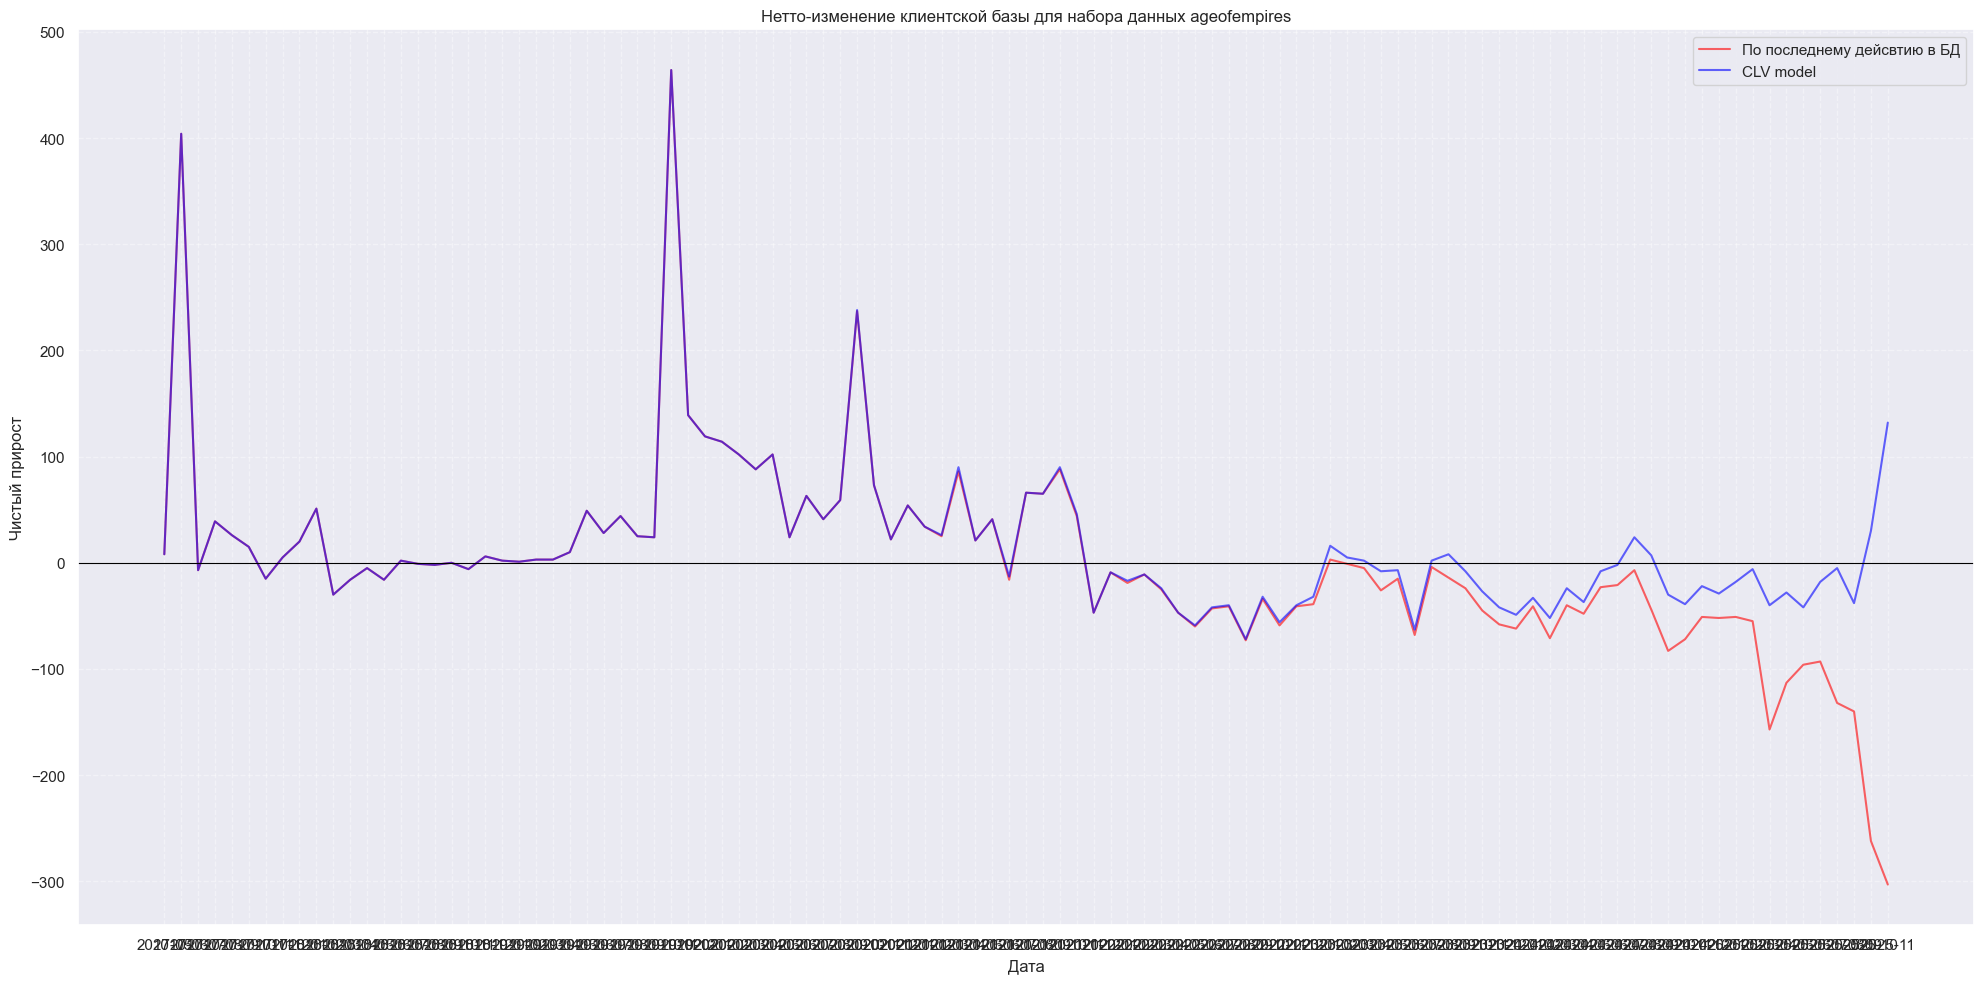

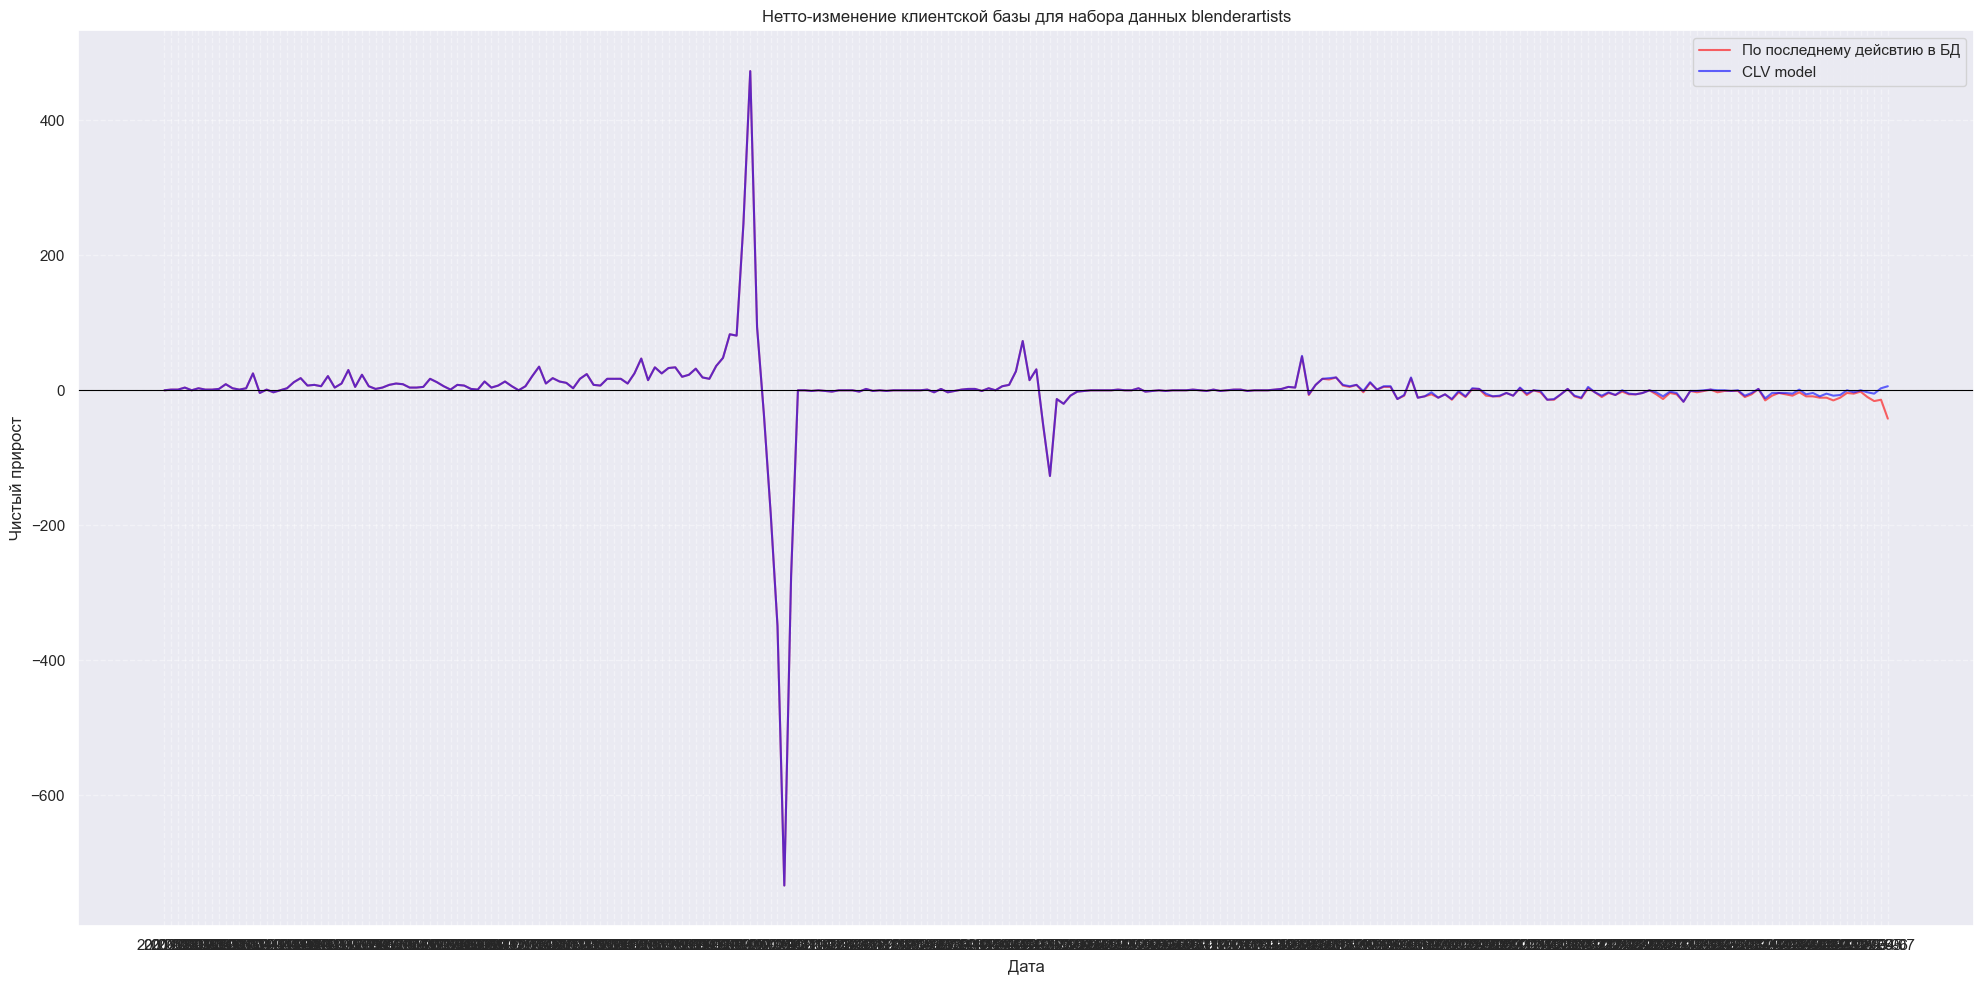

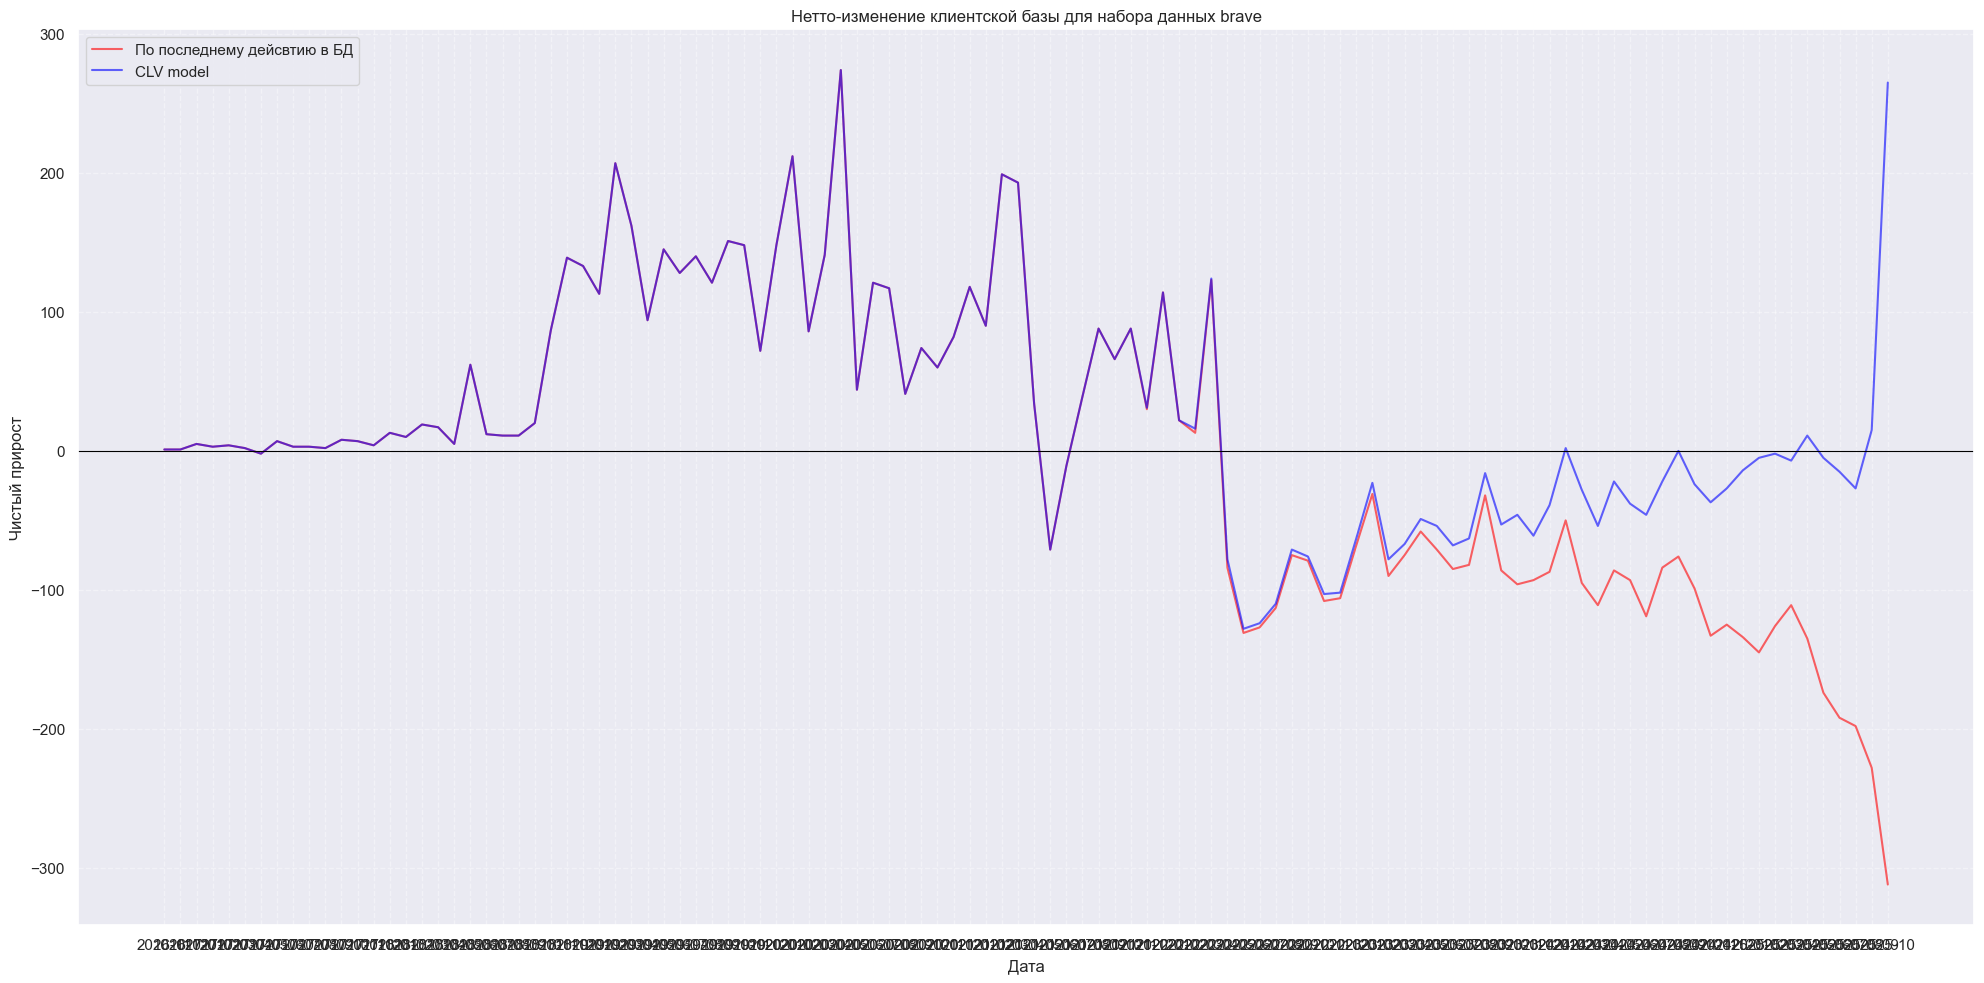

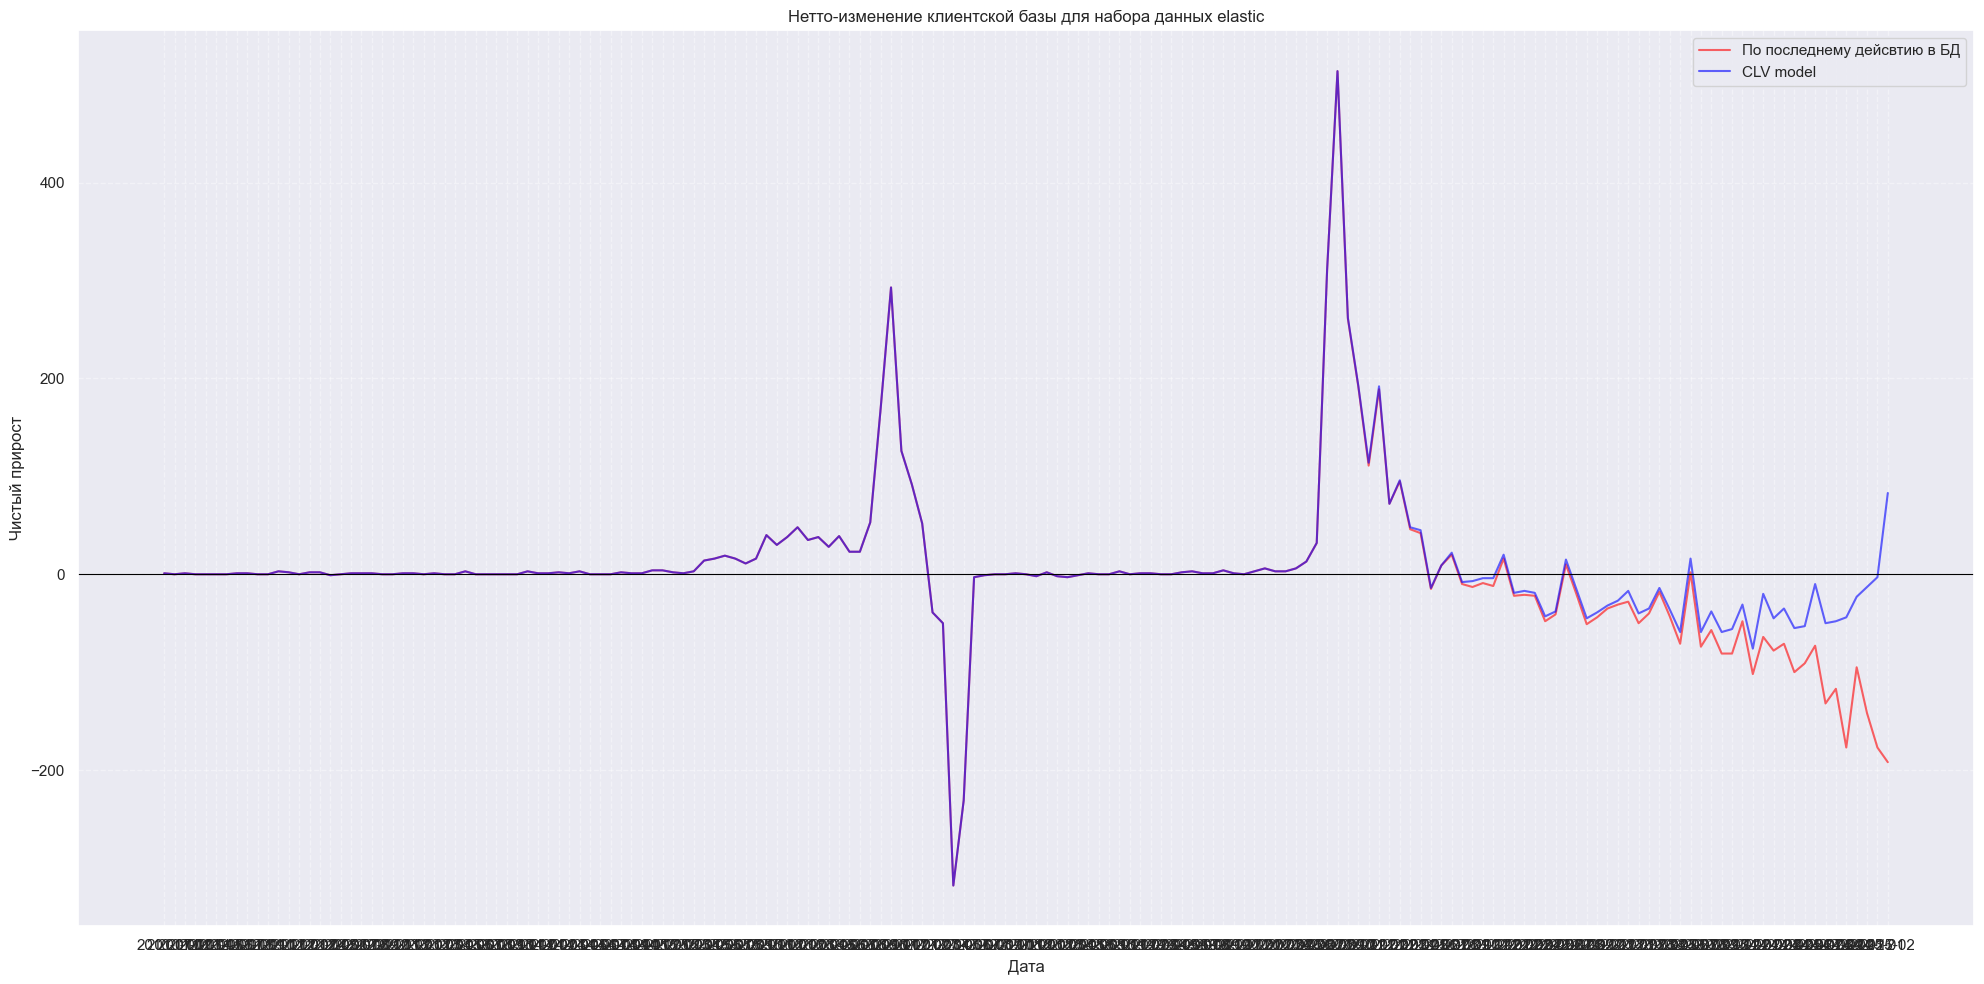

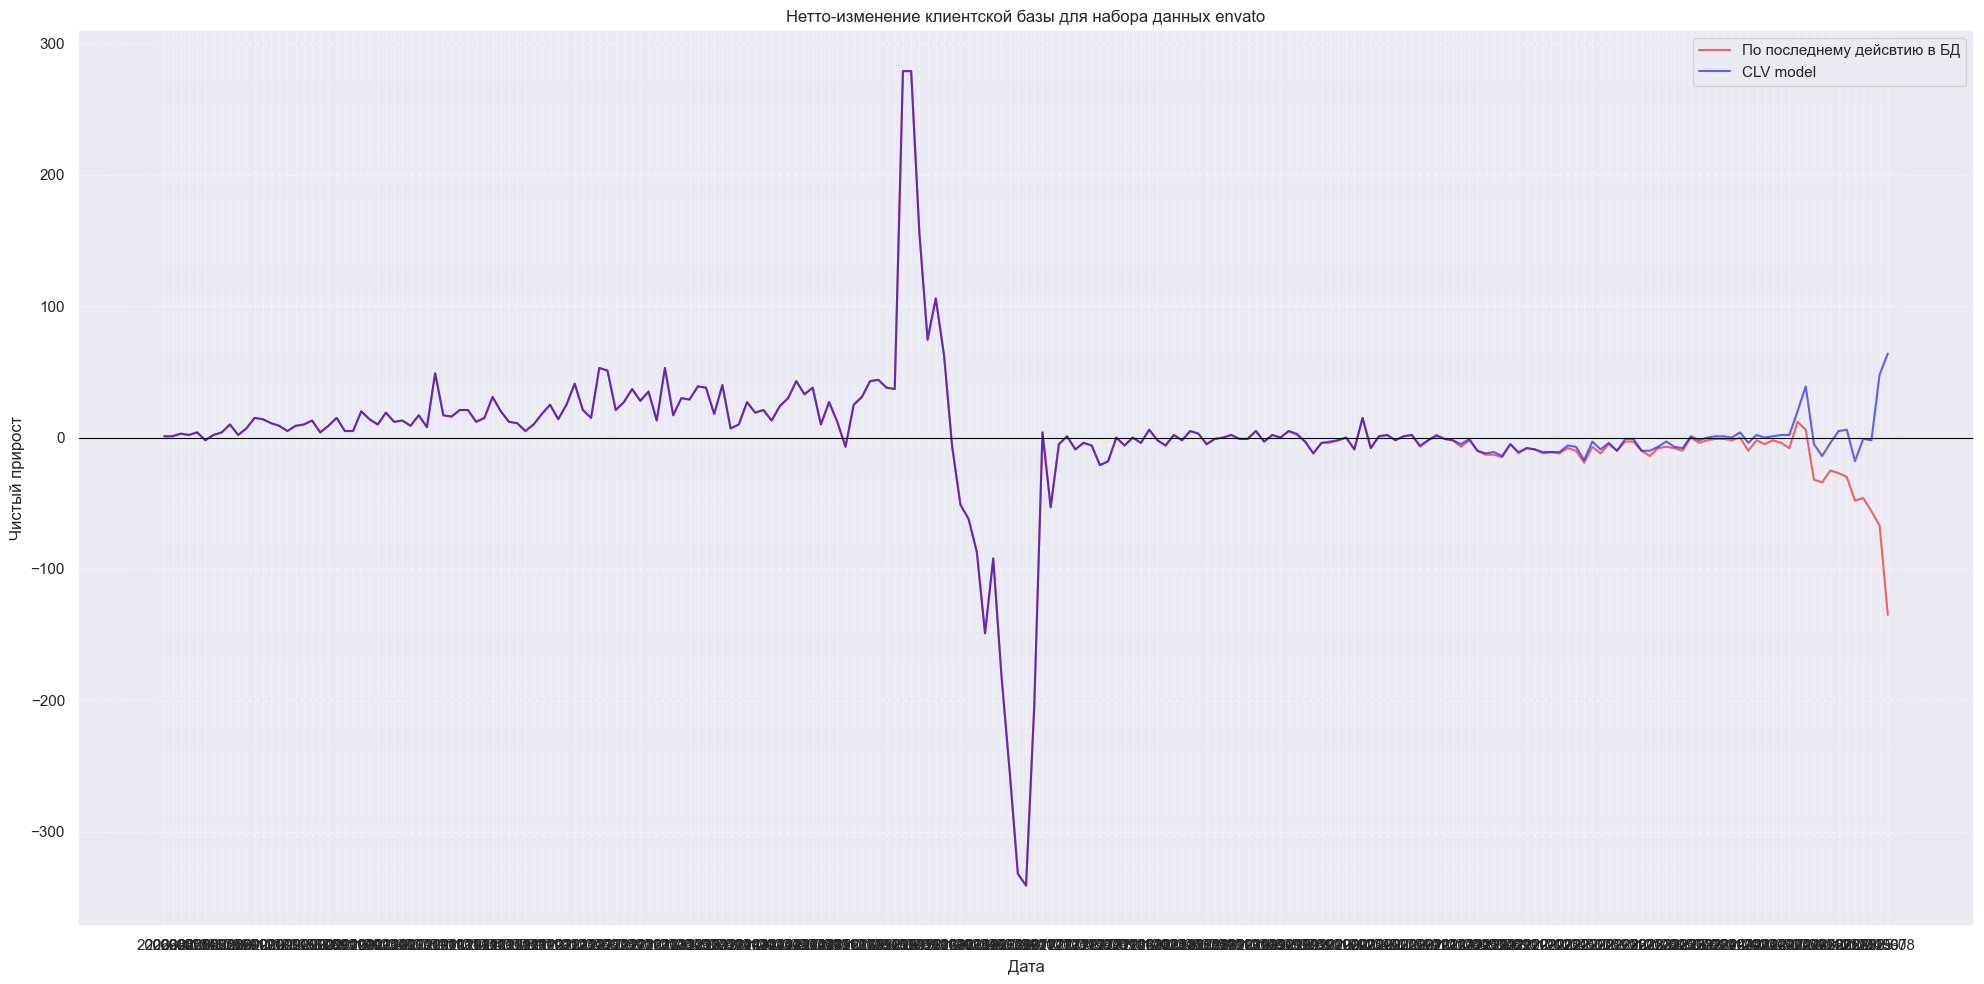

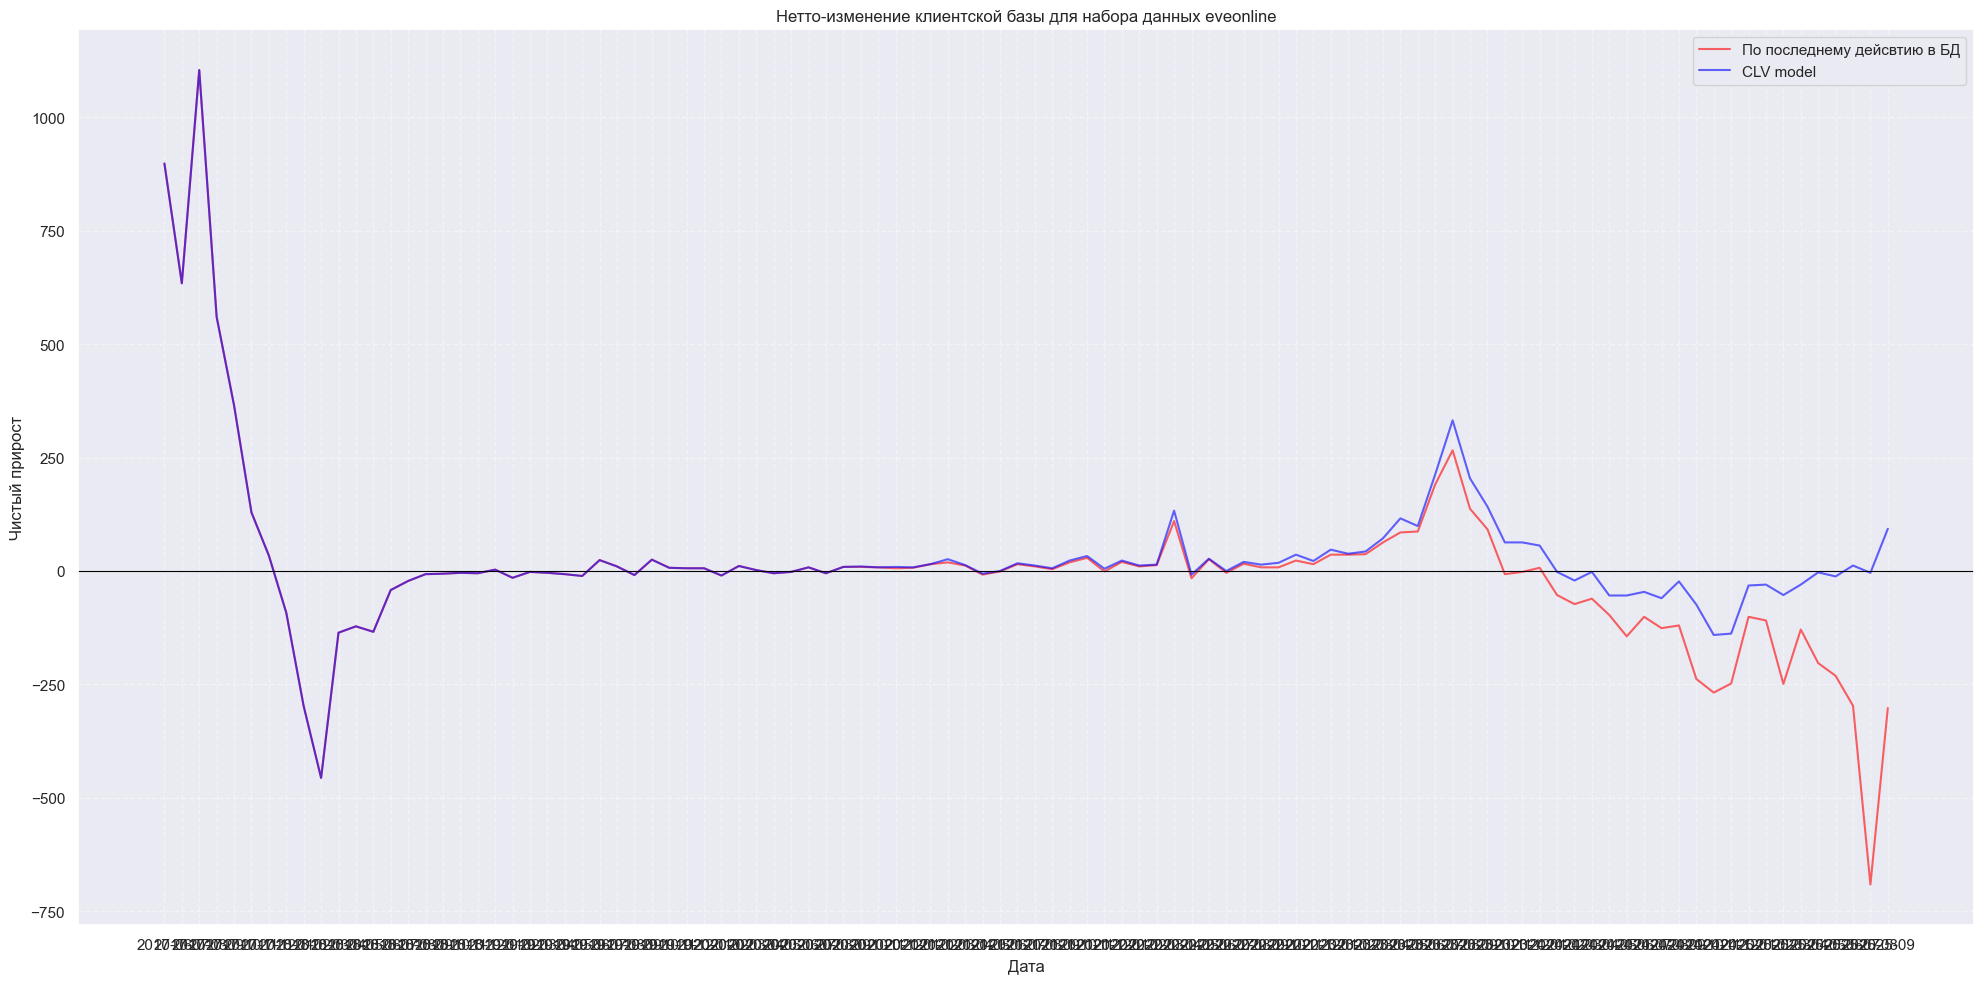

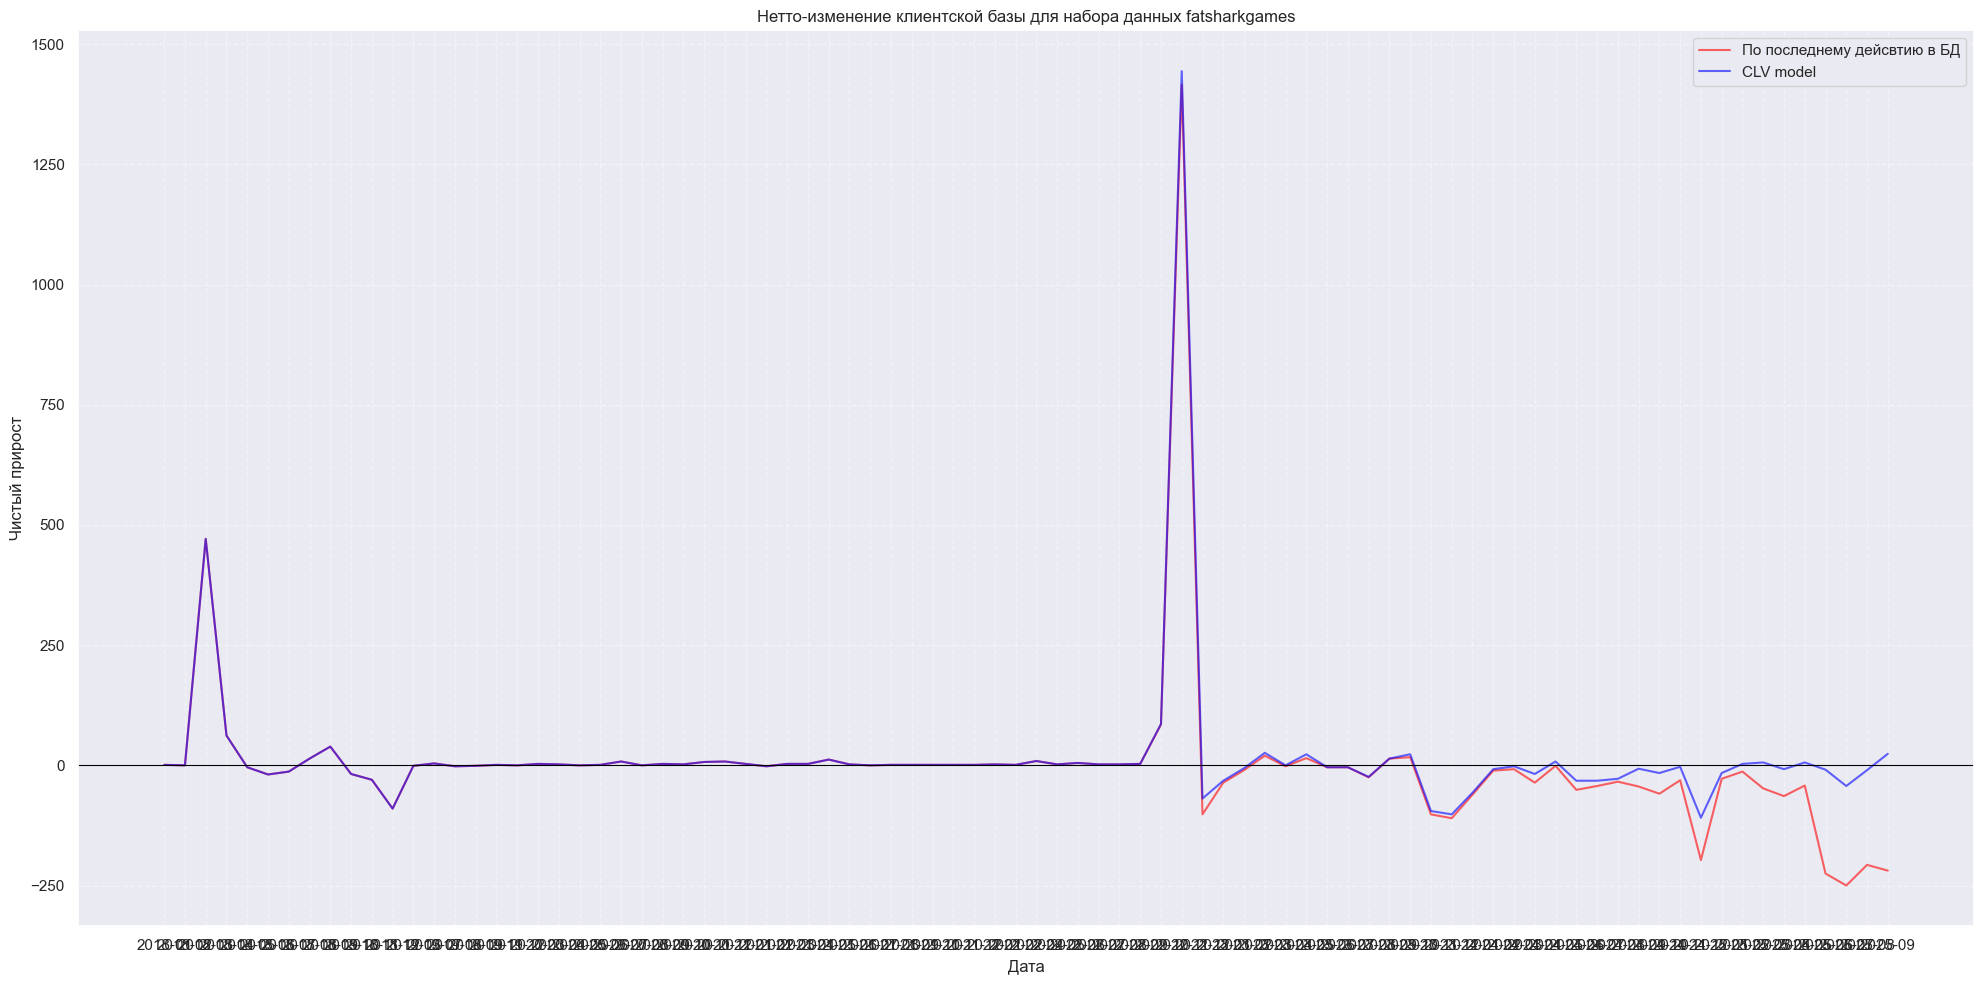

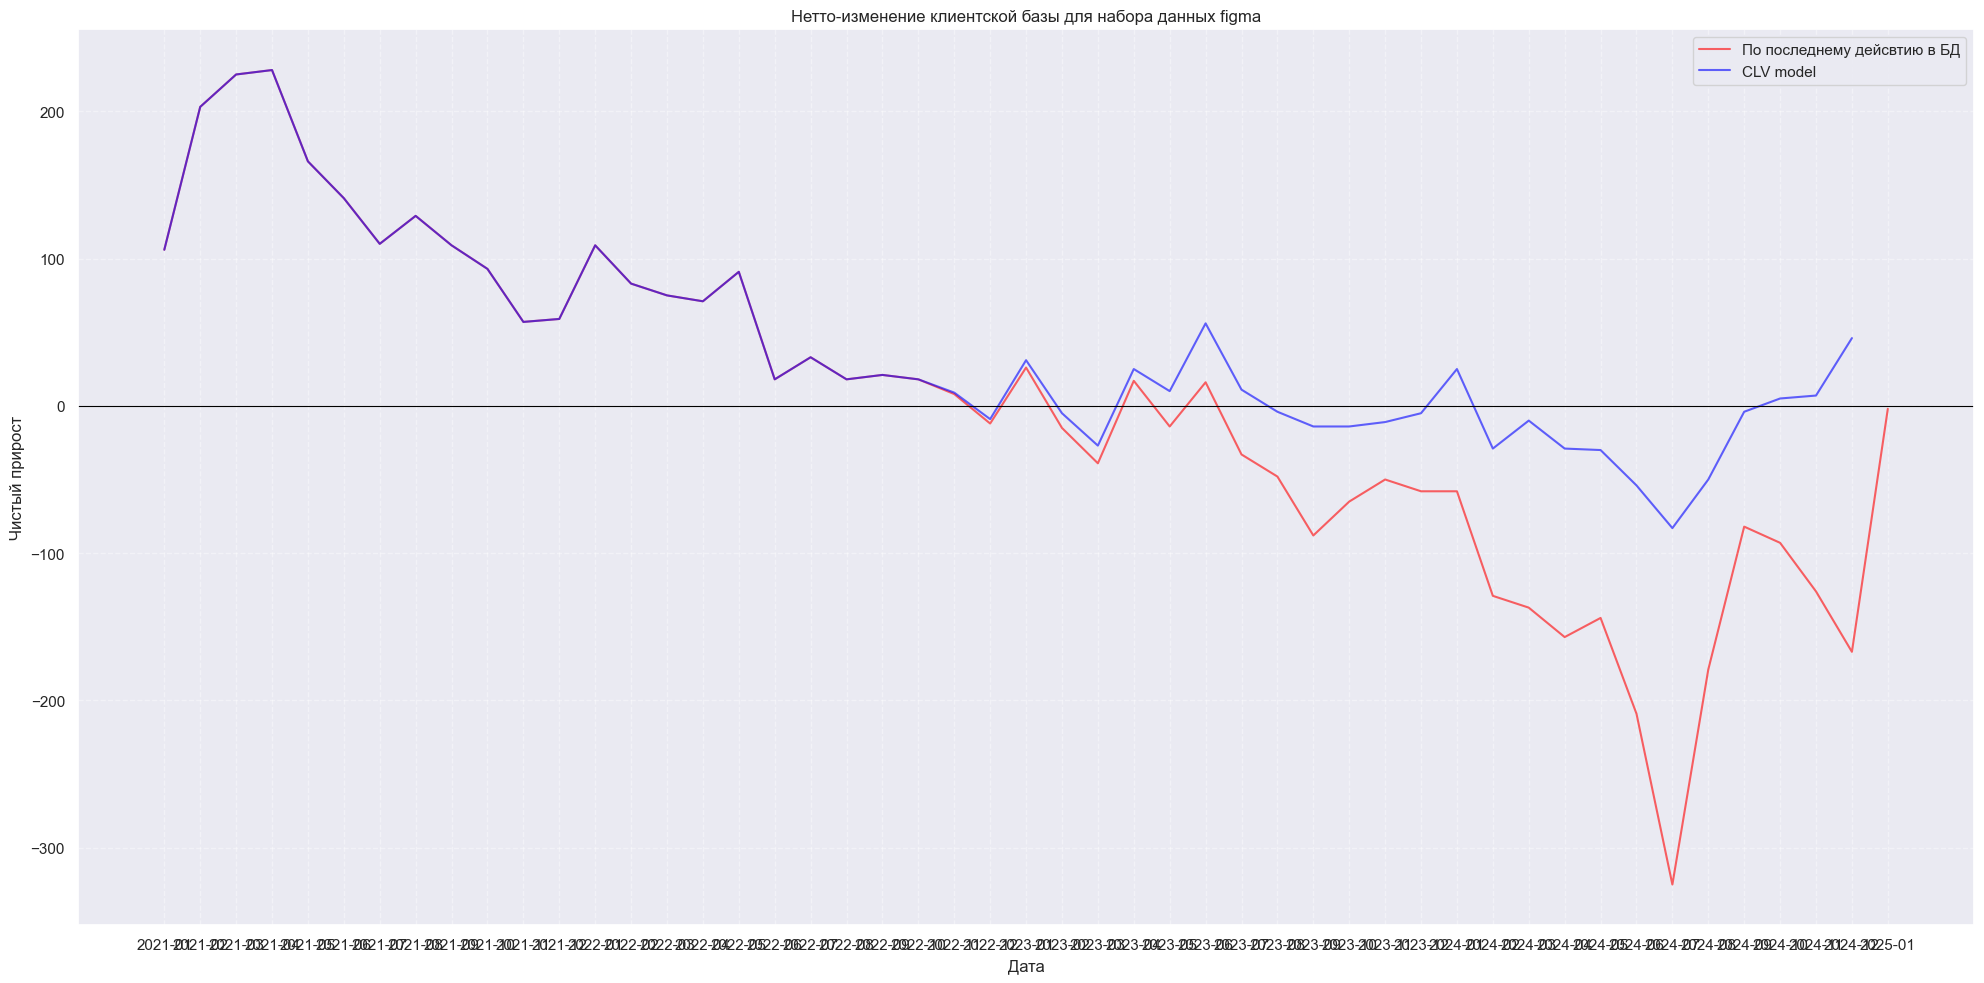

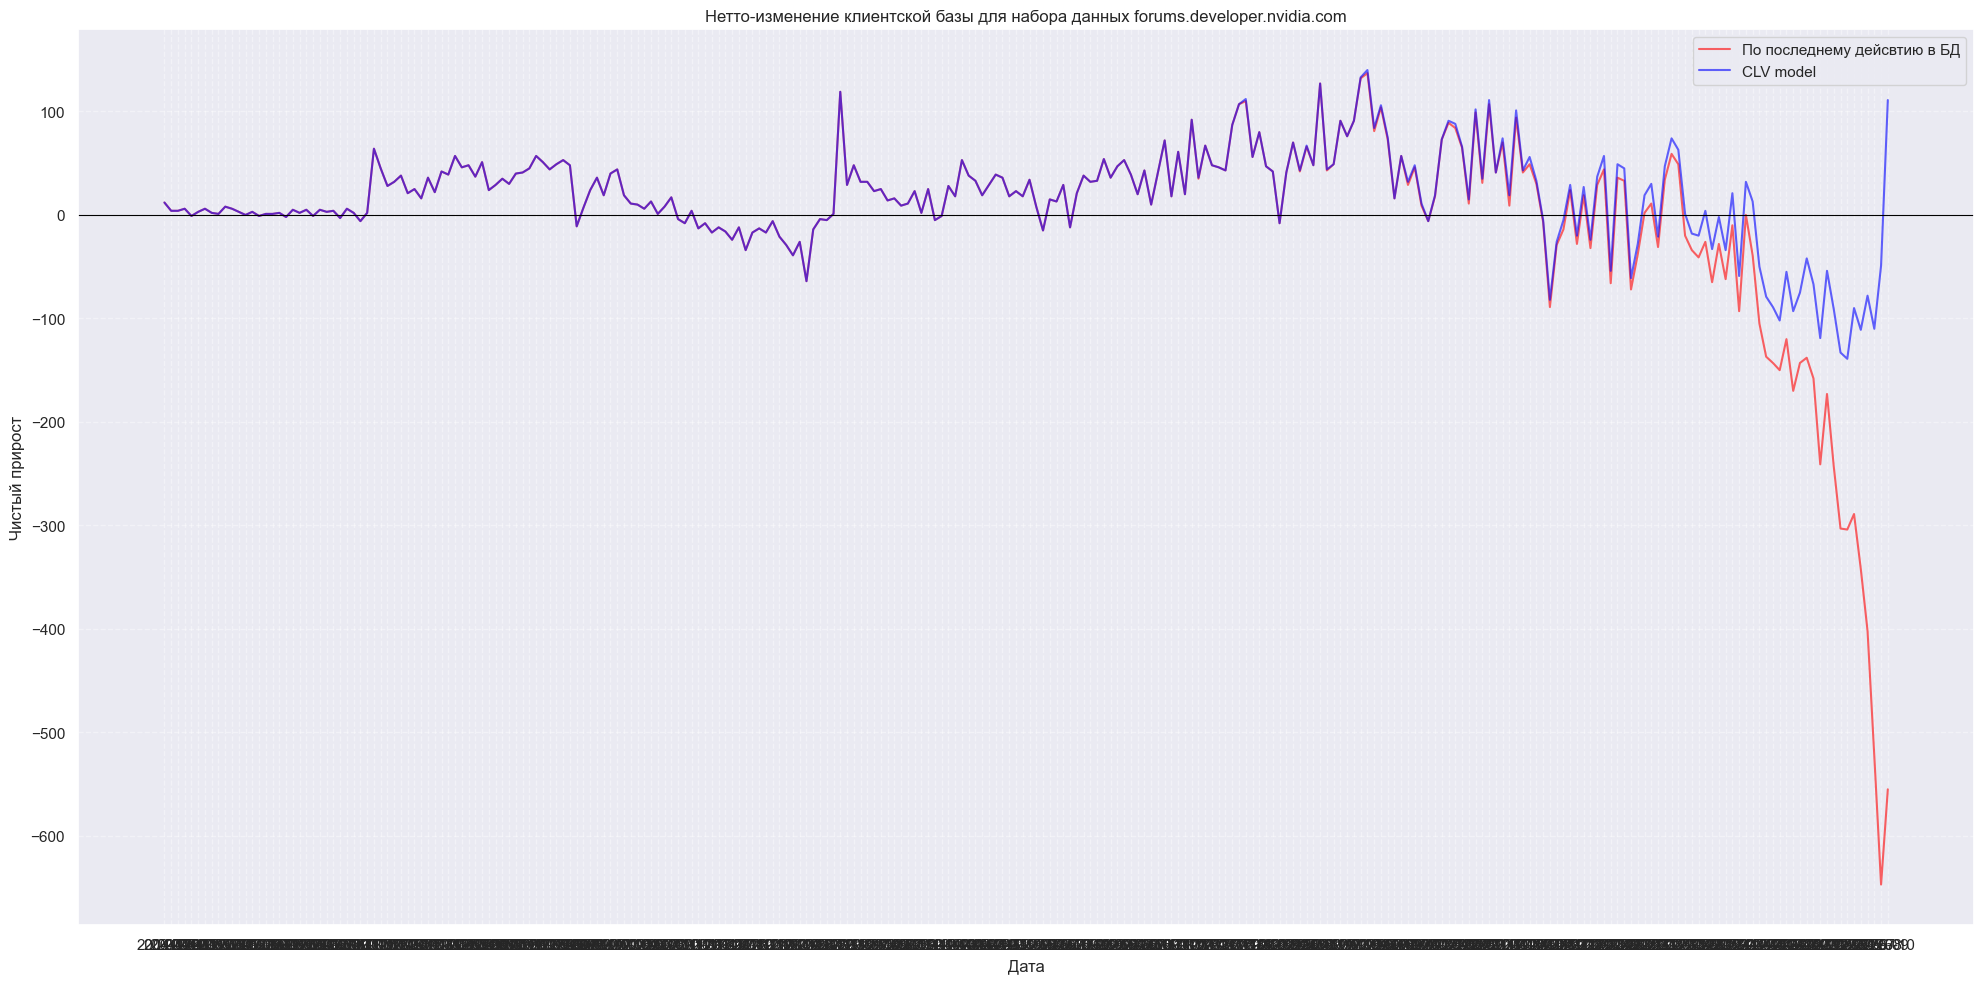

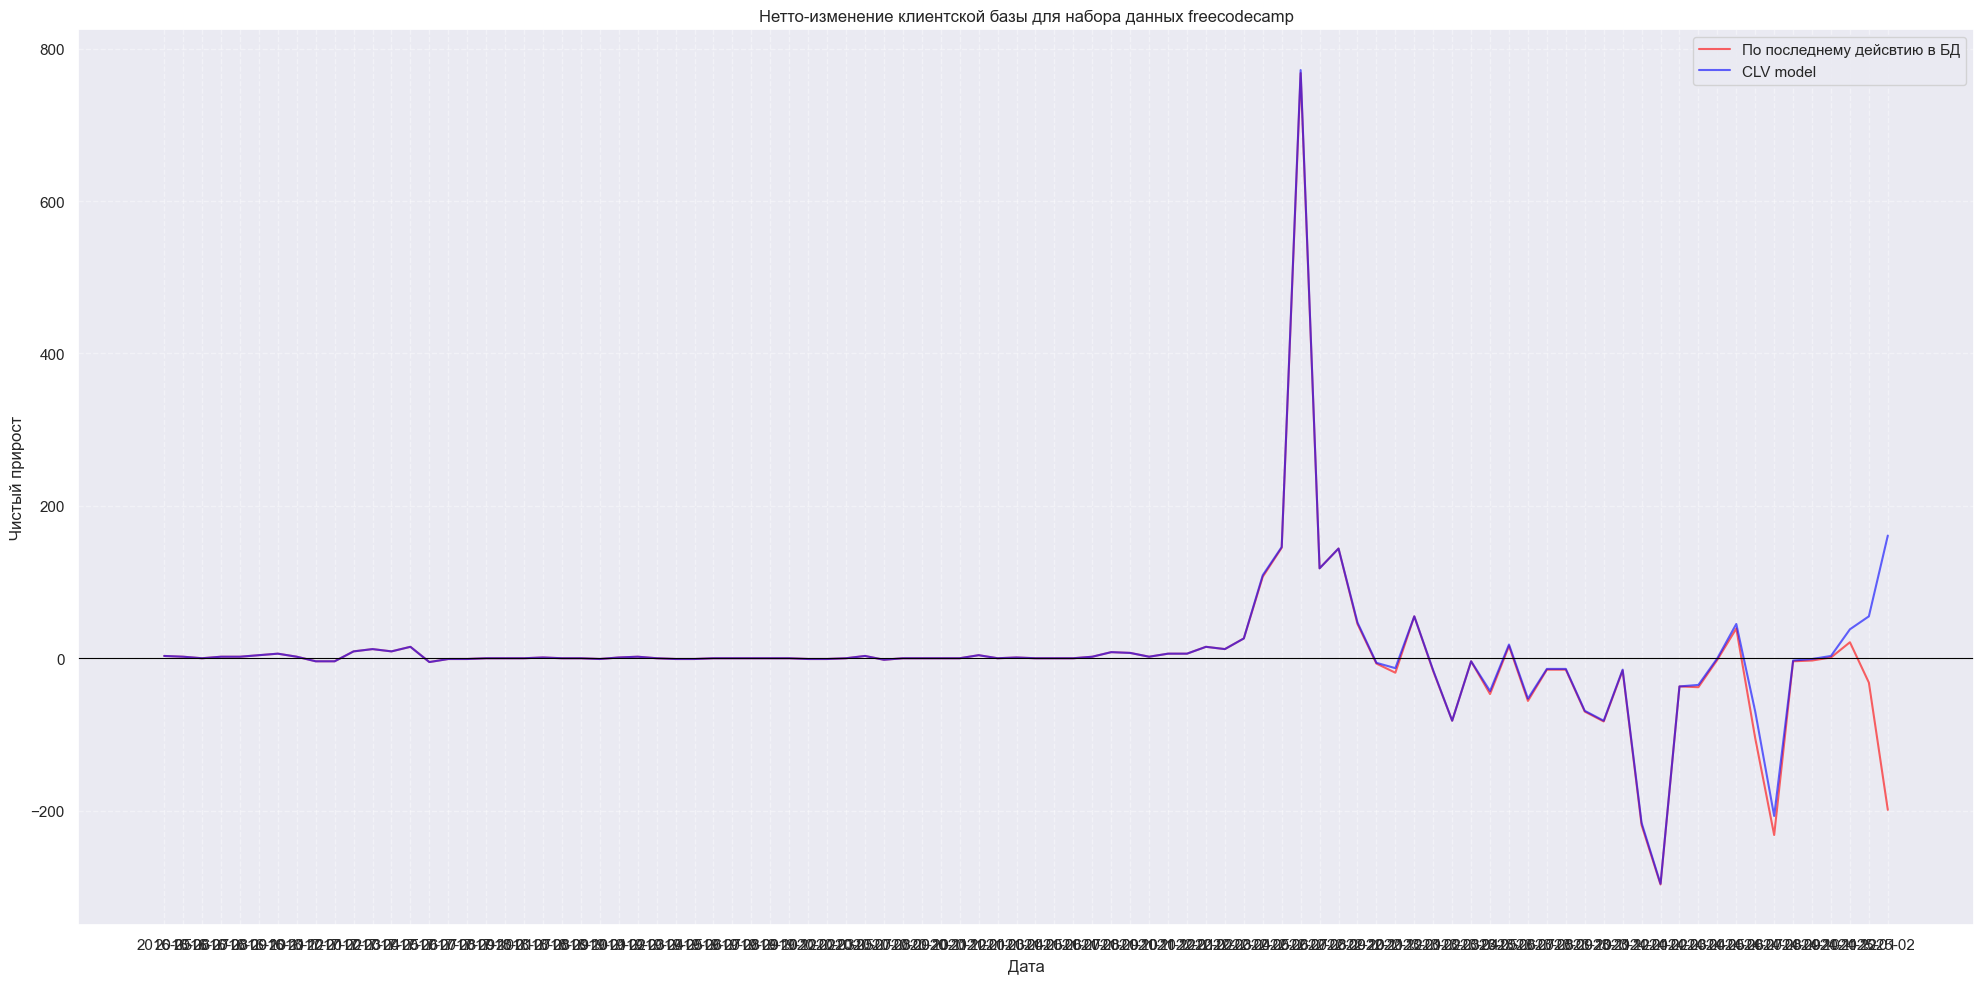

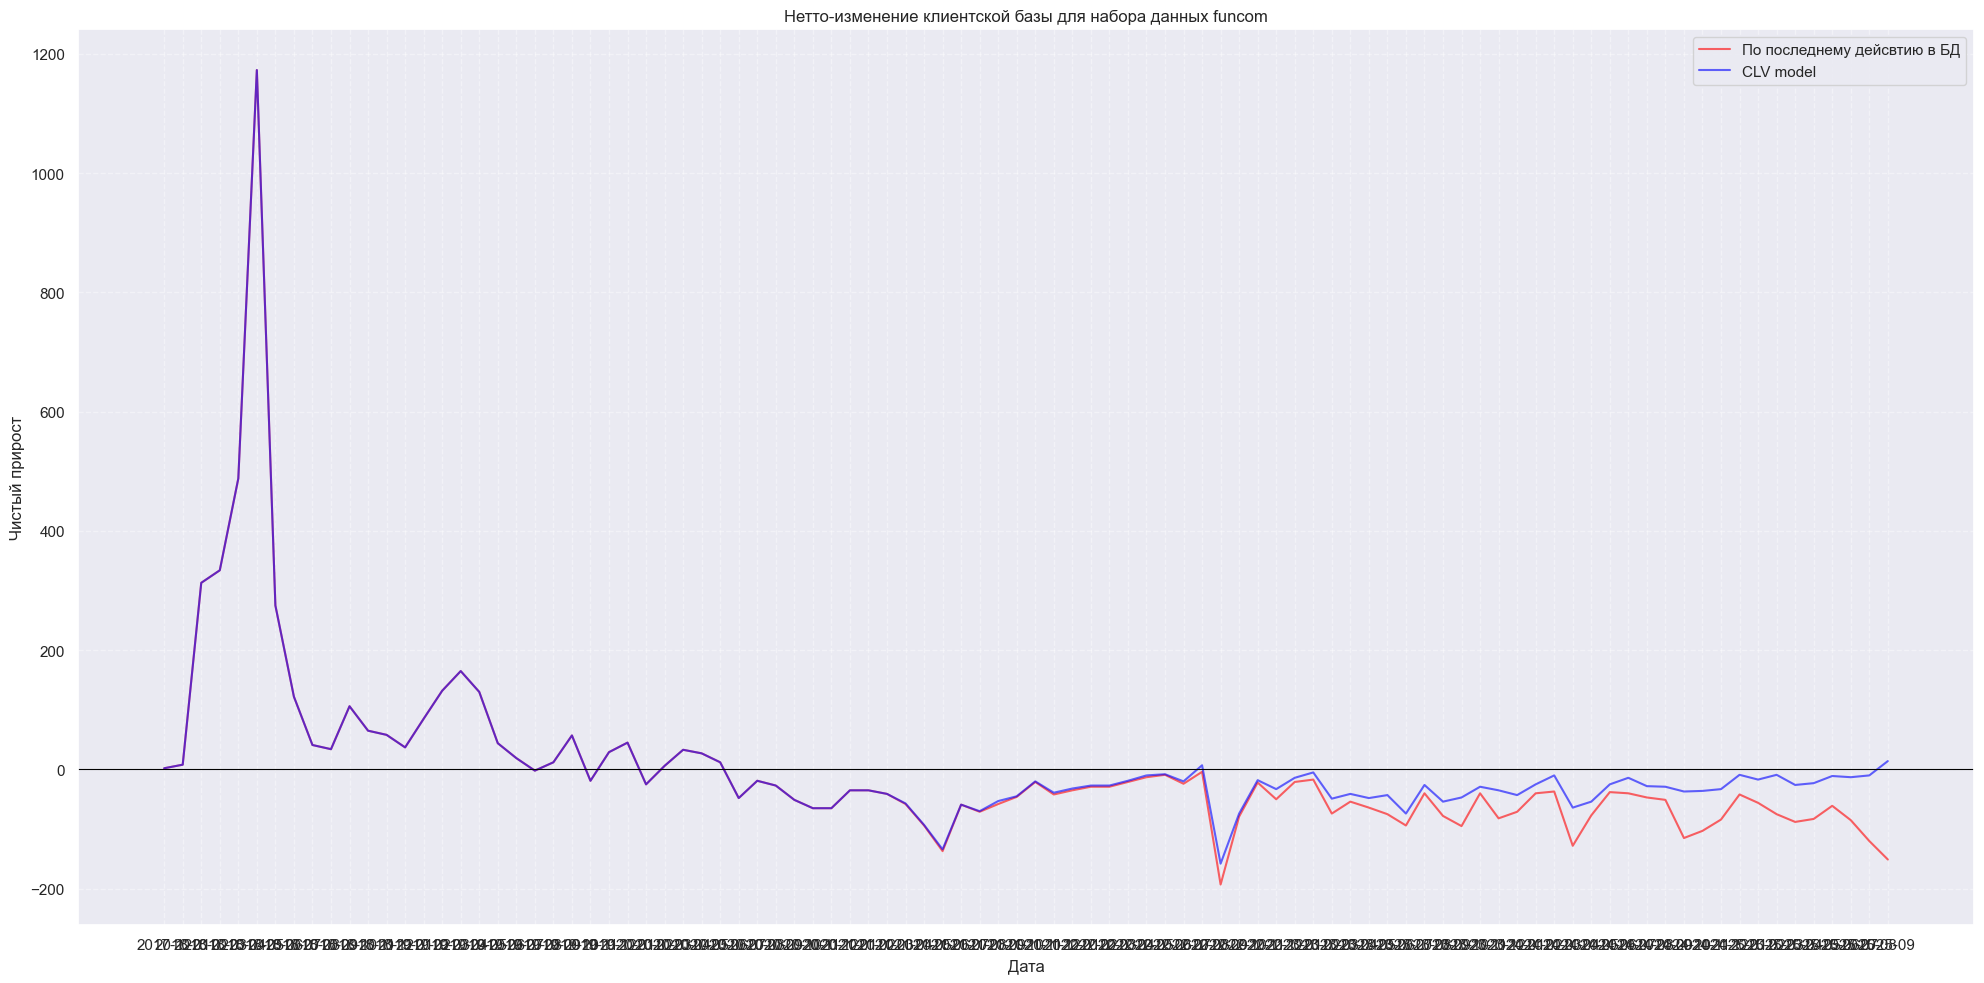

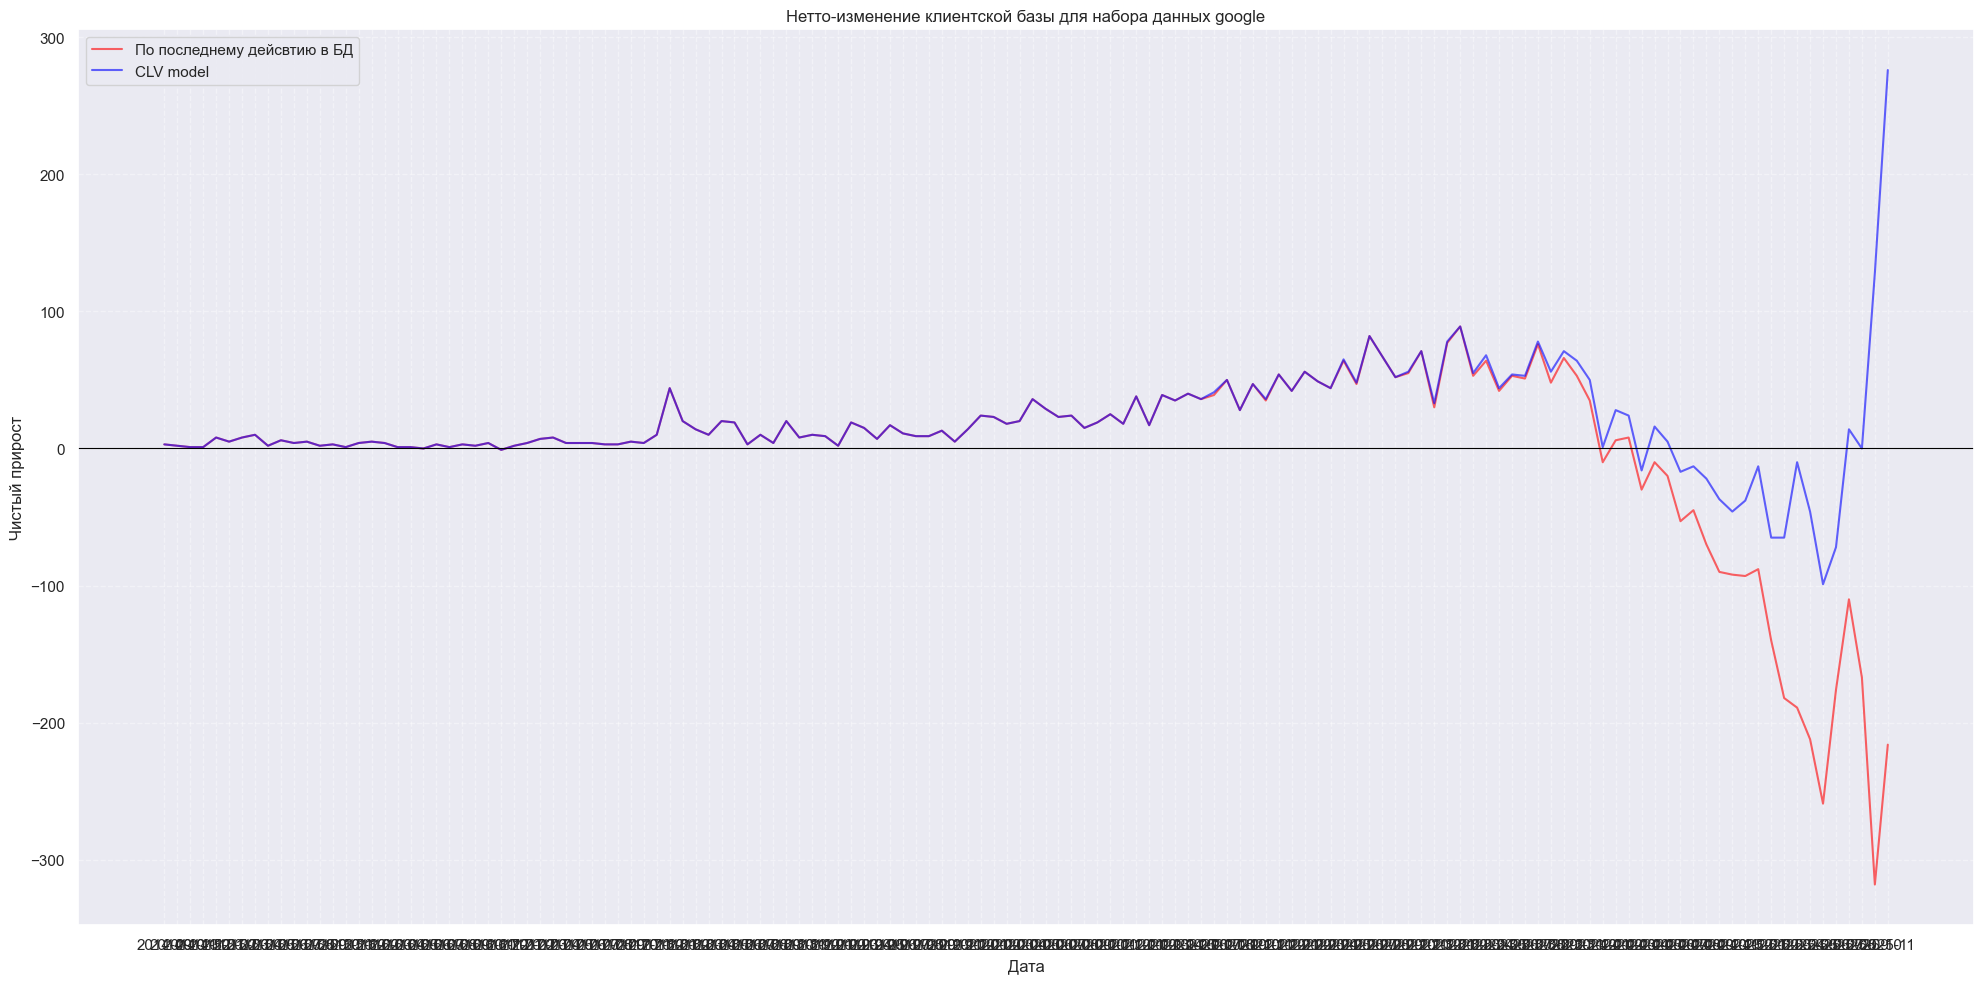

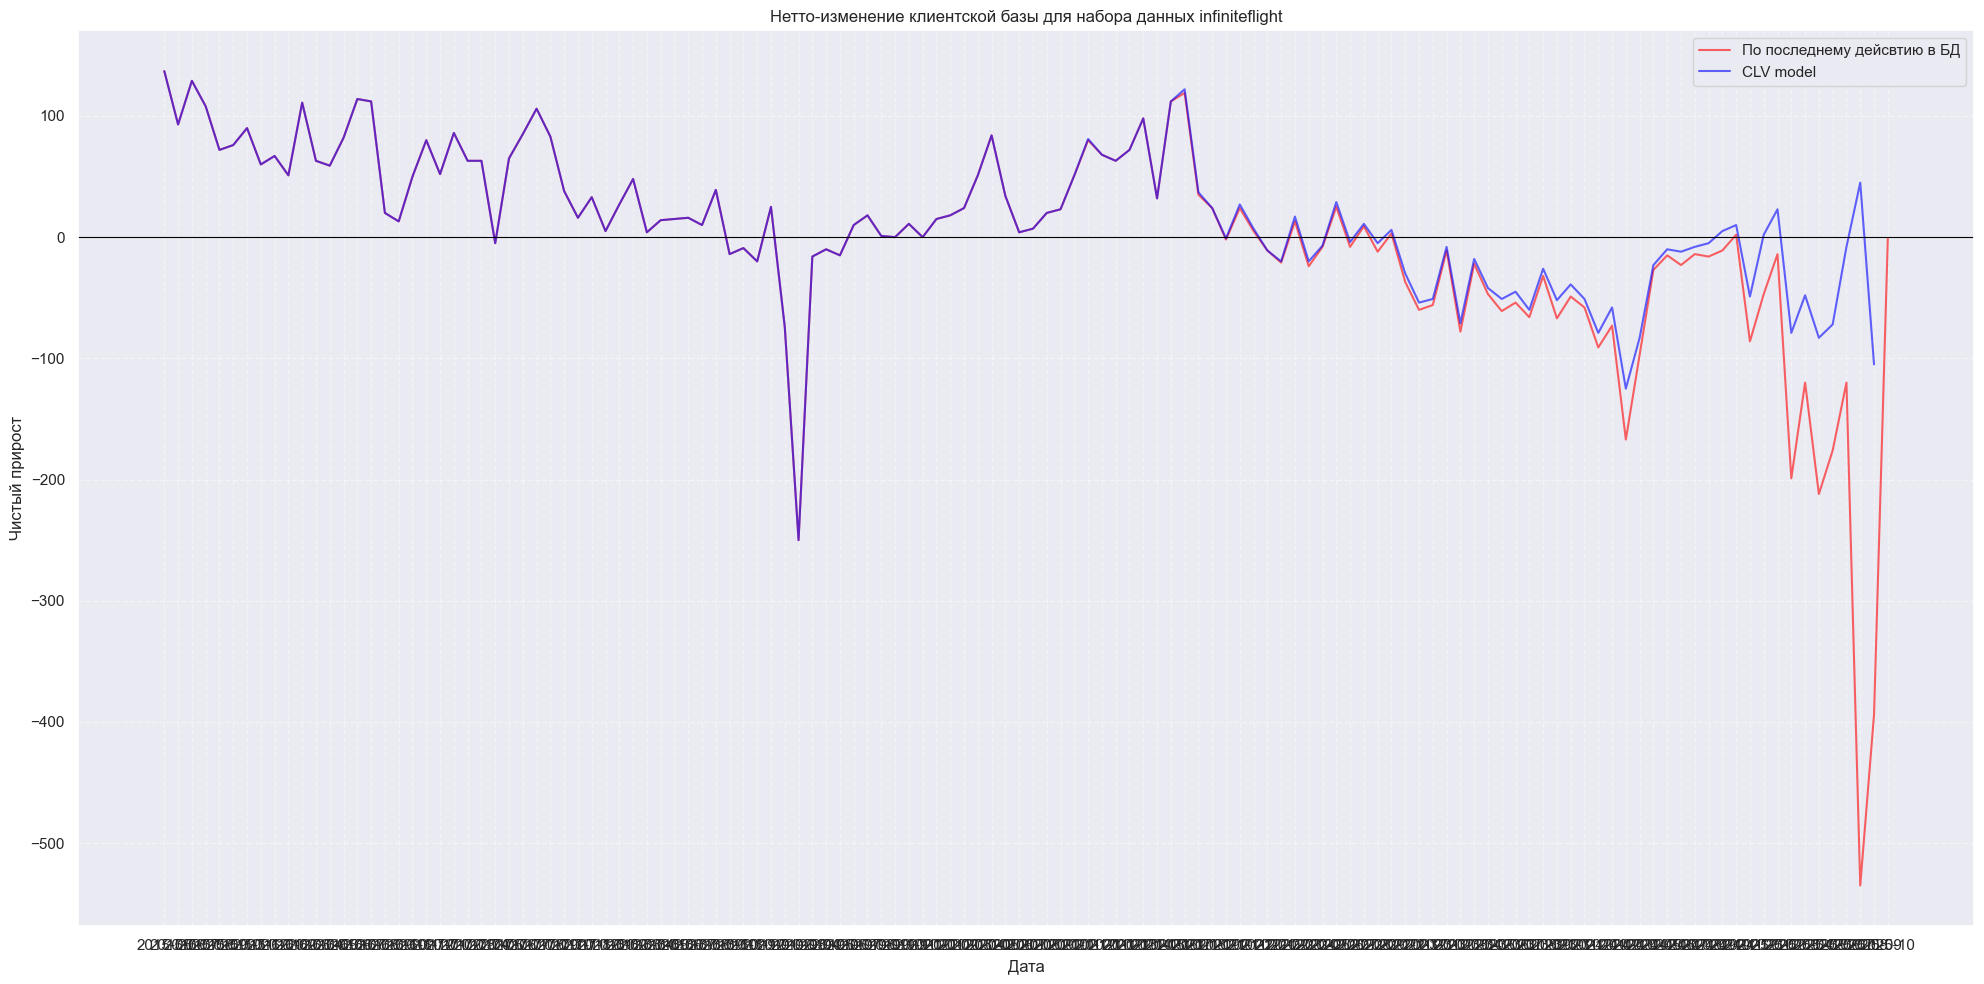

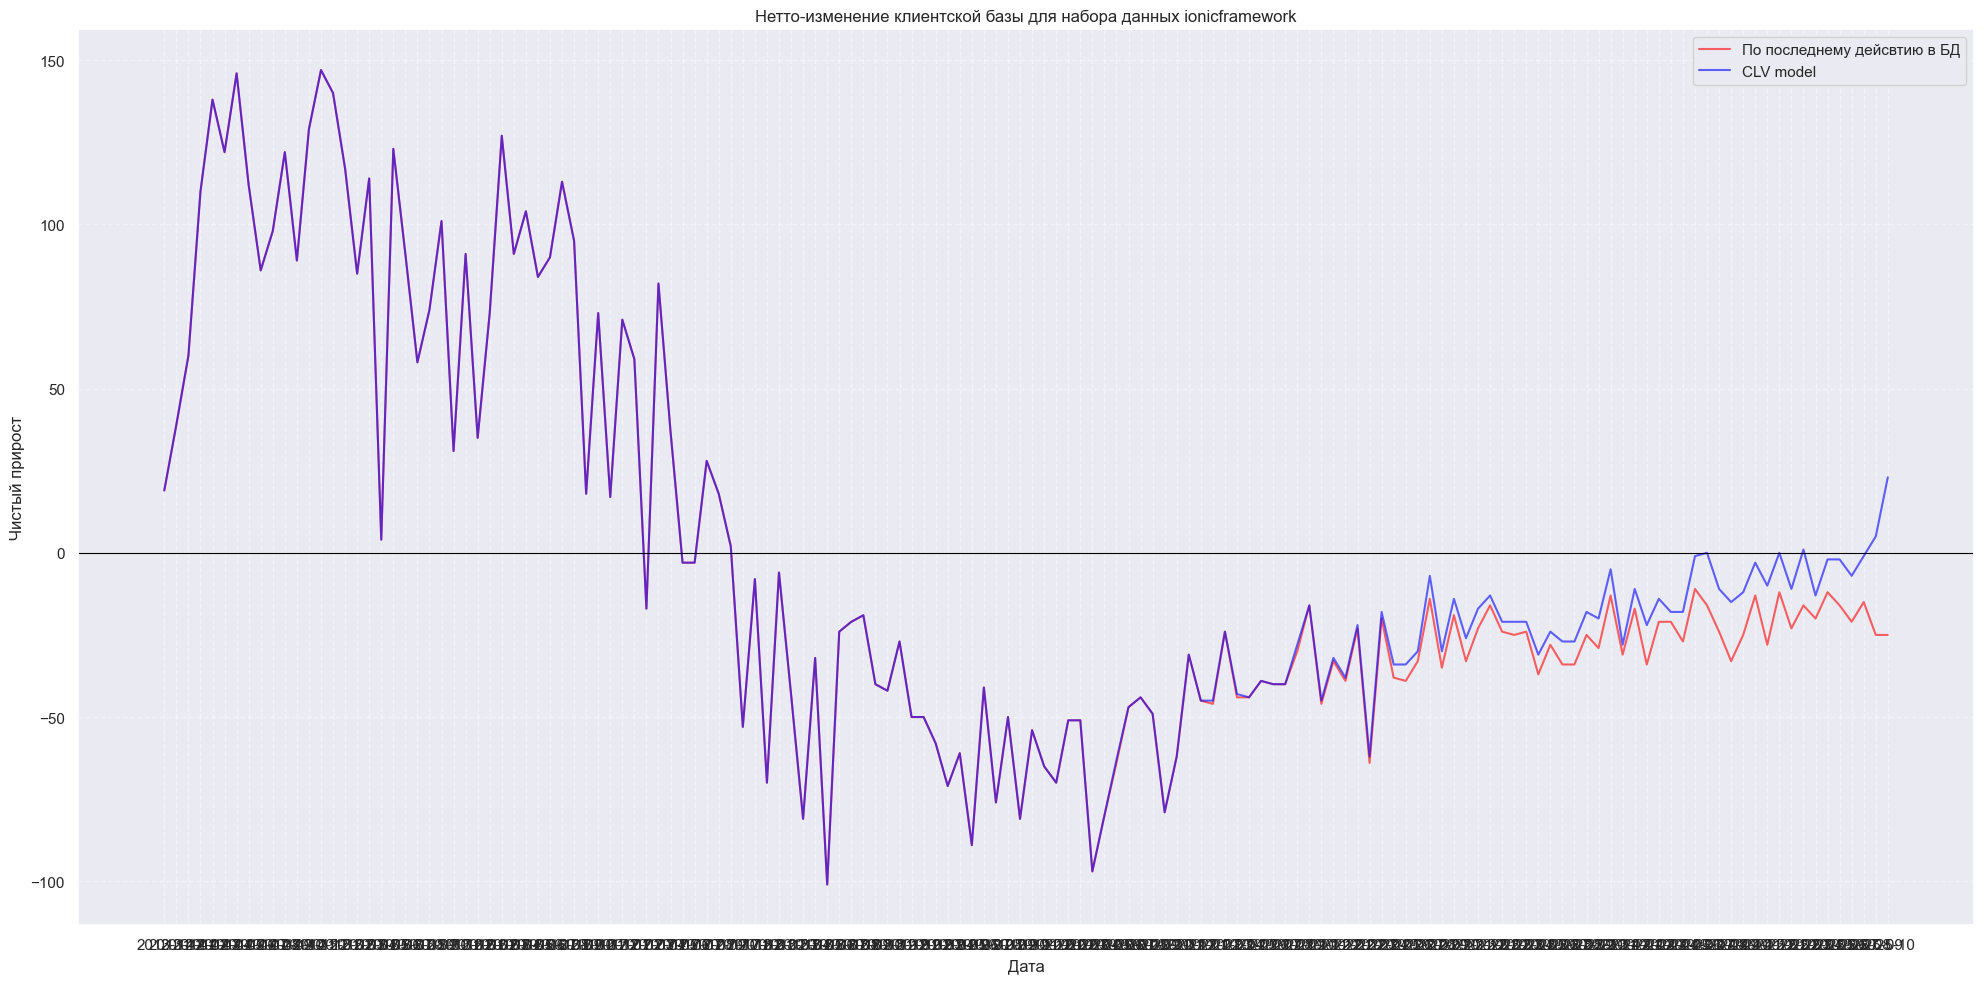

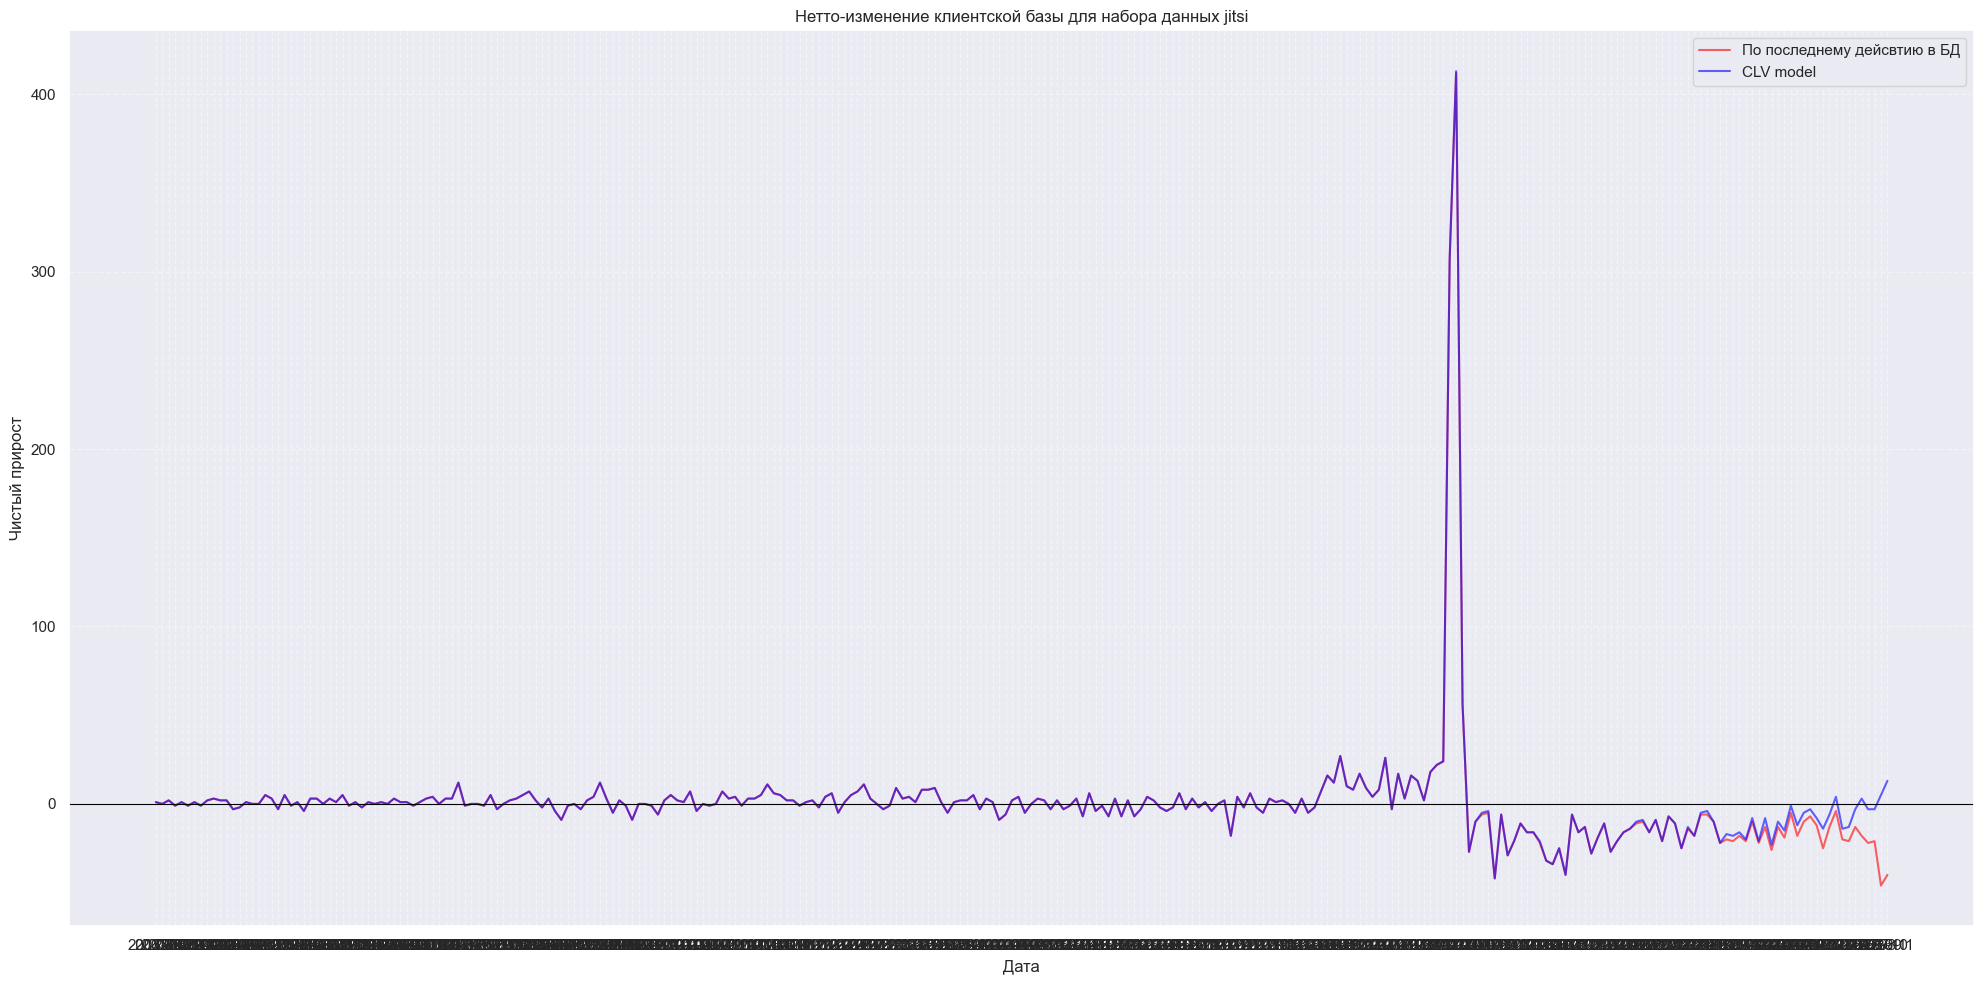

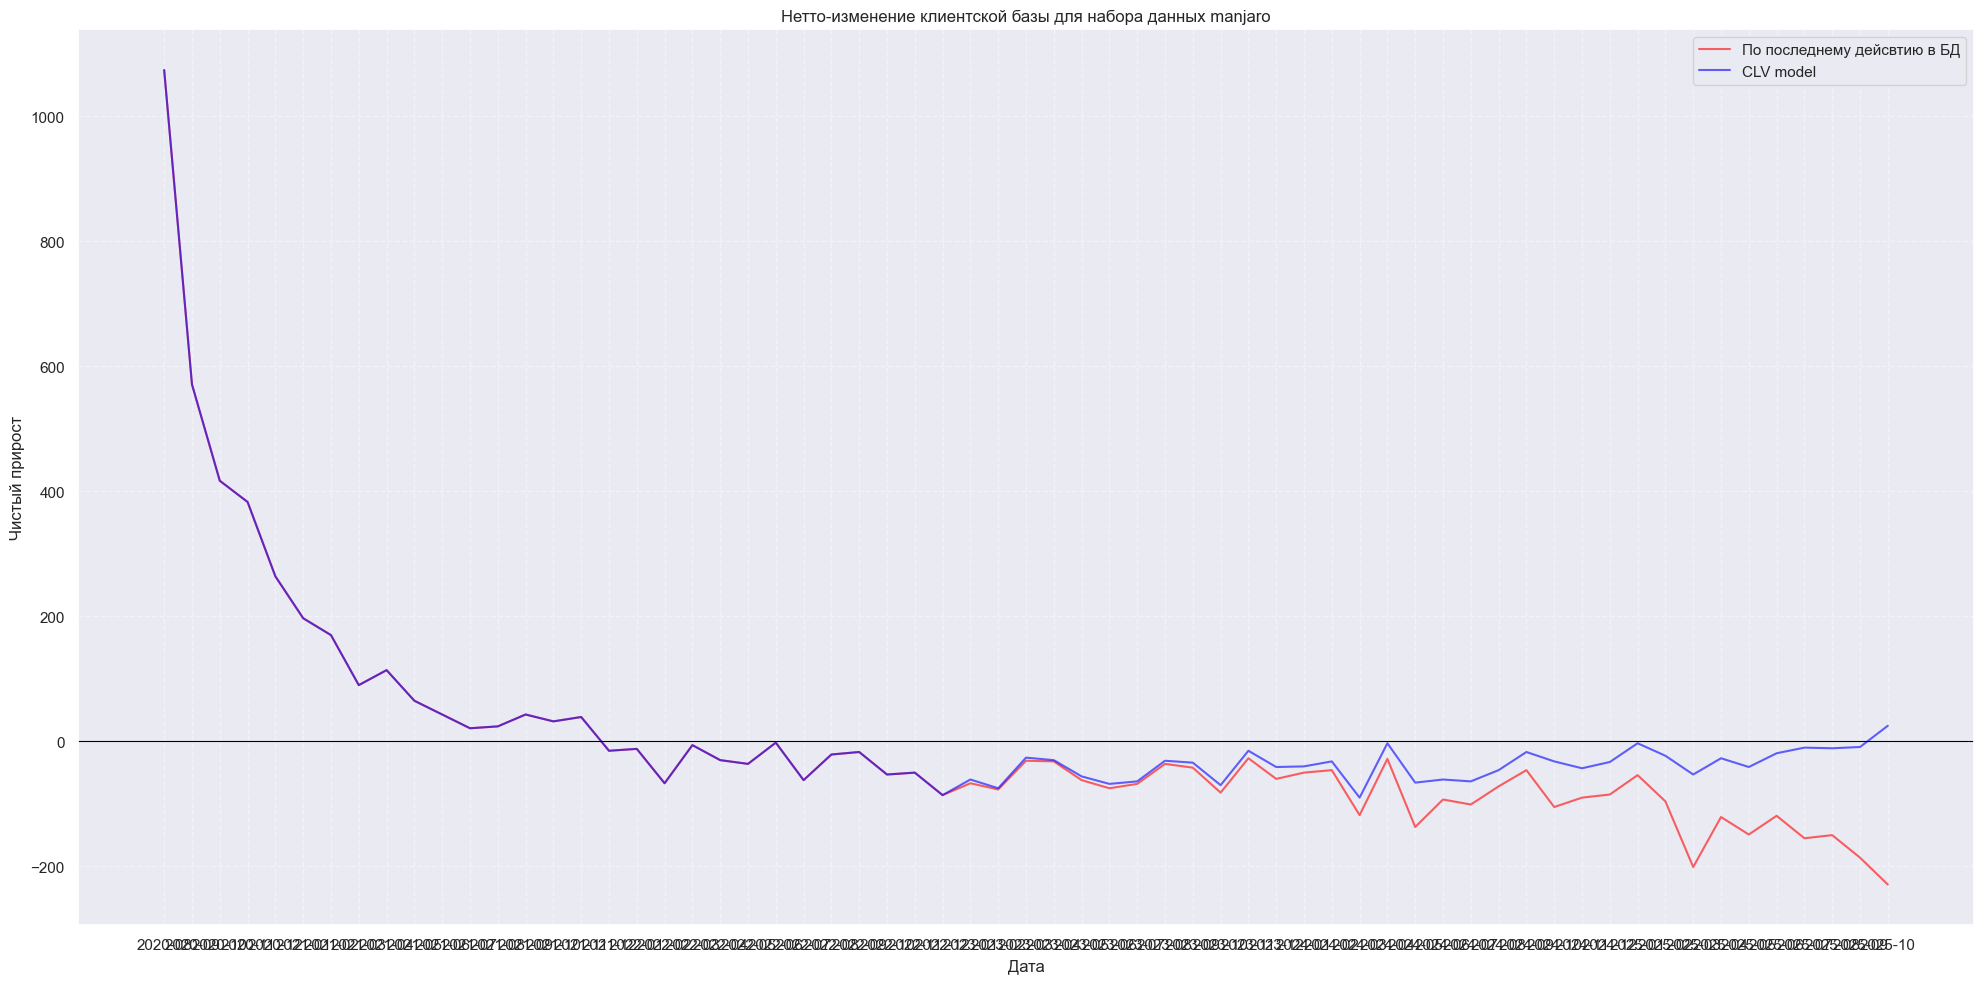

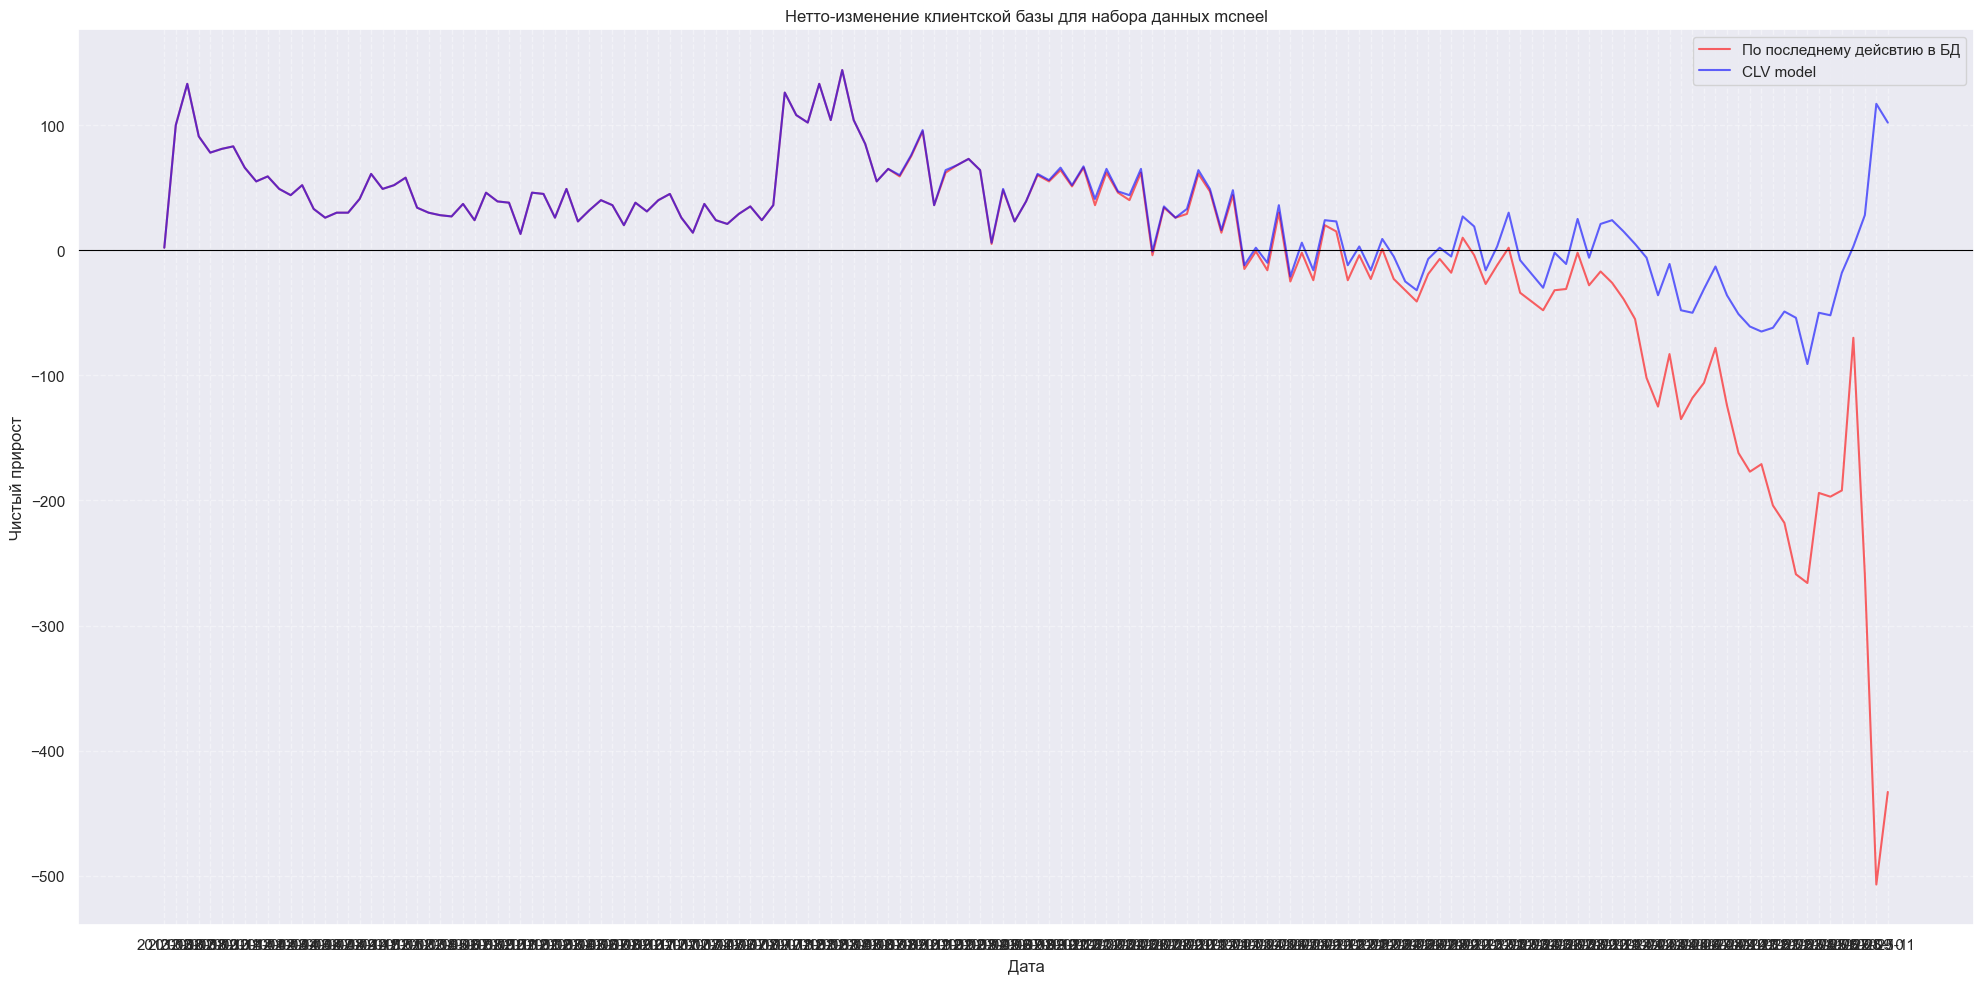

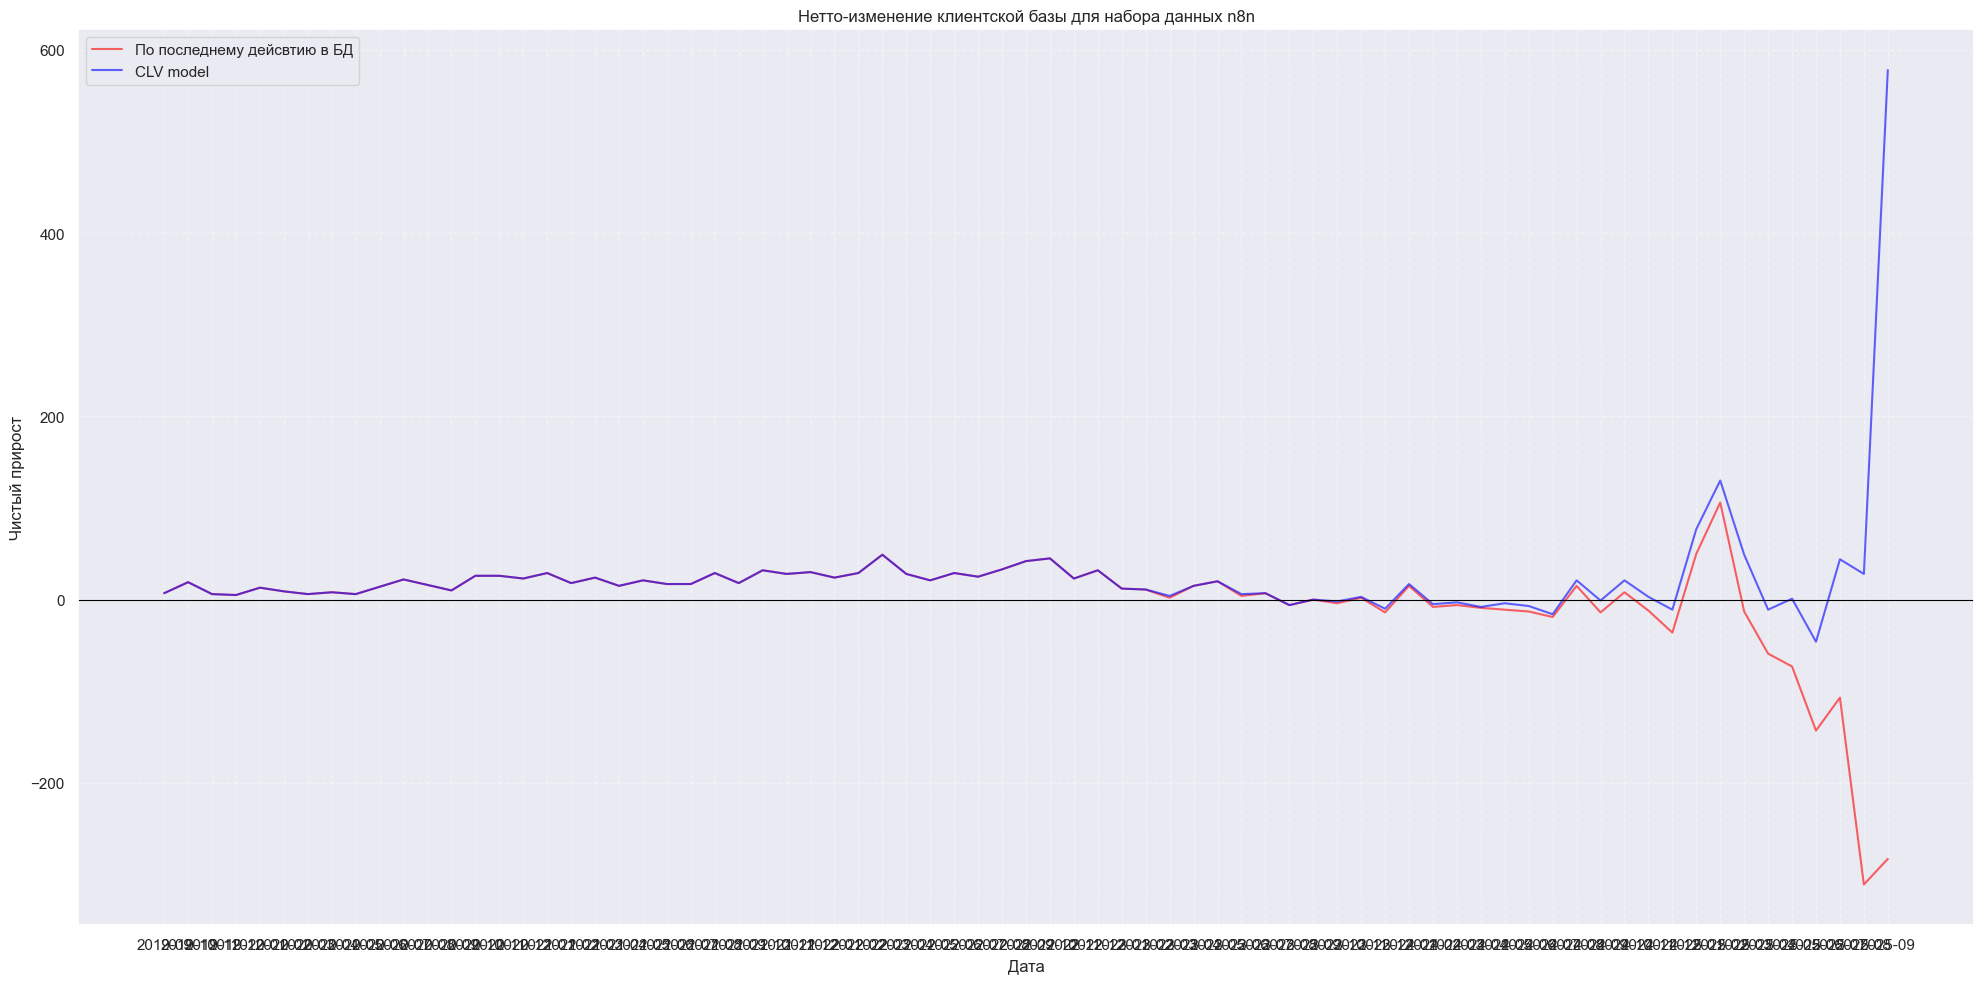

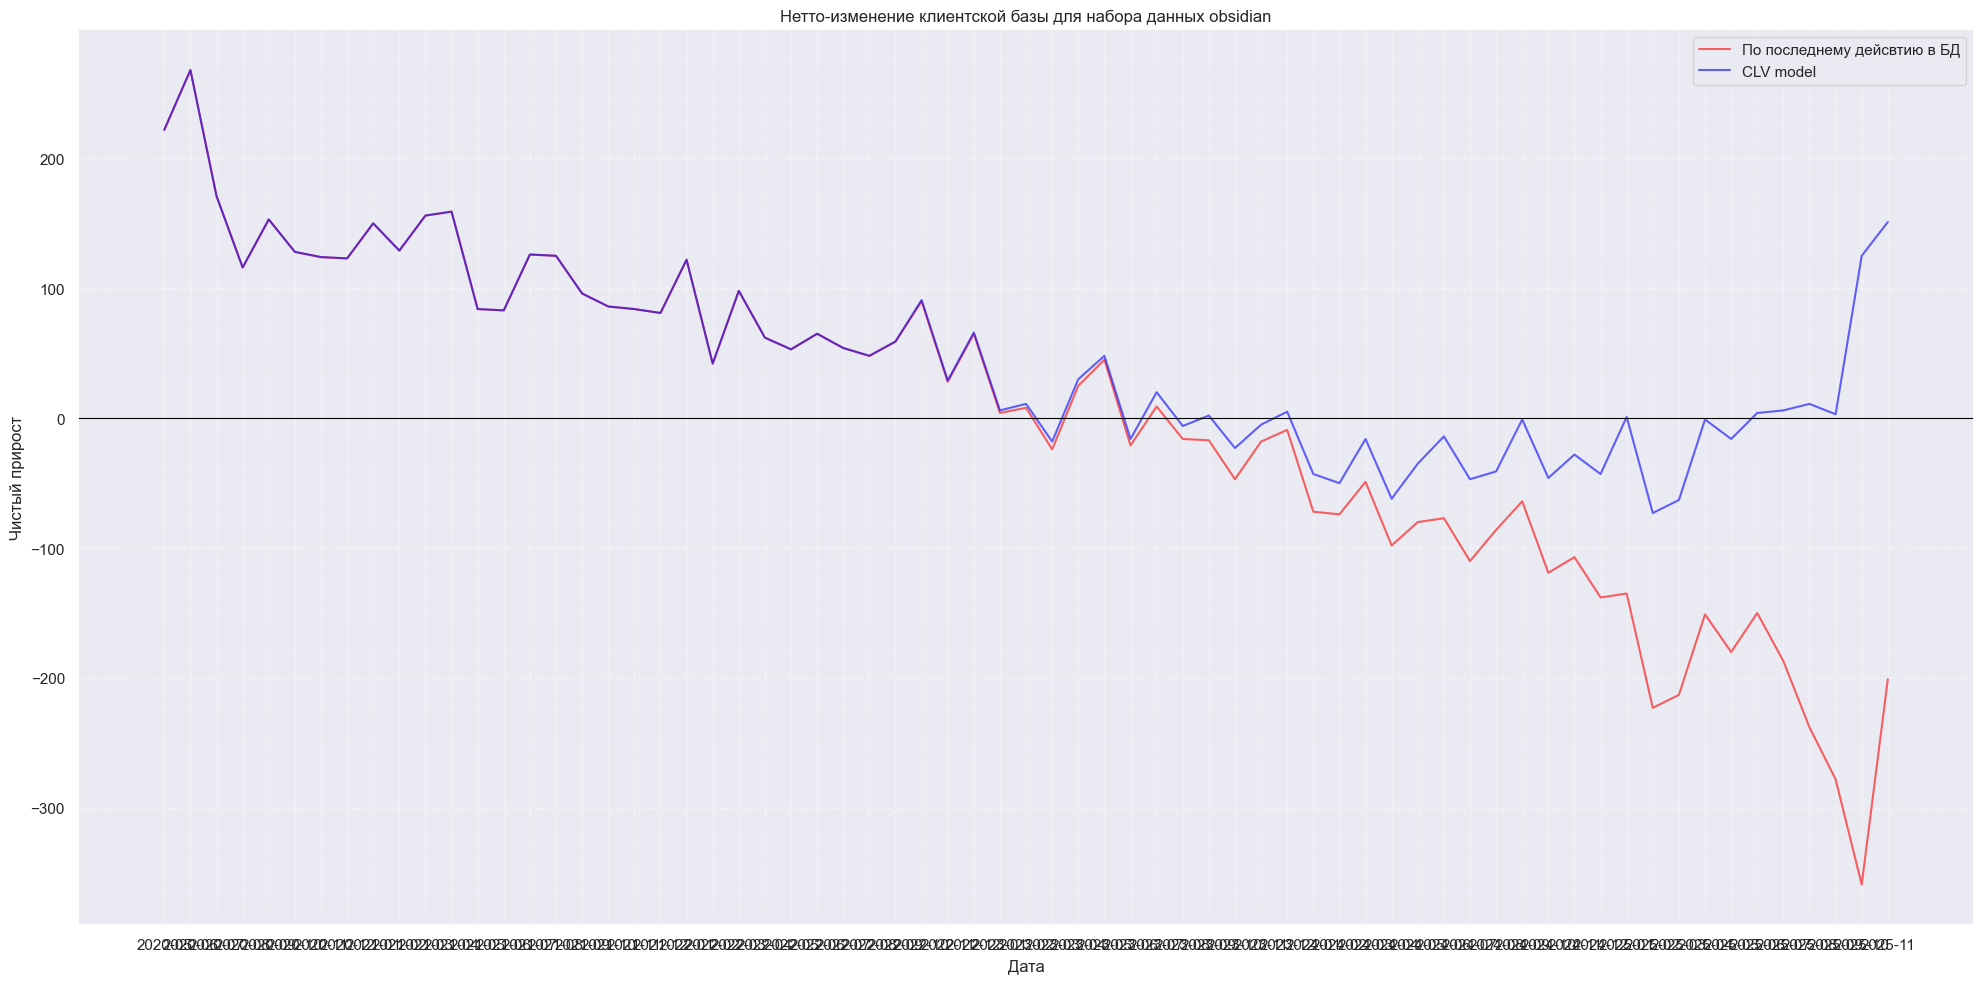

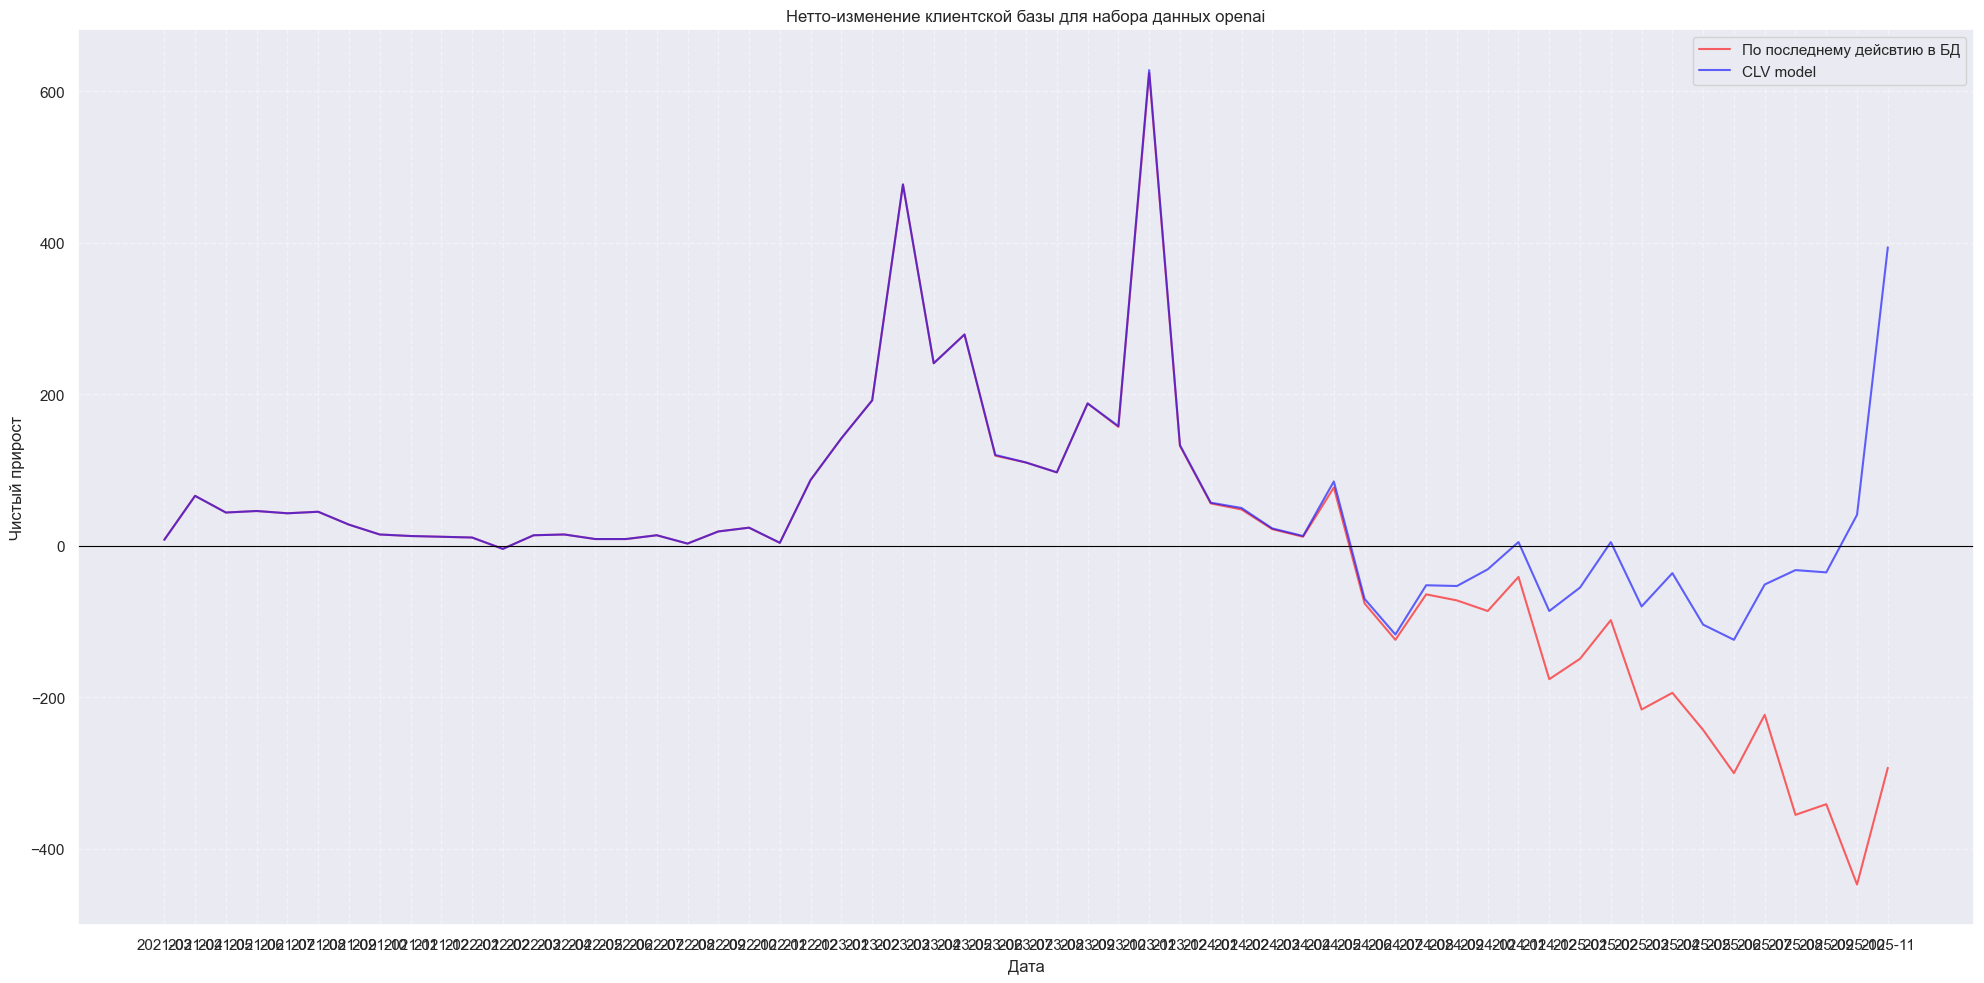

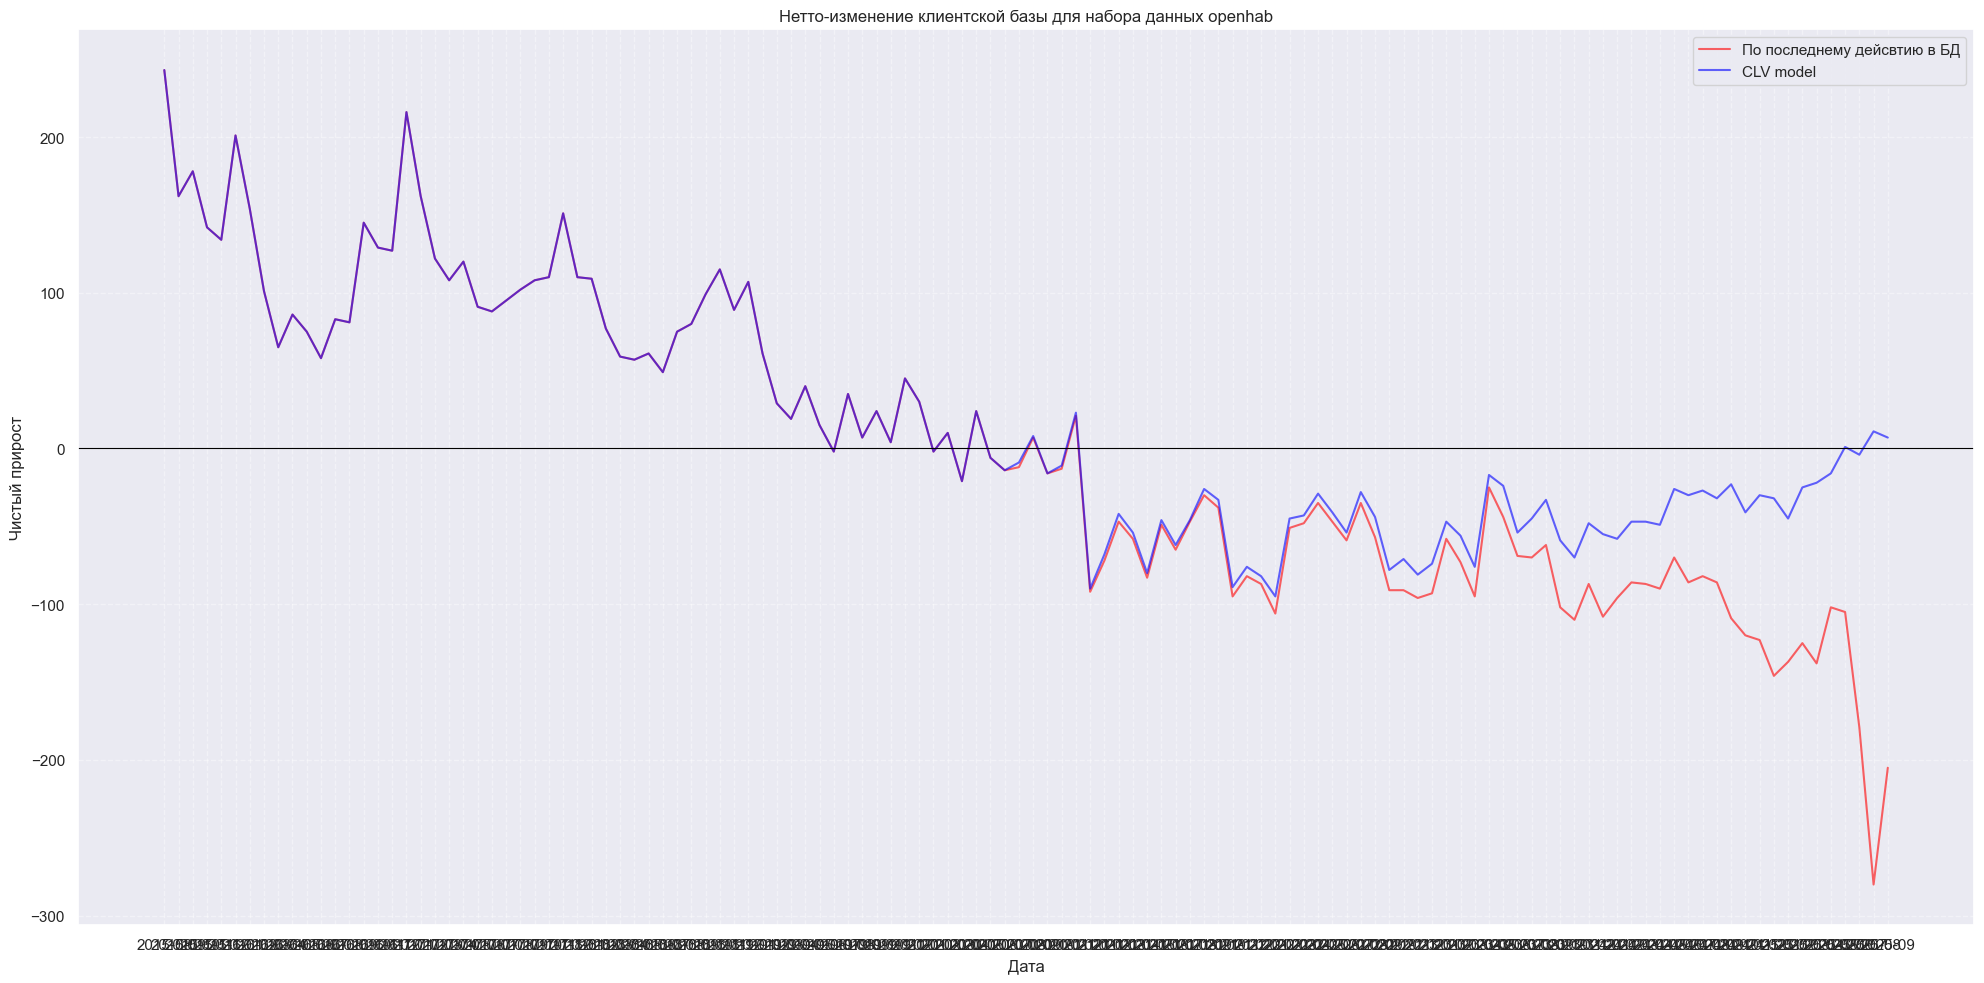

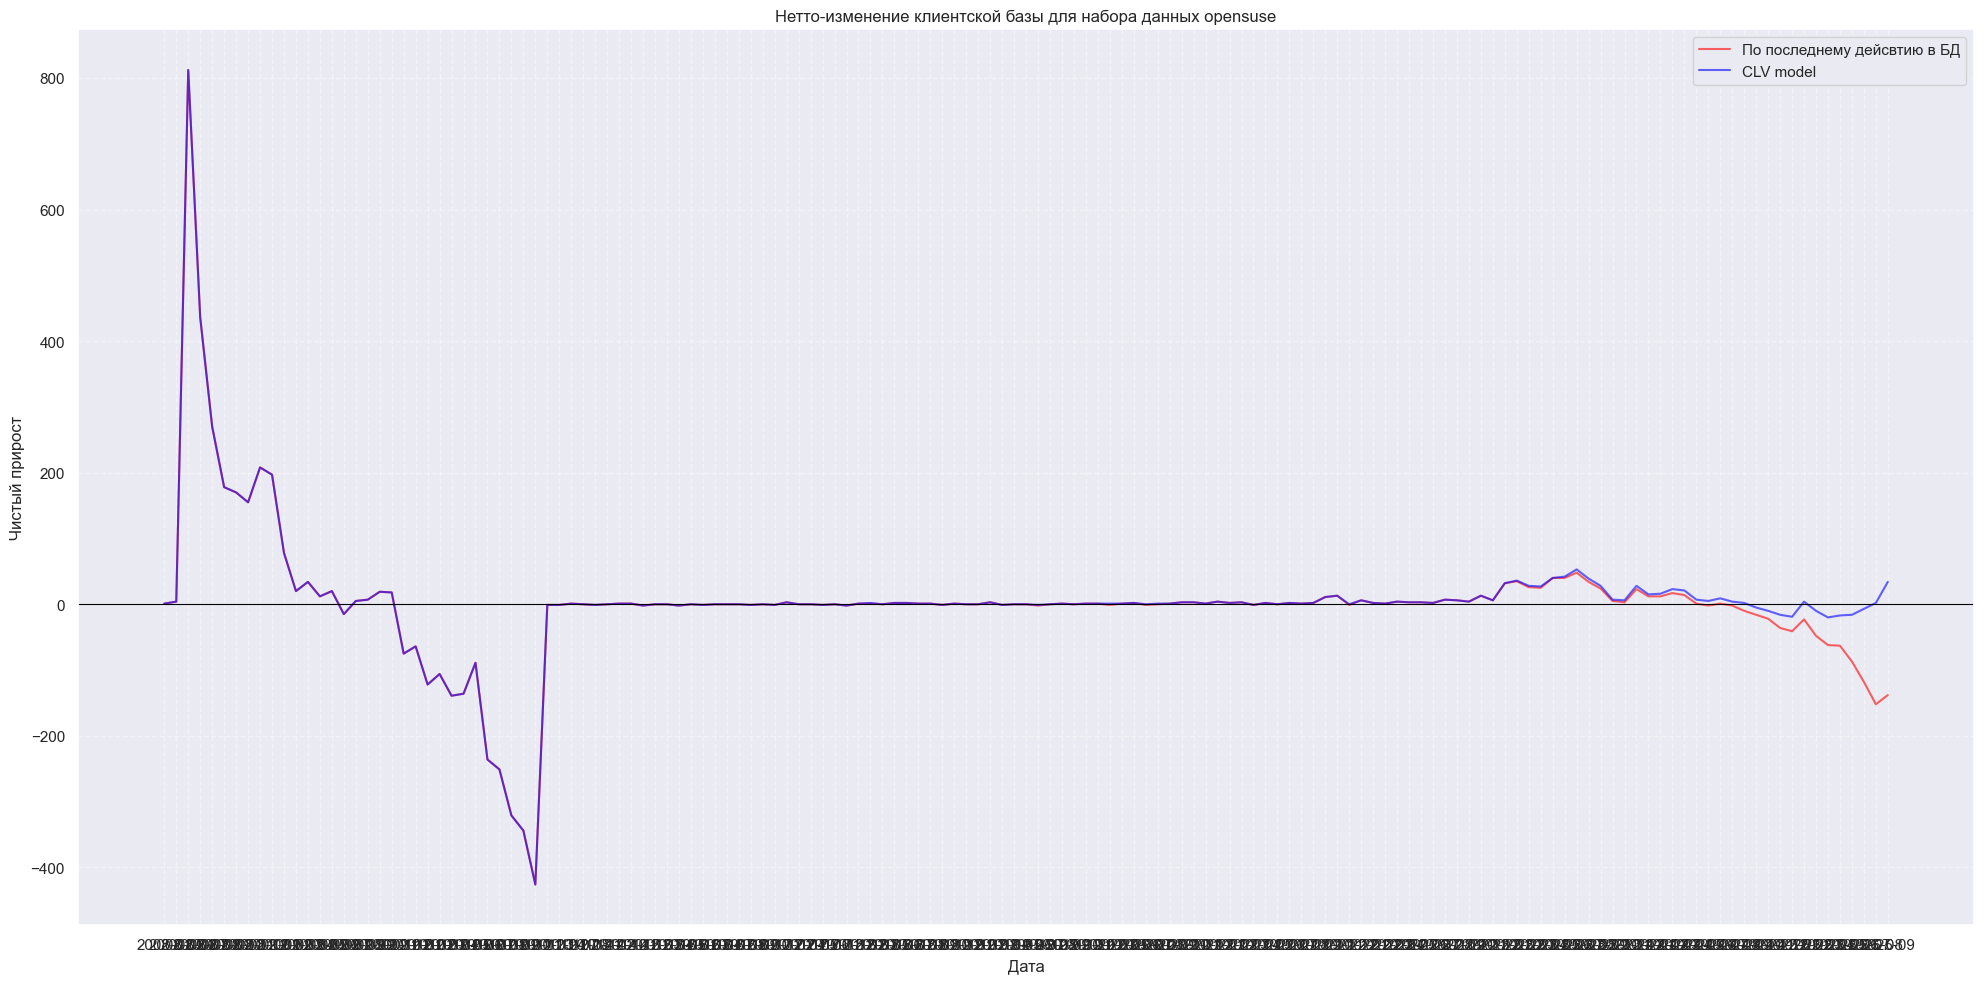

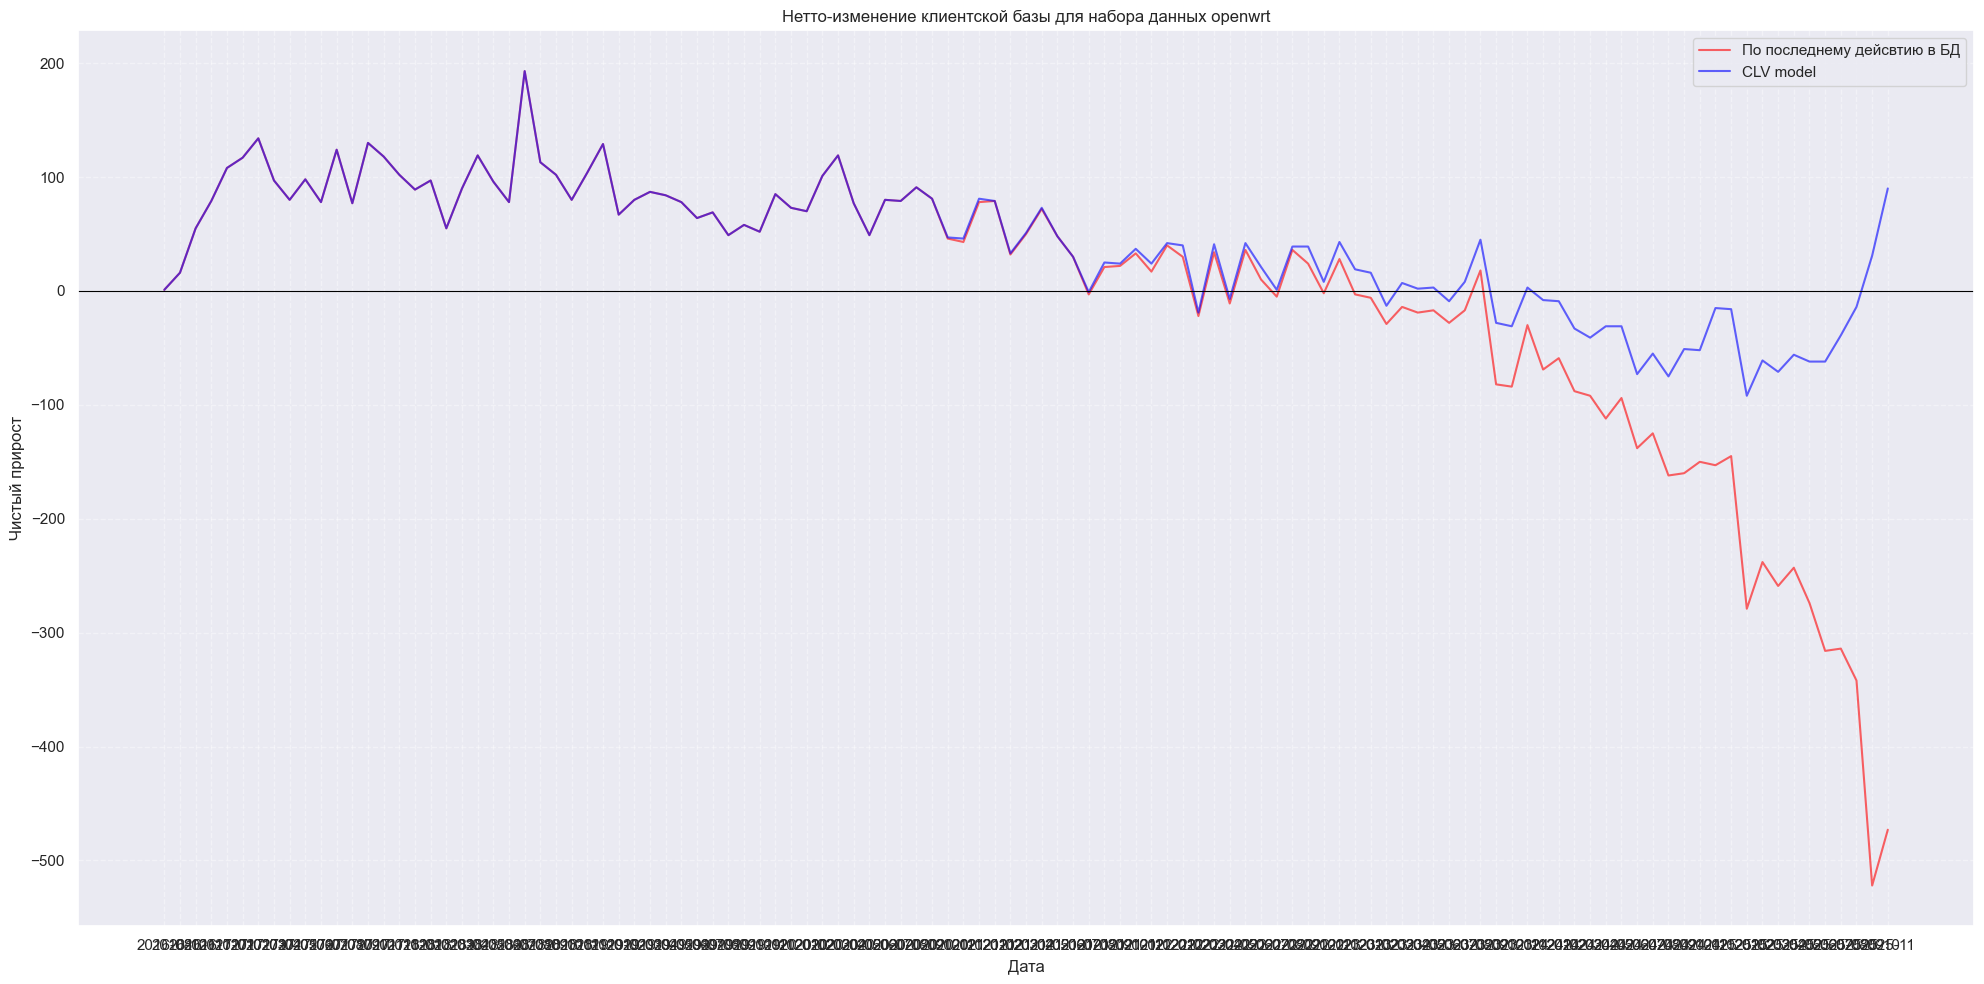

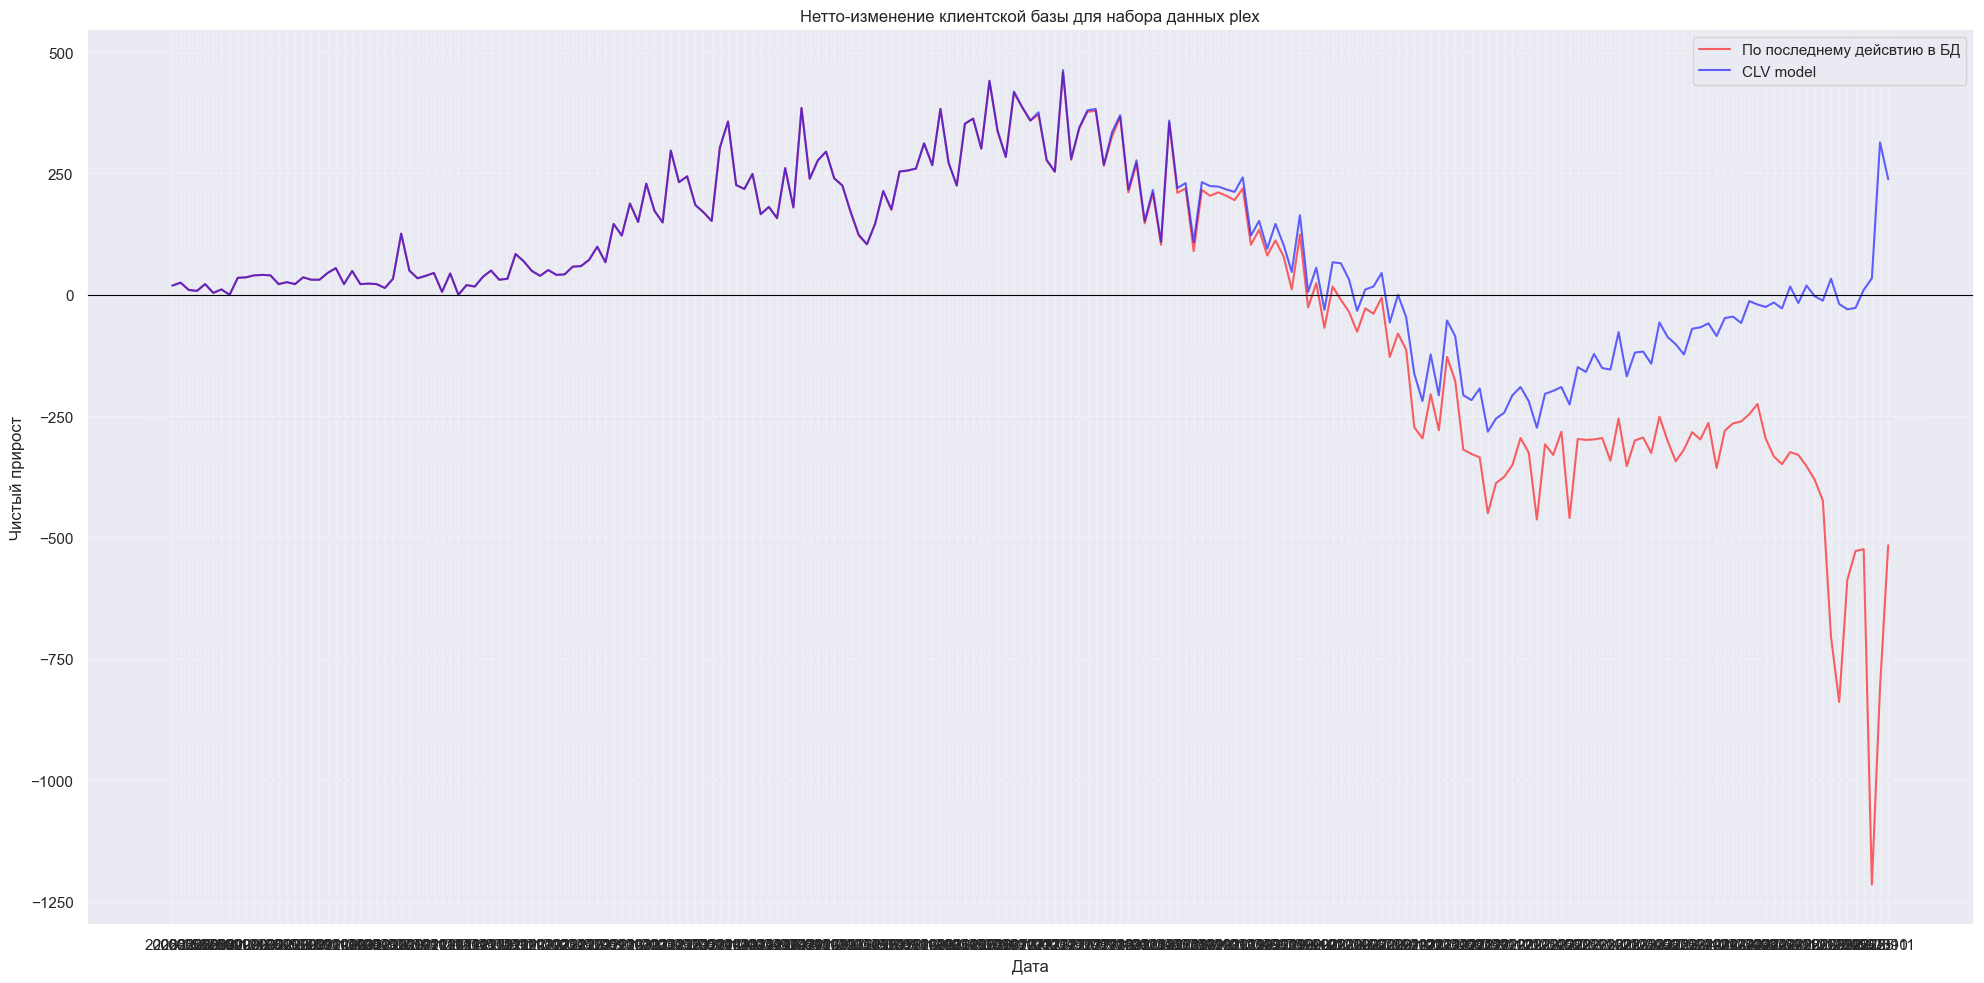

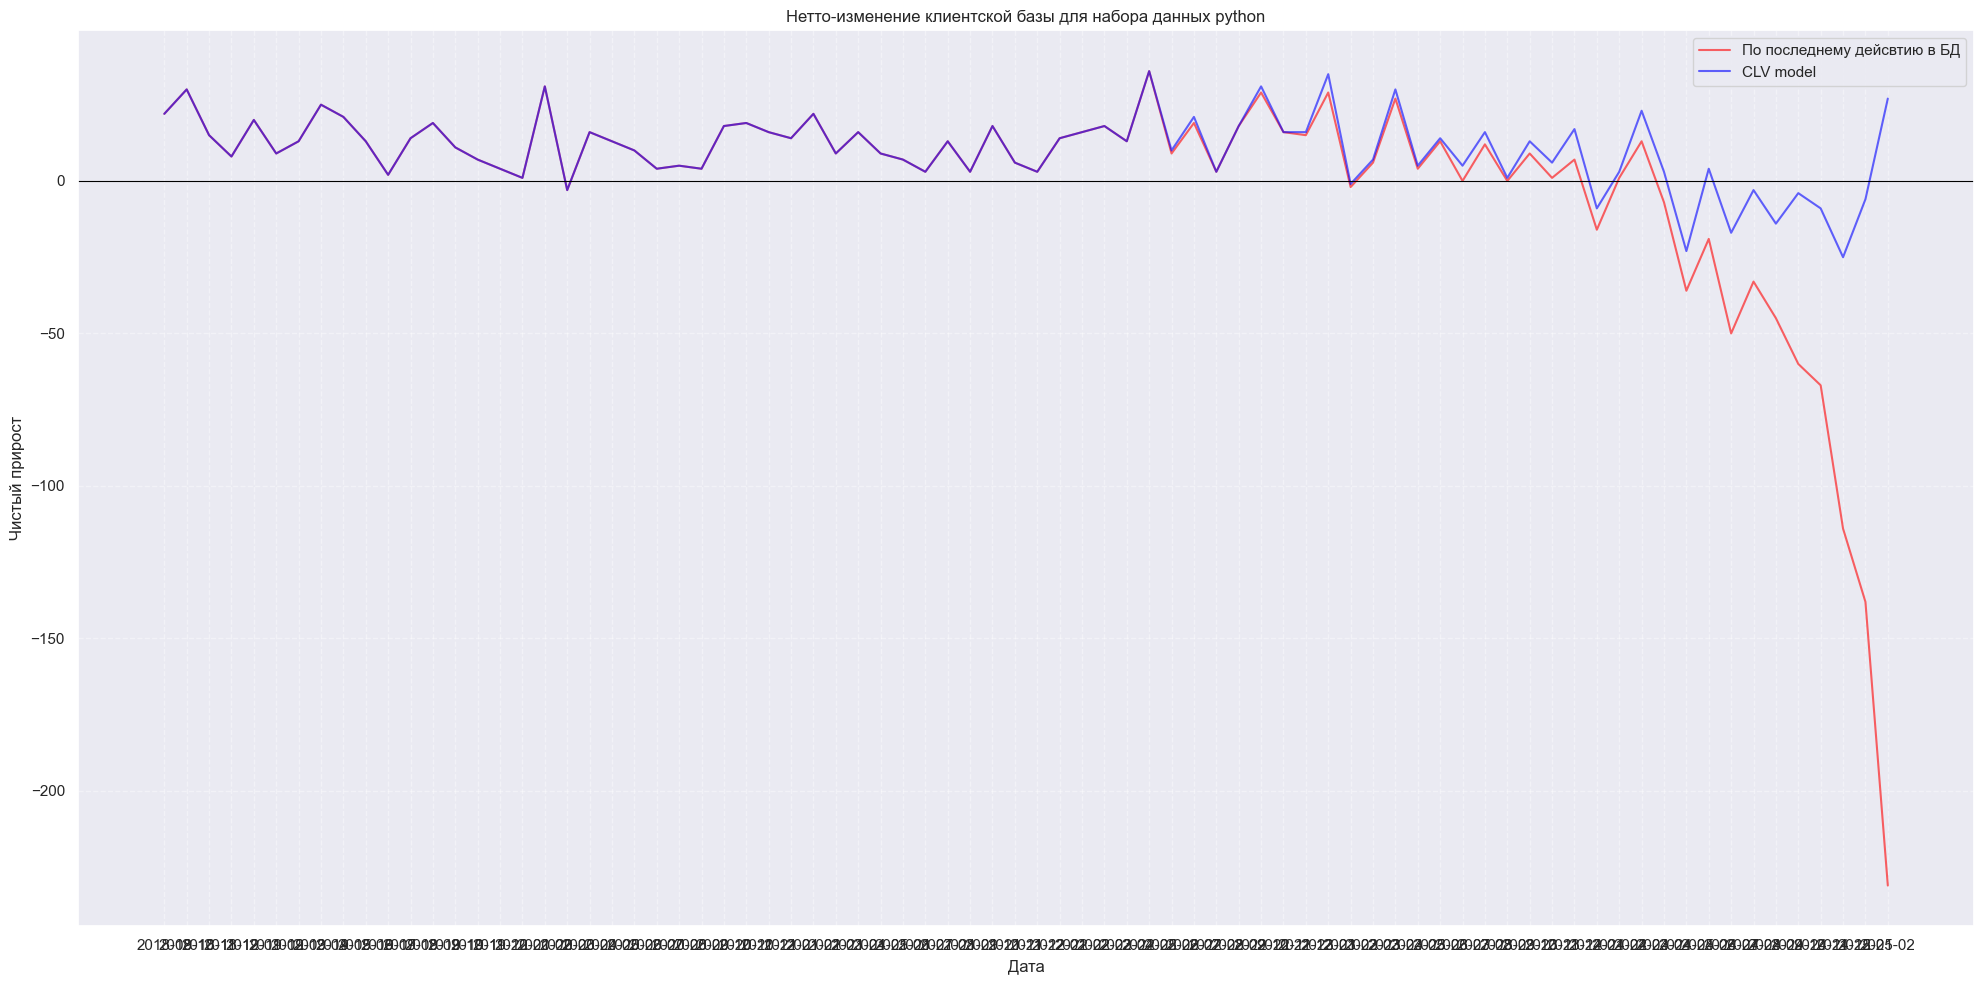

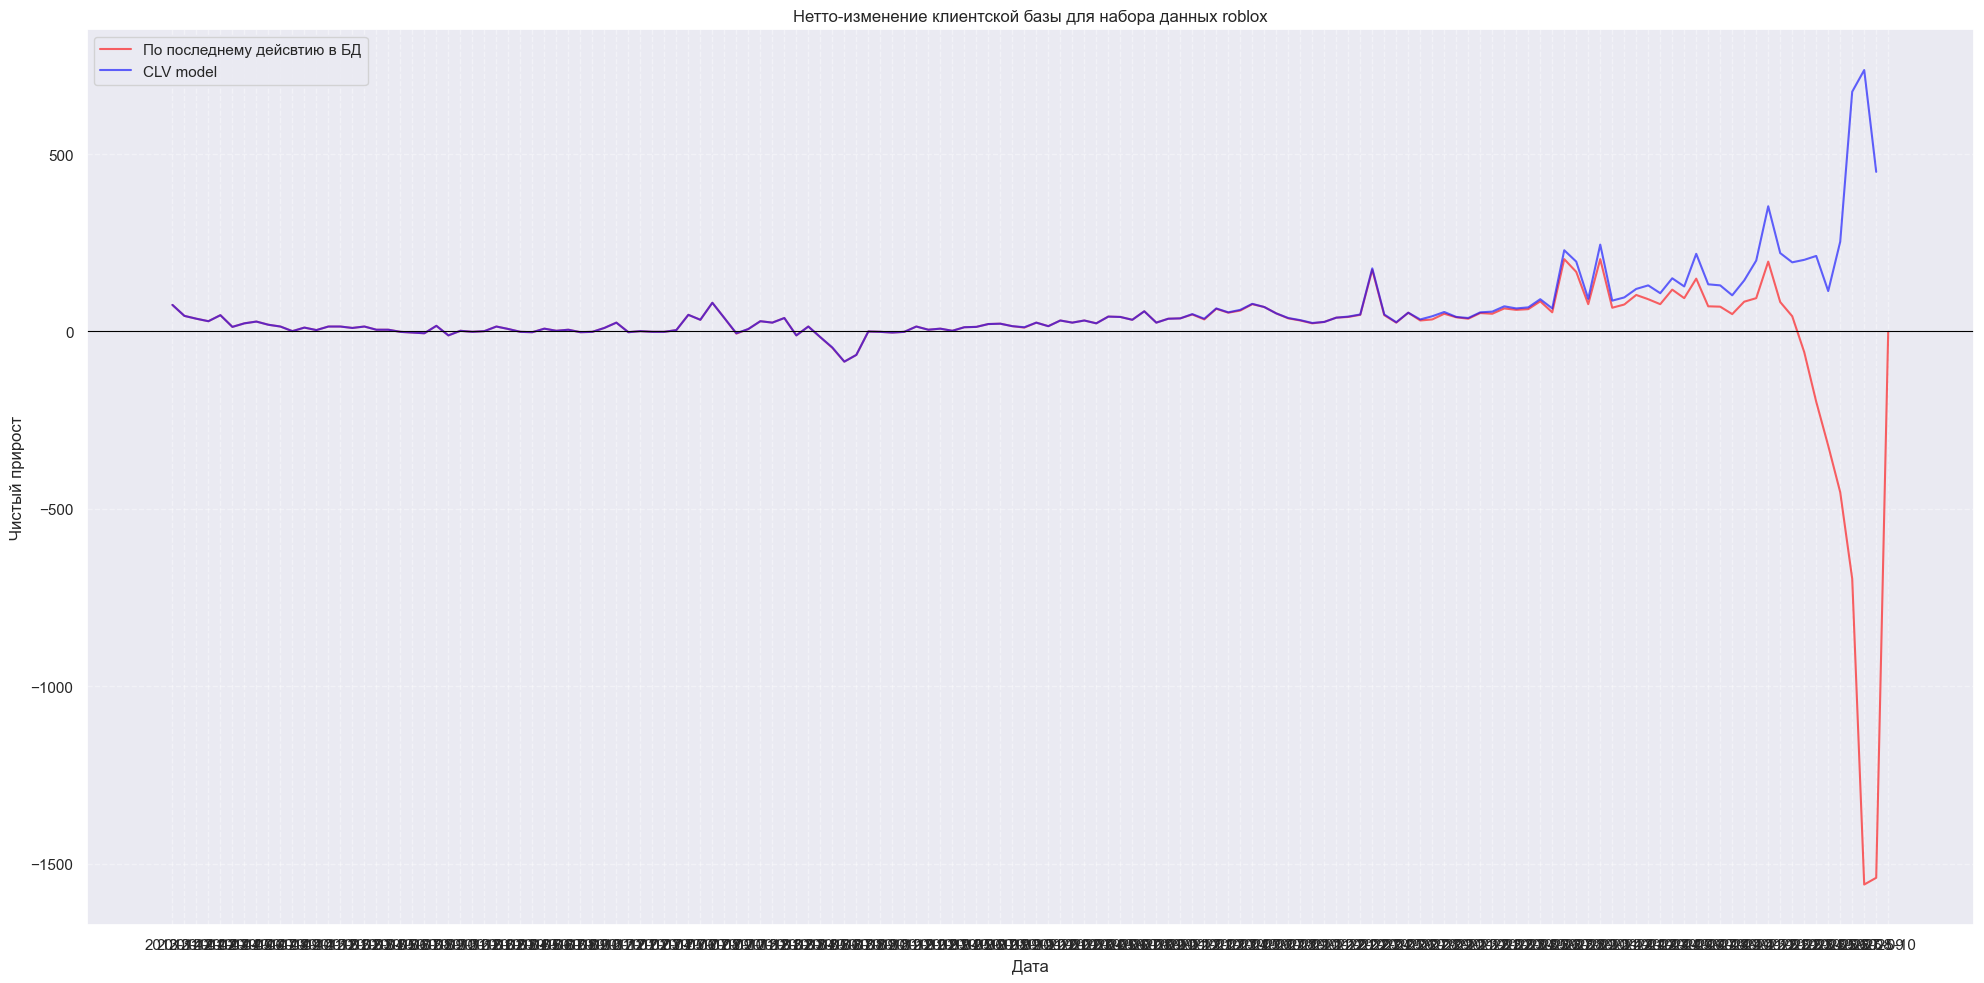

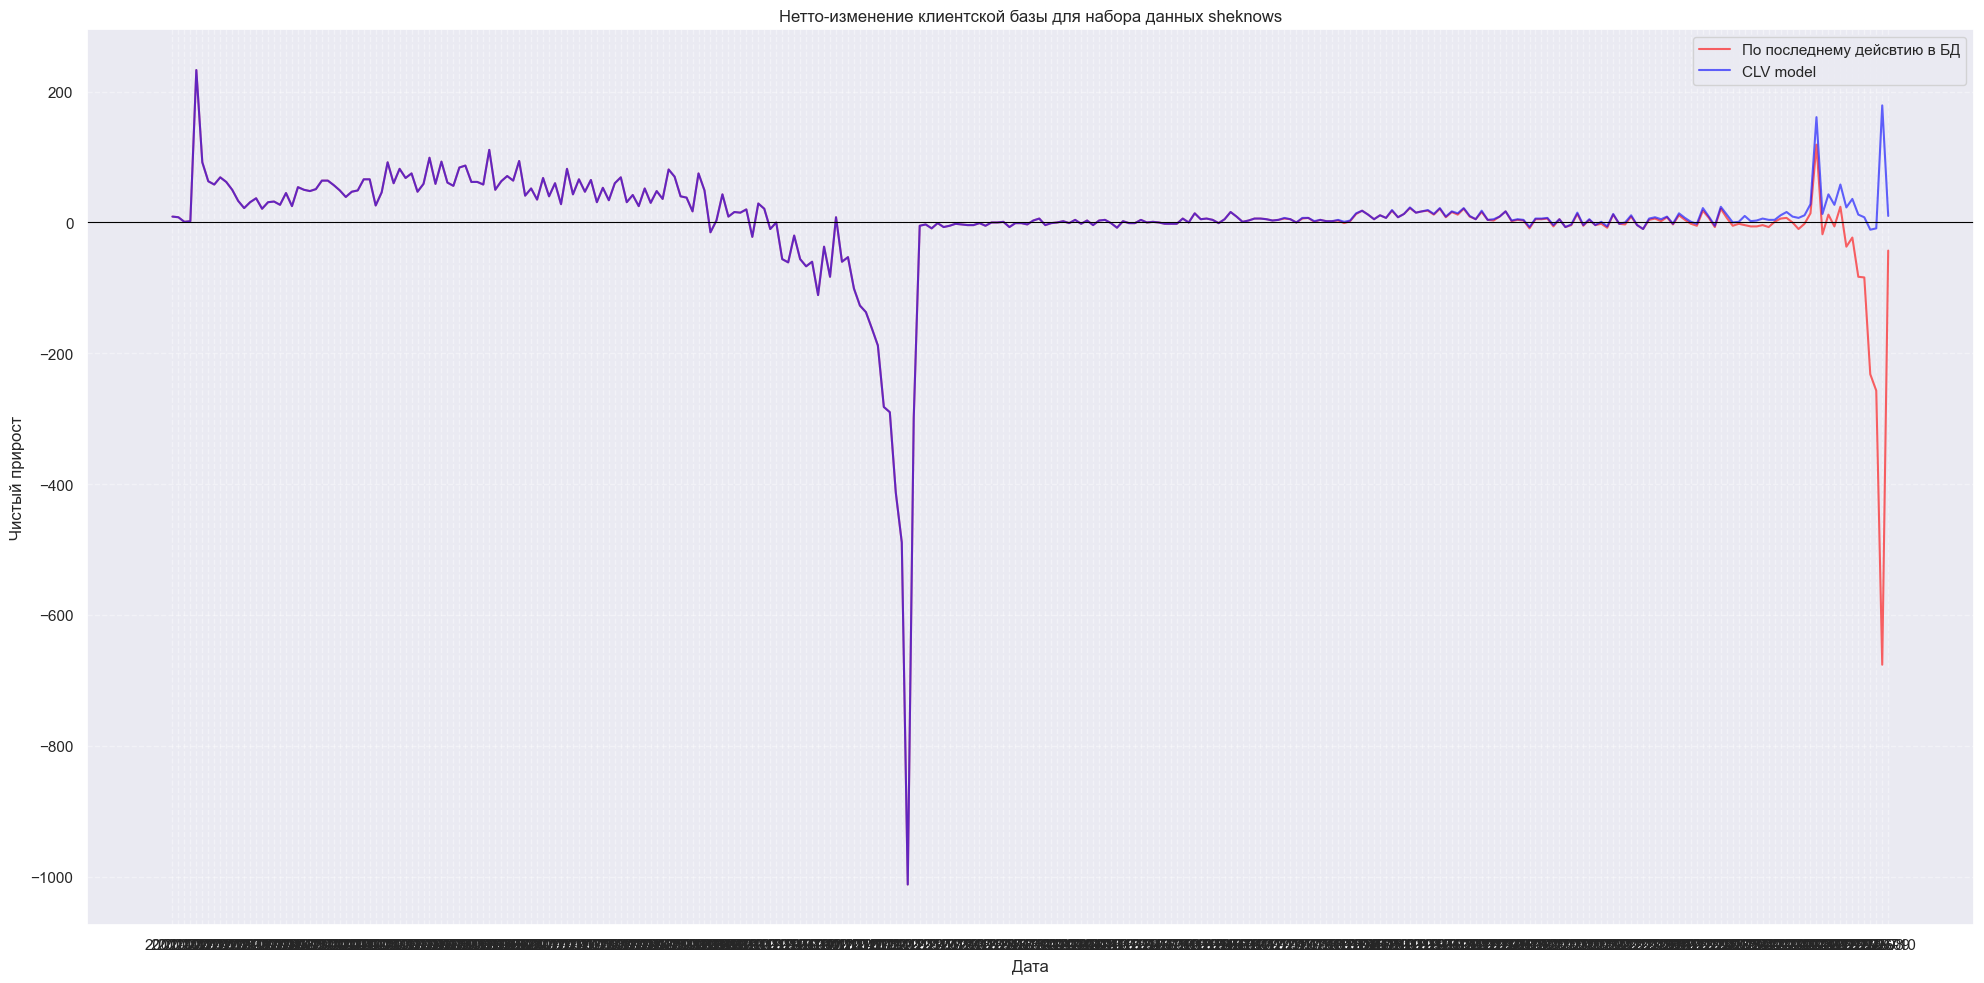

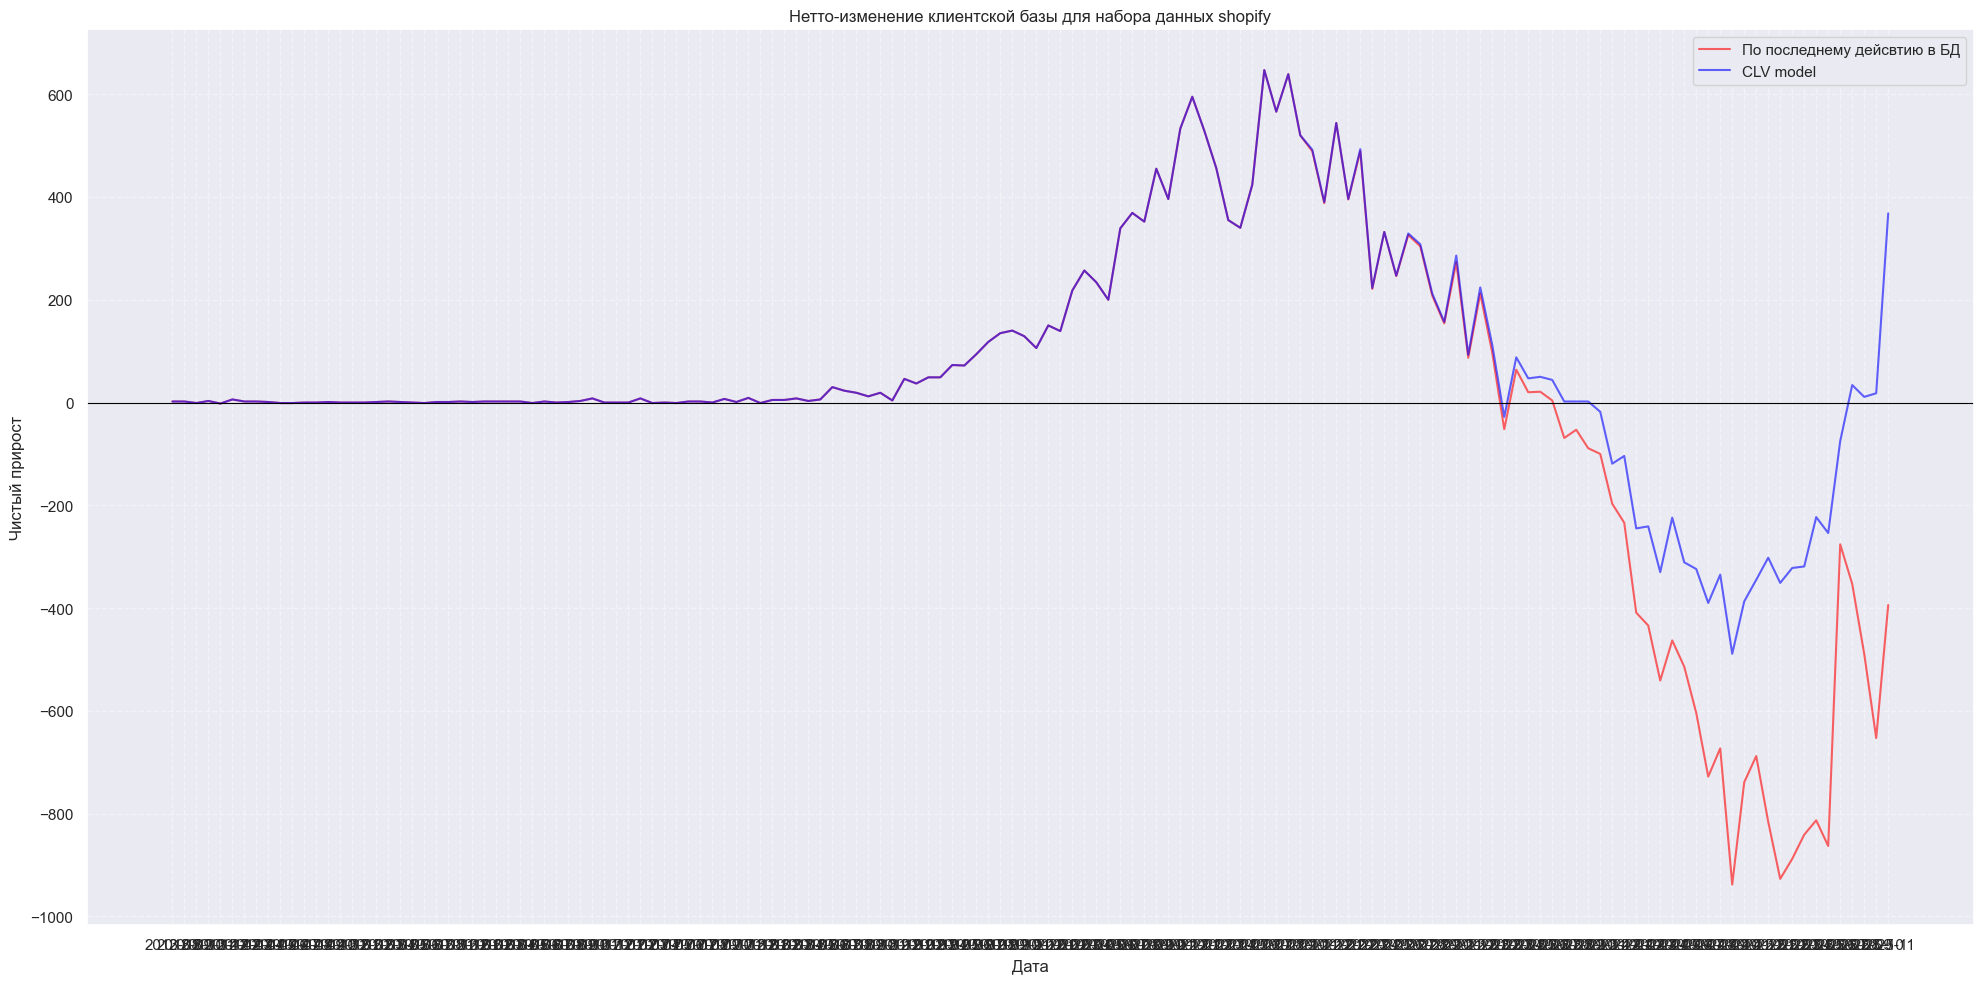

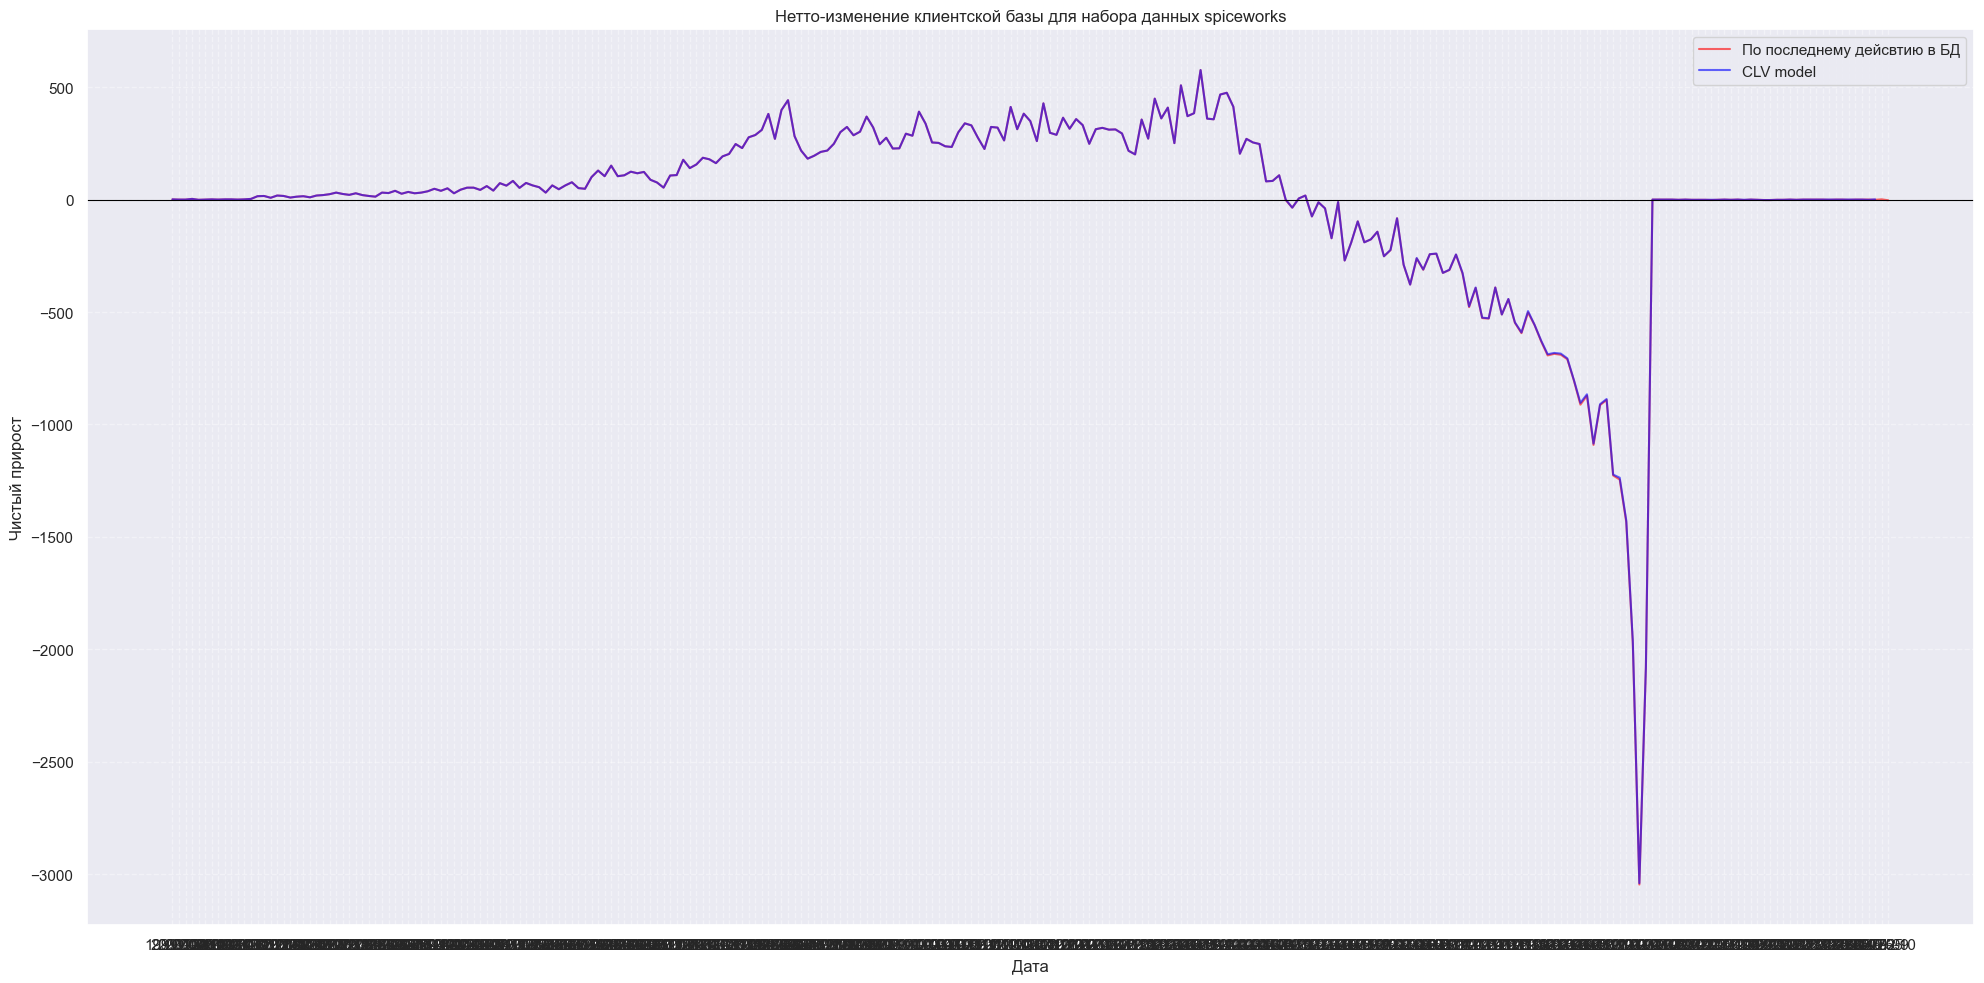

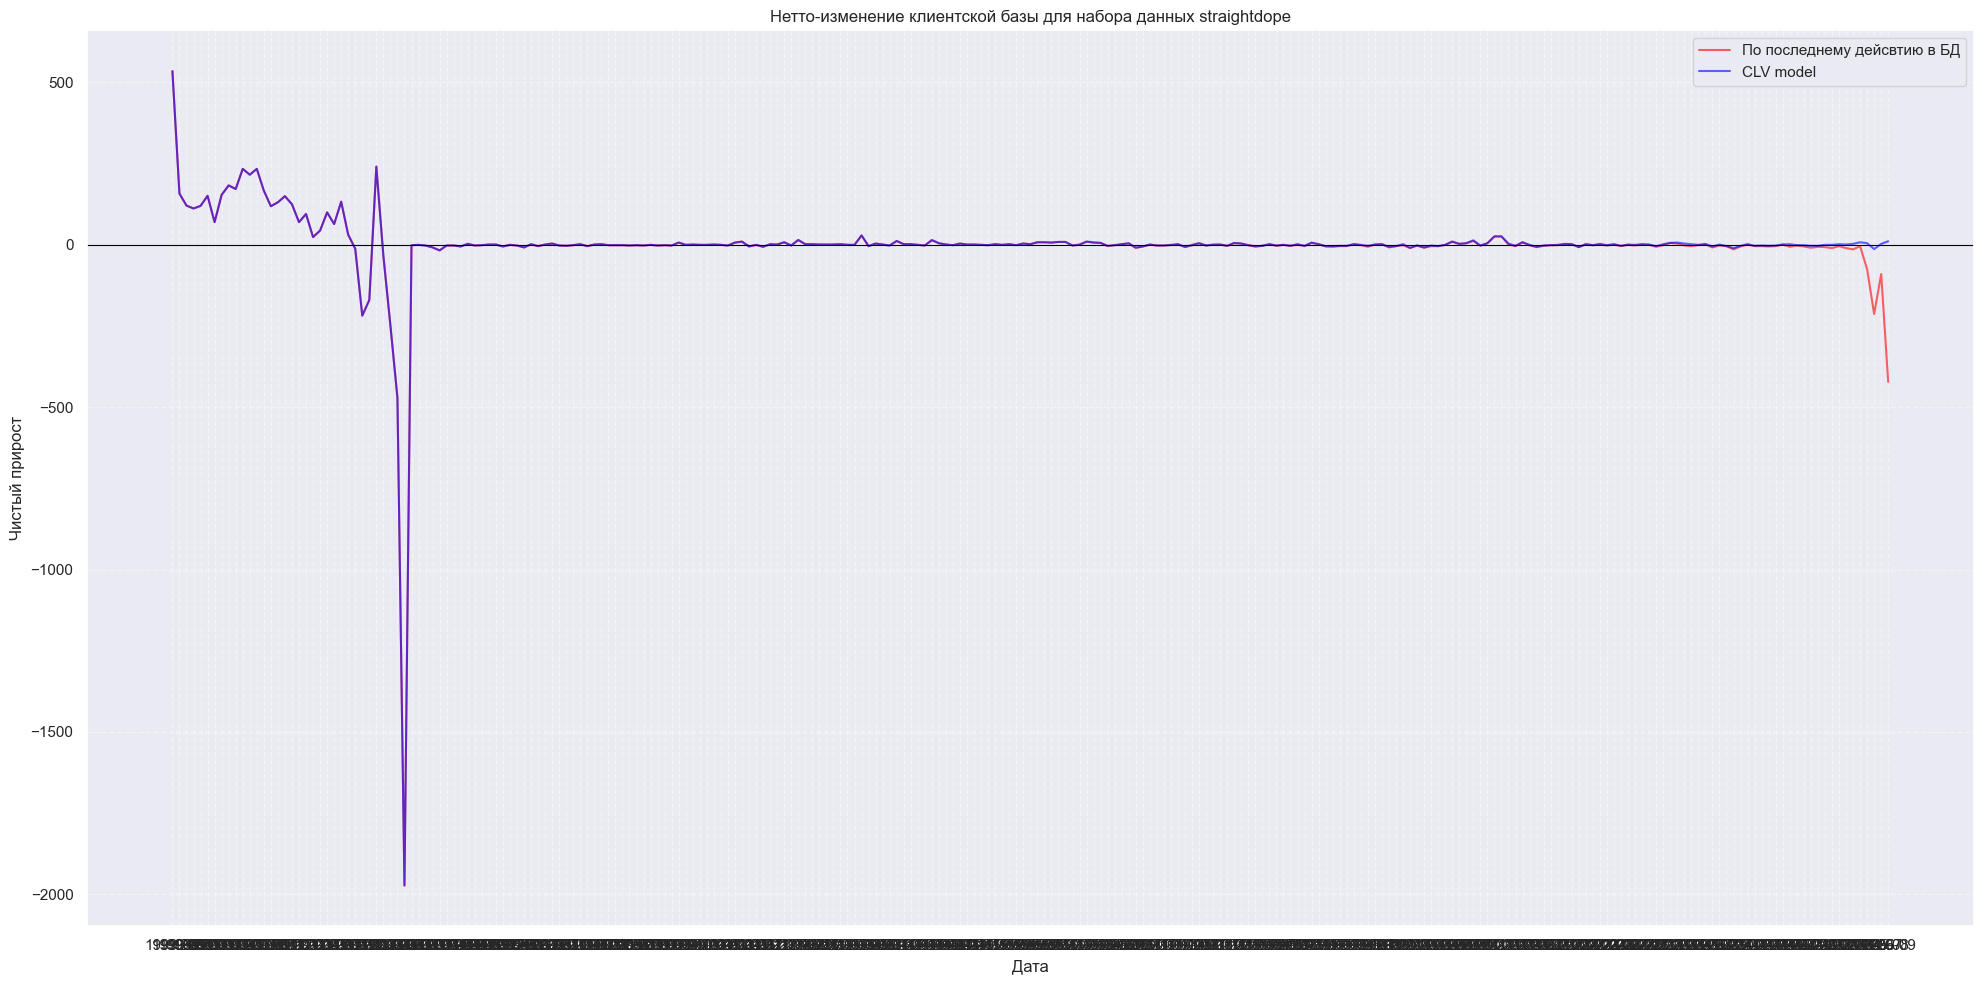

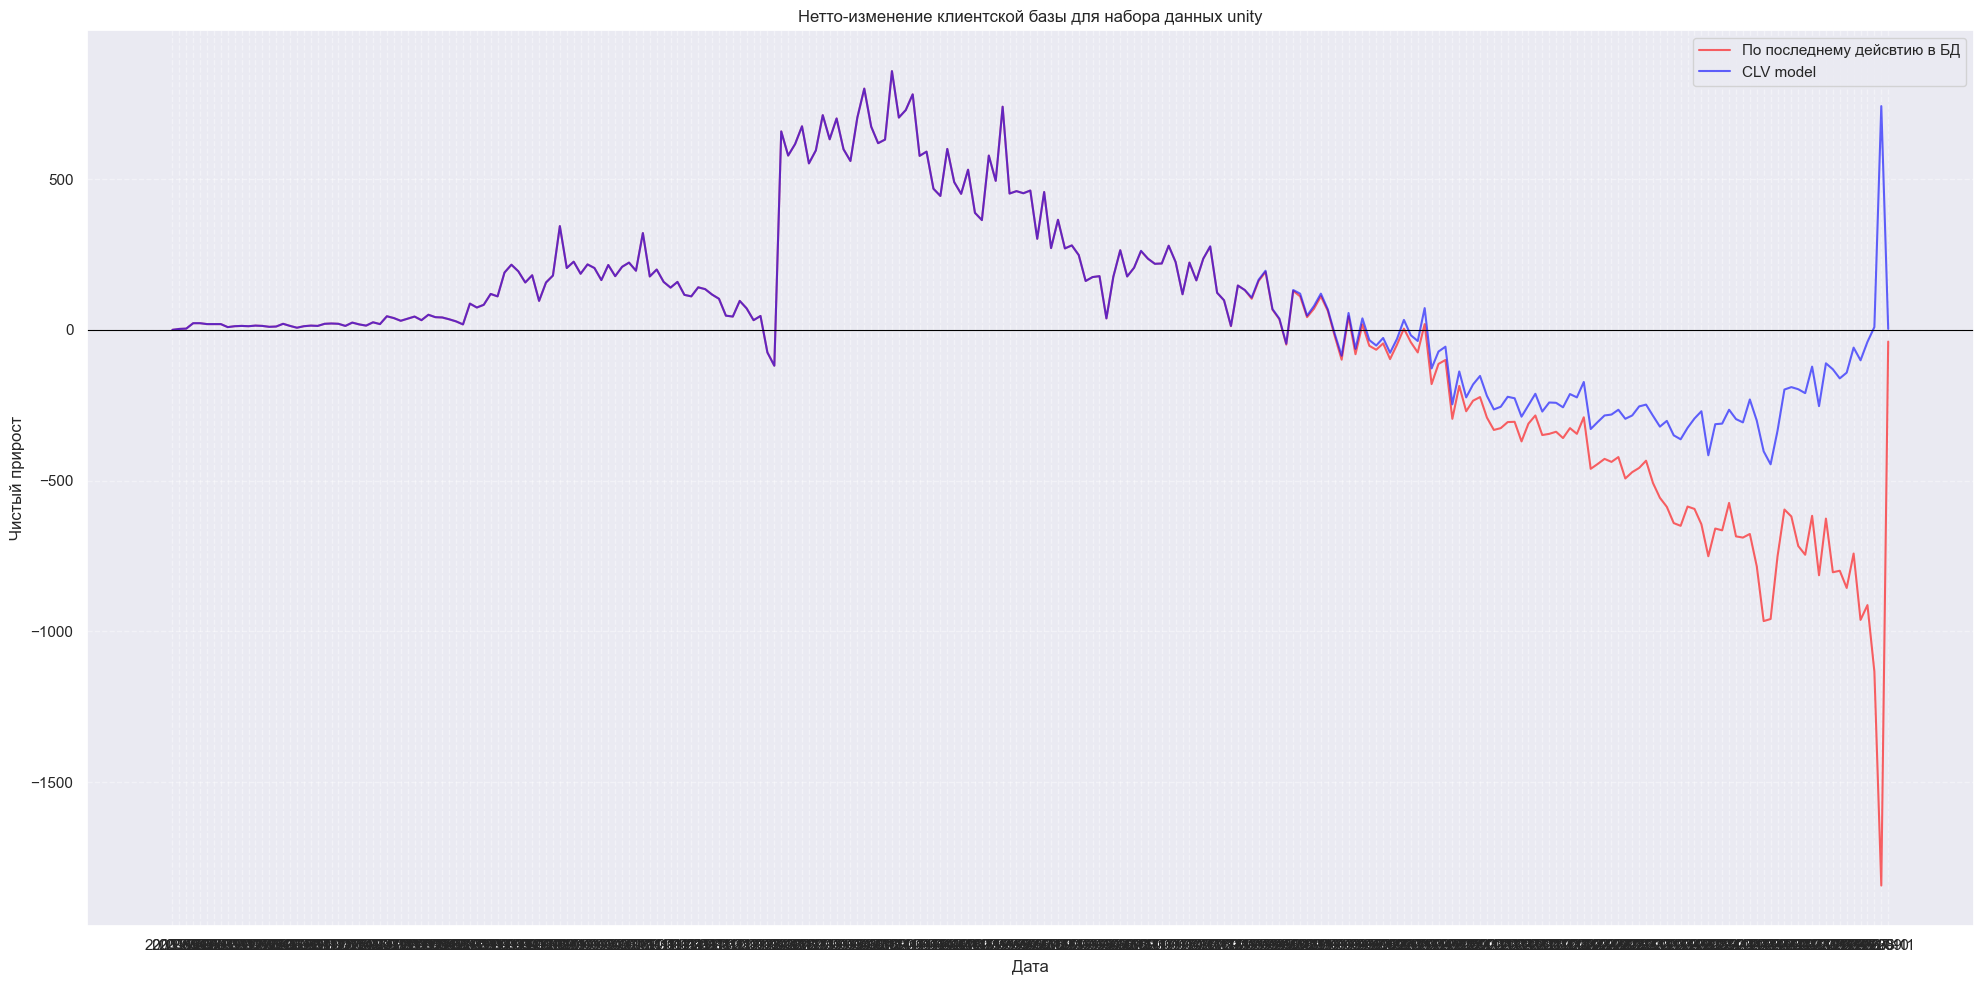

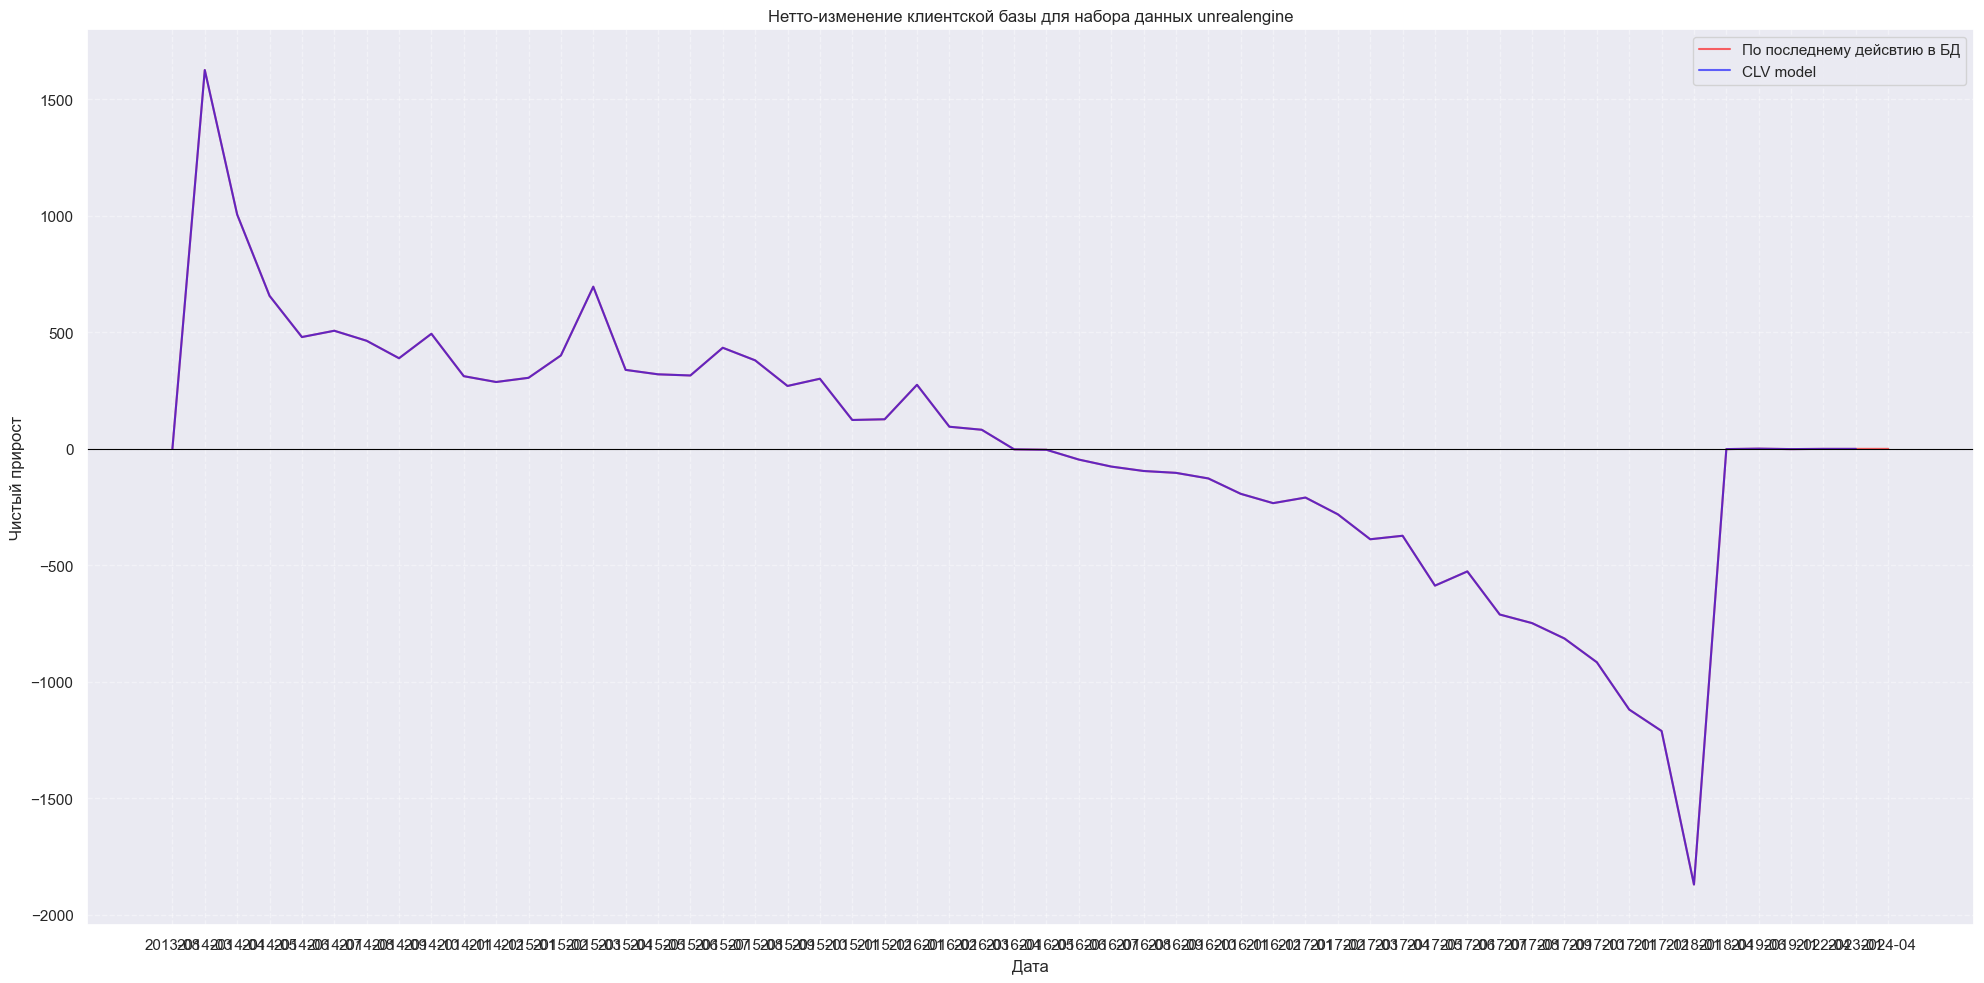

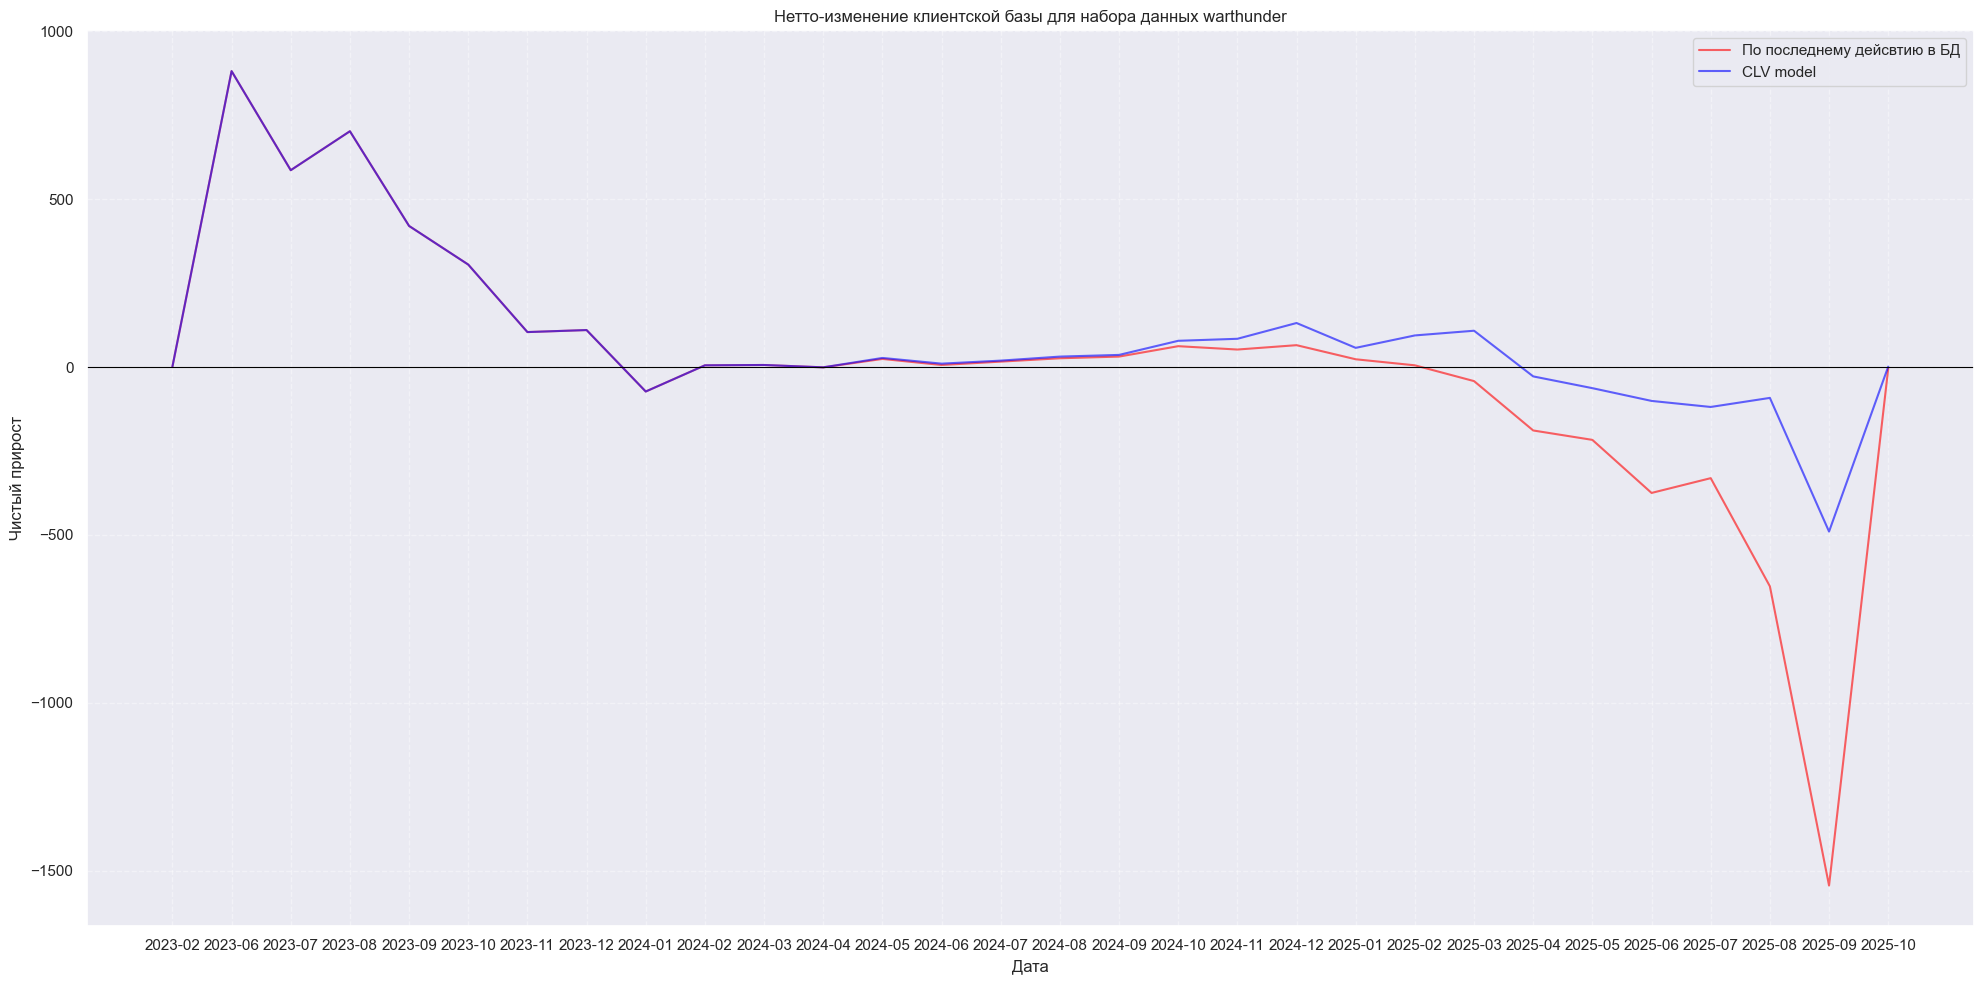

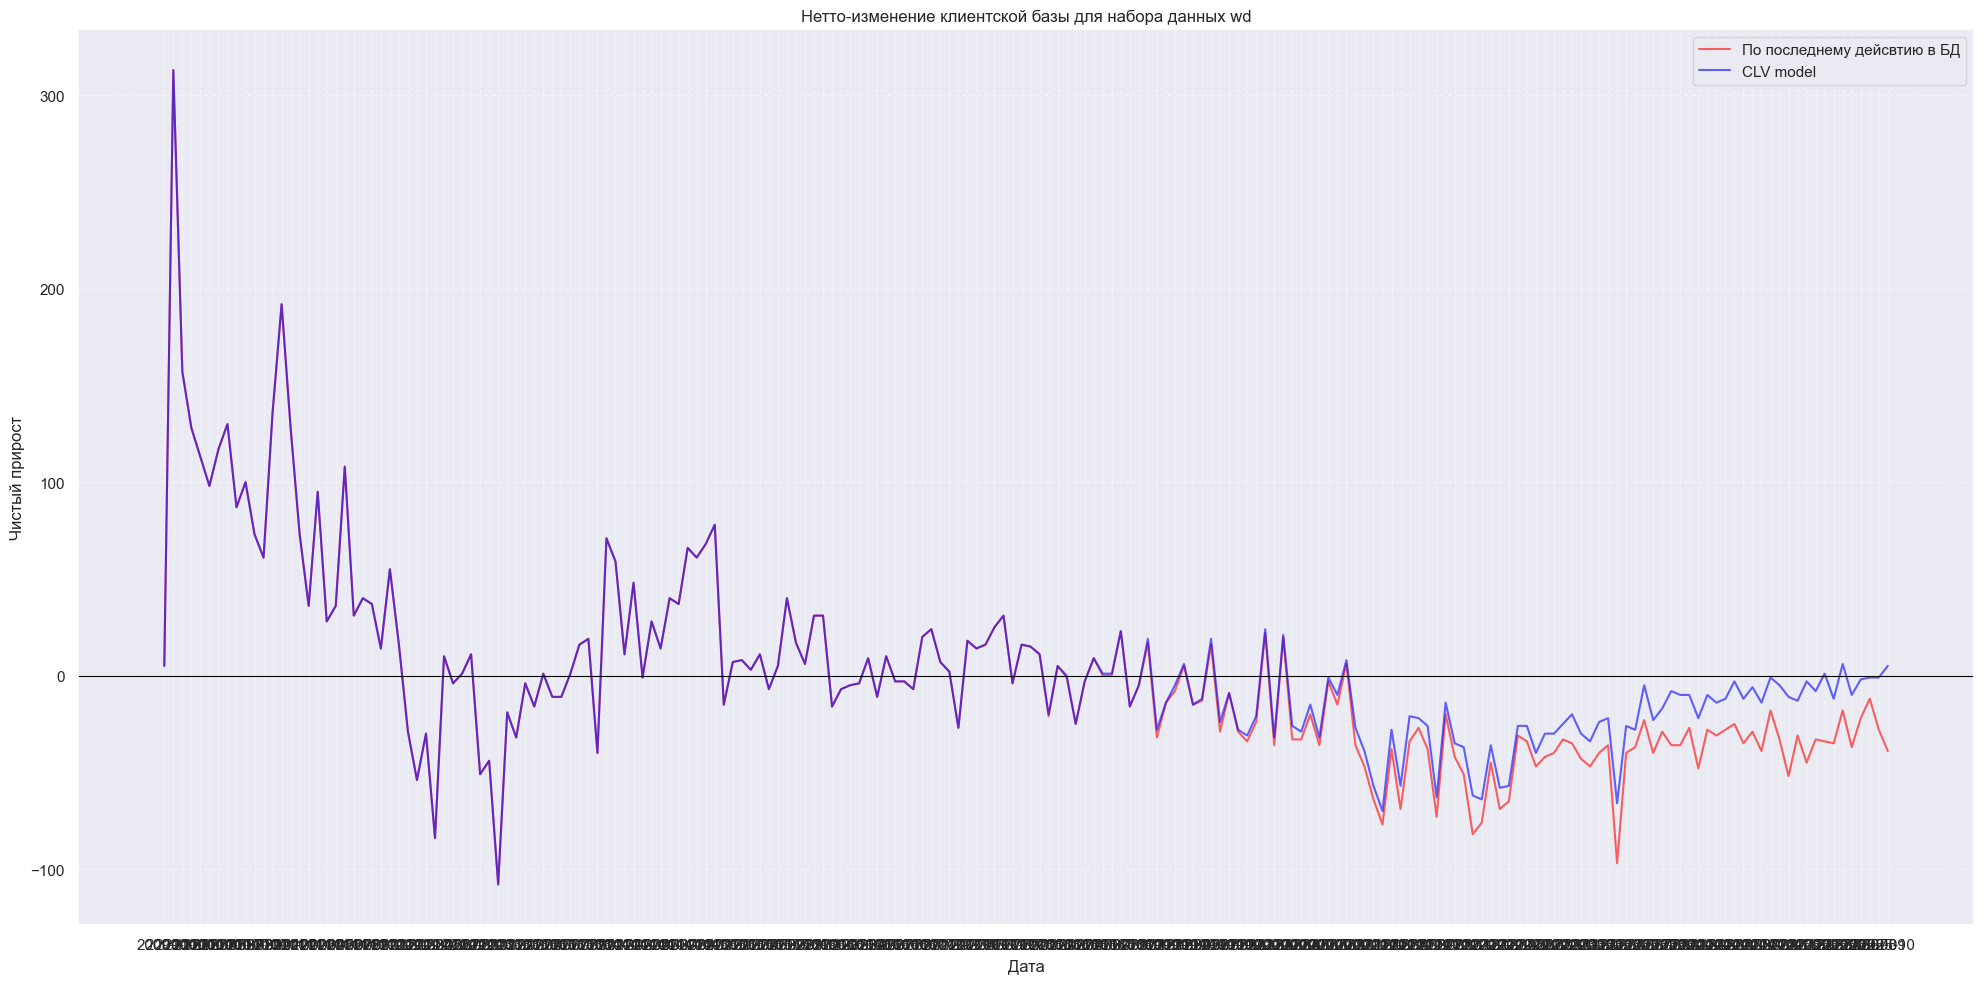

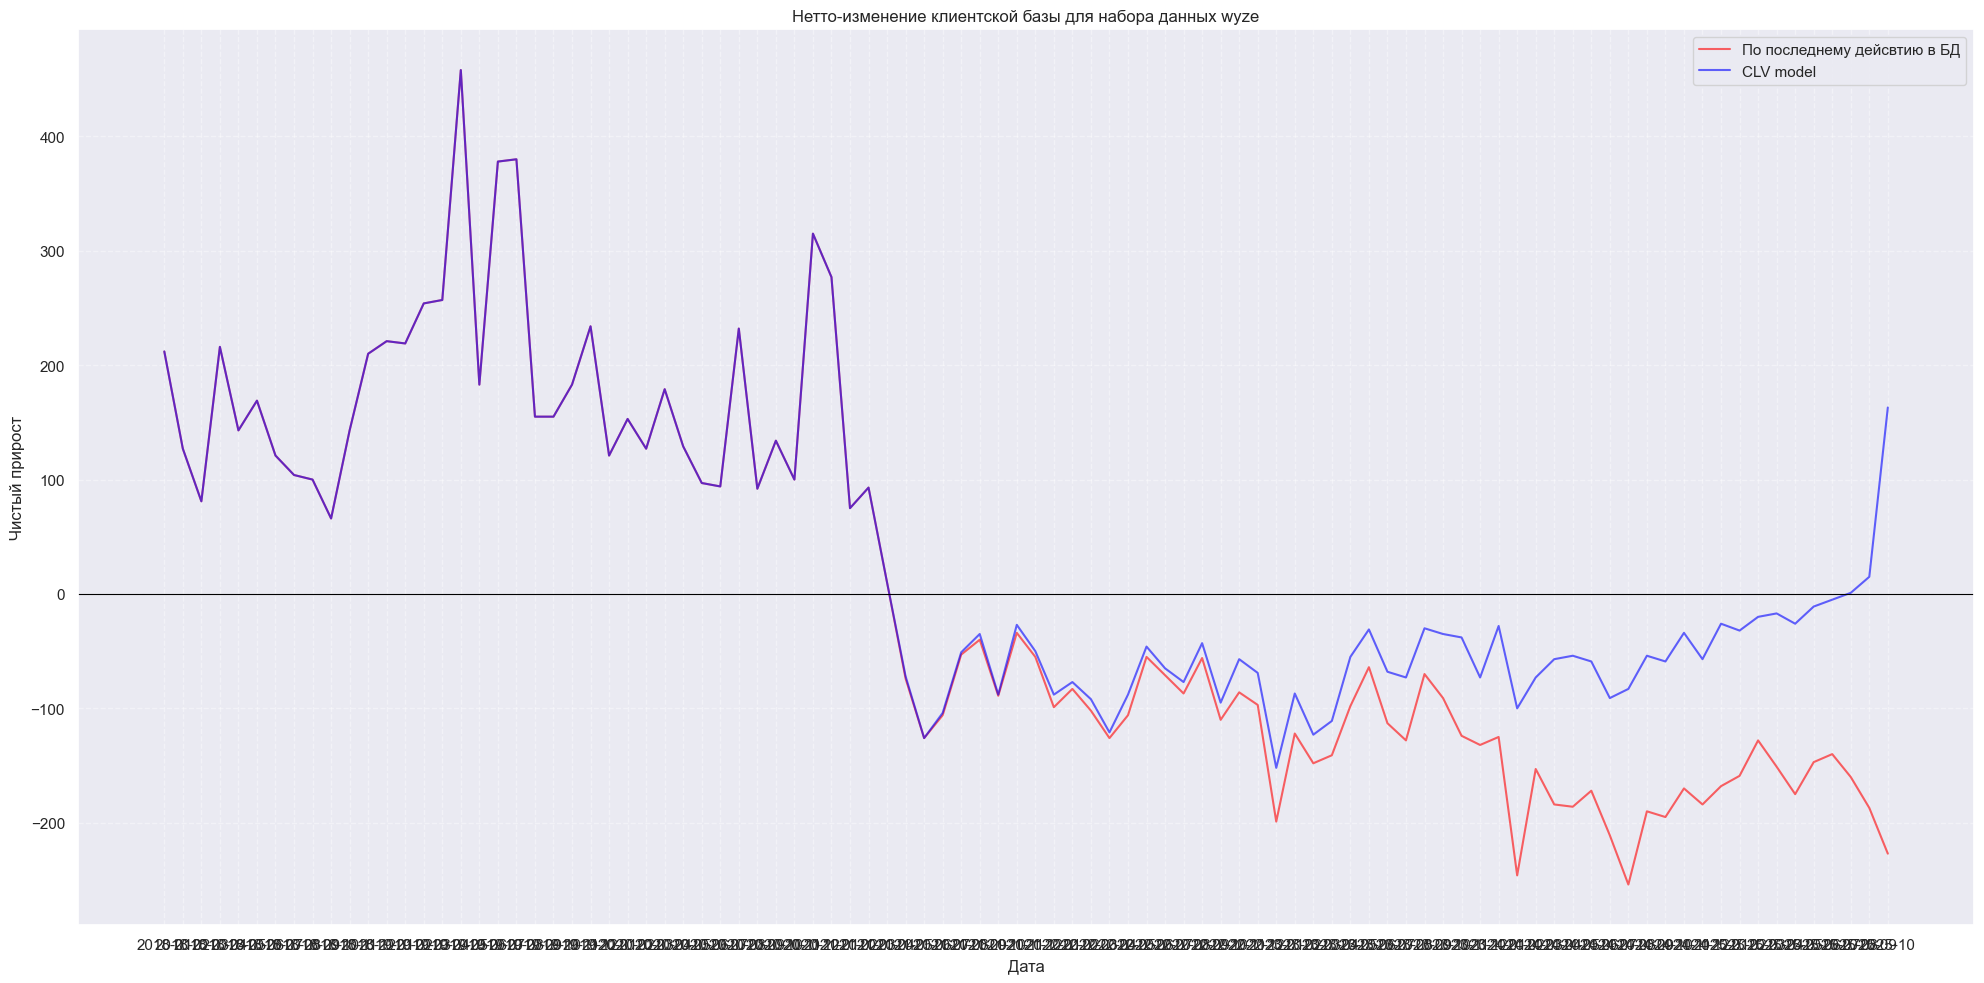

In [37]:
for name, data in full_datas.items():
    data_lifetime_last = pd.read_csv(fr'..\models\{name}_metrics_by_last_action.csv').copy()
    data_lifetime_clv = pd.read_csv(fr'..\models\{name}_metrics_by_CLV_on_0_day.csv').copy()

    plot_df = pd.DataFrame({
    "month": data_lifetime_last["month"],
    "last": data_lifetime_last["Profit_by_last_message"],
    "clv": data_lifetime_clv["Profit_by_CLV"]
    })

    fig, ax = plt.subplots(figsize=(20, 10), sharex = True)

    ax.plot(
        plot_df["month"], 
        plot_df["last"],
        label = 'По последнему дейсвтию в БД',
        color = 'red',
        alpha=0.6
    )

    ax.plot(
        plot_df["month"], 
        plot_df["clv"],
        label = 'CLV model',
        color = 'blue',
        alpha=0.6
    )

    ax.axhline(y=0, color='black', linewidth=0.8)

    ax.set_ylabel('Чистый прирост')
    ax.set_title(f'Нетто-изменение клиентской базы для набора данных {name}')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()

    ax.set_xlabel('Дата')

    plt.tight_layout()
    #plt.savefig(f'../image/Рисунок_5_Сравнение_двух_методов_для_{name}.png')
    plt.show()
    